In [15]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

Current working directory:
/Users/arham/Desktop/CODING/github/Curamind-Ml-Intregation/notebooks

Files/folders here:
['01_brfss_inspection.ipynb', '.DS_Store', 'curamind_v1']


# M0 — Understanding the datasets

In [17]:
import os

print(os.listdir("../data/raw/BRFSS_2024"))

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/BRFSS_2024'

In [ ]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

Current working directory:
/Users/arham/Desktop/CODING/github/Ml Model/CuraMind-ML/notebooks

Files/folders here:
['01_brfss_inspection.ipynb', '.DS_Store']


In [ ]:
import os

file_path = "../data/raw/BRFSS_2024/LLCP2024.XPT "

print("Full path:")
print(os.path.abspath(file_path))

print("\nFile exists:")
print(os.path.exists(file_path))

Full path:
/Users/arham/Desktop/CODING/github/Ml Model/CuraMind-ML/data/raw/BRFSS_2024/LLCP2024.XPT 

File exists:
True


In [ ]:

import sys
import pandas
import numpy
import sklearn
import shap
import joblib

print("Python:", sys.executable)
print("Pandas:", pandas.__version__)
print("NumPy:", numpy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("SHAP:", shap.__version__)
print("Joblib:", joblib.__version__)

print("\n✅ CuraMind-ML environment is working correctly!")

/Users/arham/Desktop/CODING/github/Ml Model/CuraMind-ML/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: /Users/arham/Desktop/CODING/github/Ml Model/CuraMind-ML/.venv/bin/python
Pandas: 3.0.5
NumPy: 2.5.2
Scikit-learn: 1.9.0
SHAP: 0.52.0
Joblib: 1.5.3

✅ CuraMind-ML environment is working correctly!


In [ ]:
import pandas as pd

file_path = "../data/raw/BRFSS_2024/LLCP2024.XPT "

df = pd.read_sas(file_path, format="xport")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (457670, 301)


In [ ]:
print(df.columns.tolist())

['_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'NUMADULT', 'RESPSLC1', 'LANDSEX3', 'SAFETIME', 'CTELNUM1', 'CELLFON5', 'CADULT1', 'CELLSEX3', 'PVTRESD3', 'CCLGHOUS', 'CSTATE1', 'LANDLINE', 'HHADULT', 'SEXVAR', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'PRIMINS2', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1', 'EXERANY2', 'LASTDEN4', 'RMVTETH4', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNC1', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'HAVARTH4', 'DIABETE4', 'DIABAGE4', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL4', 'NUMPHON4', 'CPDEMO1C', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME3', 'PREGNANT', 'WEIGHT2', 'HEIGHT3', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'HADSIGM4', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'COLNCNCR', 'VIRCOLO1', 'VCLNTES2', 'SMALST

In [ ]:
[c for c in df.columns if any(x in c.upper() for x in ["CNCR", "SMOK", "LCS", "FAM", "CANCER"])]

['COLNCNCR',
 'SMOKE100',
 'SMOKDAY2',
 'LCSFIRST',
 'LCSNUMCG',
 'LCSCTSC1',
 'LCSSCNCR',
 'LCSCTWHN',
 'CNCRDIFF',
 'CNCRAGE',
 'CNCRTYP2',
 'MARJSMOK',
 '_SMOKER3',
 '_RFSMOK3',
 'LCSLAST_',
 'LCSNUMC_',
 '_LCSAGE',
 '_LCSYSMK',
 '_LCSYQTS',
 '_LCSSMKG',
 '_LCSELIG',
 '_LCSCTSN',
 '_LCSPSTF']

In [ ]:
df["CNCRDIFF"].value_counts(dropna=False)

CNCRDIFF
NaN    442798
1.0     10961
2.0      2805
3.0       696
7.0       274
9.0       136
Name: count, dtype: int64

In [ ]:
print(df["CNCRDIFF"].dtype)

float64


In [ ]:
for col in ["CNCRAGE", "CNCRTYPE1"]:
    if "df" in globals() and col in df.columns:
        print(f"\n{'='*40}")
        print(col)
        print(df[col].value_counts(dropna=False))


CNCRAGE
CNCRAGE
NaN     443222
60.0       851
50.0       777
98.0       687
65.0       646
         ...  
6.0          2
93.0         2
91.0         2
94.0         1
95.0         1
Name: count, Length: 98, dtype: int64


In [ ]:
df["CHCOCNC1"].value_counts(normalize=True, dropna=False)

CHCOCNC1
2.0    0.874584
1.0    0.120071
7.0    0.004584
9.0    0.000749
NaN    0.000011
Name: proportion, dtype: float64

# M2 — Define the ML Problem

## Target Variable
**CHCOCNC1** — Reported history of being told of cancer other than skin cancer.

## Binary Target
- **1 = Yes** — Reported history of cancer
- **0 = No** — No reported history of cancer

Responses coded as **Don't know**, **Refused**, or missing will not be used as Yes or No.

## ML Task
This is a **binary classification problem**.

The model will learn patterns associated with reported cancer history using BRFSS 2024 survey data.

## Important Limitation
This baseline model does **not** predict a person's future chance of developing cancer.

It predicts the reported cancer-history target within the BRFSS 2024 dataset and should be interpreted as a research baseline, not a medical diagnosis or clinical prediction tool.

import sys
print(sys.executable)

In [ ]:
target_df = df[df["CHCOCNC1"].isin([1, 2])].copy()

target_df["target"] = target_df["CHCOCNC1"].map({
    1.0: 1,
    2.0: 0
})

y = target_df["target"]

y.value_counts(normalize=True)

target
0    0.879284
1    0.120716
Name: proportion, dtype: float64

In [ ]:
print(y.value_counts())
print(y.dtype)

target
0    400271
1     54953
Name: count, dtype: int64
int64


In [ ]:
print("Rows in target_df:", len(target_df))
print("Rows in y:", len(y))

Rows in target_df: 455224
Rows in y: 455224


# M3 — Starts from here

In [ ]:
print("Total columns:", len(target_df.columns))

for col in target_df.columns:
    print(col)

Total columns: 302
_STATE
FMONTH
IDATE
IMONTH
IDAY
IYEAR
DISPCODE
SEQNO
_PSU
CTELENM1
PVTRESD1
COLGHOUS
STATERE1
CELPHON1
LADULT1
NUMADULT
RESPSLC1
LANDSEX3
SAFETIME
CTELNUM1
CELLFON5
CADULT1
CELLSEX3
PVTRESD3
CCLGHOUS
CSTATE1
LANDLINE
HHADULT
SEXVAR
GENHLTH
PHYSHLTH
MENTHLTH
POORHLTH
PRIMINS2
PERSDOC3
MEDCOST1
CHECKUP1
EXERANY2
LASTDEN4
RMVTETH4
CVDINFR4
CVDCRHD4
CVDSTRK3
ASTHMA3
ASTHNOW
CHCSCNC1
CHCOCNC1
CHCCOPD3
ADDEPEV3
CHCKDNY2
HAVARTH4
DIABETE4
DIABAGE4
MARITAL
EDUCA
RENTHOM1
NUMHHOL4
NUMPHON4
CPDEMO1C
VETERAN3
EMPLOY1
CHILDREN
INCOME3
PREGNANT
WEIGHT2
HEIGHT3
DEAF
BLIND
DECIDE
DIFFWALK
DIFFDRES
DIFFALON
HADMAM
HOWLONG
CERVSCRN
CRVCLCNC
CRVCLPAP
CRVCLHPV
HADHYST2
HADSIGM4
COLNSIGM
COLNTES1
SIGMTES1
LASTSIG4
COLNCNCR
VIRCOLO1
VCLNTES2
SMALSTOL
STOLTEST
STOOLDN2
BLDSTFIT
SDNATES1
SMOKE100
SMOKDAY2
USENOW3
ECIGNOW3
LCSFIRST
LCSNUMCG
LCSCTSC1
LCSSCNCR
LCSCTWHN
ALCDAY4
AVEDRNK4
DRNK3GE5
MAXDRNKS
FLUSHOT7
FLSHTMY3
IMFVPLA5
PNEUVAC4
HIVTST7
HIVTSTD3
HIVRISK5
PDIABTS1
PREDIAB2
DIABTYPE
I

# M3 — Feature Selection

## Feature Selection Principles

Features should:

- Be realistic to collect through the CuraMind questionnaire
- Be available before or independently of the reported cancer-history outcome
- Avoid directly revealing the target
- Avoid cancer-survivorship and post-diagnosis information
- Represent meaningful demographic, lifestyle, or general health information

Candidate feature groups:

1. Demographics
2. Lifestyle and behavioral factors
3. Body measurements
4. General health indicators
5. Relevant medical history

In [ ]:
age_cols = [col for col in target_df.columns if "AGE" in col.upper()]

print(age_cols)

['DIABAGE4', 'CNCRAGE', 'CAGEG', '_AGEG5YR', '_AGE65YR', '_AGE80', '_AGE_G', '_LCSAGE']


In [ ]:
for col in ["CAGEG", "_AGEG5YR", "_AGE65YR", "_AGE80", "_AGE_G"]:
    print(f"\n{'='*30}")
    print(col)
    print(target_df[col].value_counts(dropna=False).sort_index())


CAGEG
CAGEG
1.0     11040
2.0     11428
3.0     13933
4.0     11678
NaN    407145
Name: count, dtype: int64

_AGEG5YR
_AGEG5YR
1.0     29631
2.0     23651
3.0     26180
4.0     28727
5.0     30803
6.0     28881
7.0     31572
8.0     34777
9.0     43168
10.0    47426
11.0    44477
12.0    36523
13.0    41299
14.0     8109
Name: count, dtype: int64

_AGE65YR
_AGE65YR
1.0    277390
2.0    169725
3.0      8109
Name: count, dtype: int64

_AGE80
_AGE80
18.0     3765
19.0     4001
20.0     4154
21.0     4280
22.0     4188
        ...  
76.0     8050
77.0     8241
78.0     6345
79.0     5396
80.0    41312
Name: count, Length: 63, dtype: int64

_AGE_G
_AGE_G
1.0     29633
2.0     49883
3.0     60239
4.0     64144
5.0     79851
6.0    171474
Name: count, dtype: int64


## Selected Feature: Age

**Feature:** `_AGE80`

Reason:
- Represents age with greater detail than grouped age variables
- Available for the dataset population
- No missing values in the current target dataset
- Suitable for use as a numeric model input

Note: Age 80 represents respondents aged 80 or older.

In [ ]:
target_df["SEXVAR"].value_counts(dropna=False).sort_index()

SEXVAR
1.0    216182
2.0    239042
Name: count, dtype: int64

## Selected Feature: Sex

**Feature:** `SEXVAR`

Reason:
- Basic demographic information
- No missing values in the current target dataset
- Realistic to collect through the CuraMind questionnaire
- May be relevant because cancer history patterns can differ across demographic groups

Note: This is a categorical feature and will be handled appropriately during preprocessing.

In [ ]:
body_cols = [
    col for col in target_df.columns
    if any(
        x in col.upper()
        for x in ["BMI", "HEIGHT", "WEIGHT", "HTM", "WTKG"]
    )
]

print(body_cols)

['WEIGHT2', 'HEIGHT3', 'FLSHTMY3', 'HTM4', 'WTKG3', '_BMI5', '_BMI5CAT', '_RFBMI5']


In [ ]:
print(target_df["_BMI5"].value_counts(dropna=False).sort_index().head(20))
print(target_df["_BMI5"].describe())

_BMI5
1200.0    1
1205.0    2
1208.0    1
1211.0    5
1213.0    1
1216.0    1
1217.0    1
1219.0    1
1220.0    2
1221.0    3
1222.0    1
1226.0    1
1227.0    2
1230.0    1
1231.0    1
1236.0    1
1240.0    5
1241.0    1
1244.0    2
1248.0    5
Name: count, dtype: int64
count    412593.000000
mean       2855.832617
std         658.487728
min        1200.000000
25%        2414.000000
50%        2744.000000
75%        3175.000000
max        9984.000000
Name: _BMI5, dtype: float64


In [ ]:
print(target_df["_BMI5"].value_counts(dropna=False).sort_index().tail(20))
print(target_df[target_df["_BMI5"] >= 9000]["_BMI5"].value_counts(dropna=False))

_BMI5
9182.0        4
9222.0        2
9283.0        1
9319.0        1
9383.0        1
9388.0        1
9419.0        1
9441.0        1
9461.0        1
9493.0        1
9494.0        2
9529.0        1
9602.0        1
9652.0        1
9656.0        1
9765.0        1
9844.0        1
9979.0        1
9984.0        1
NaN       42631
Name: count, dtype: int64
_BMI5
9182.0    4
9222.0    2
9494.0    2
9283.0    1
9090.0    1
9050.0    1
9319.0    1
9461.0    1
9652.0    1
9602.0    1
9388.0    1
9383.0    1
9084.0    1
9529.0    1
9419.0    1
9441.0    1
9020.0    1
9844.0    1
9172.0    1
9145.0    1
9656.0    1
9984.0    1
9039.0    1
9979.0    1
9765.0    1
9007.0    1
9493.0    1
Name: count, dtype: int64


In [ ]:
bmi_missing = target_df["_BMI5"].isna().sum()
bmi_missing_pct = target_df["_BMI5"].isna().mean() * 100

print(f"Missing values: {bmi_missing:,}")
print(f"Missing percentage: {bmi_missing_pct:.2f}%")

Missing values: 42,631
Missing percentage: 9.36%


## M3.4 — Smoking Feature Selection

Smoking is an important lifestyle and behavioral factor for the CuraMind baseline. However, BRFSS may contain multiple variables related to smoking, cigarette use, and tobacco products.

We will:

- Identify all smoking-related candidate columns
- Understand what each variable represents
- Check for overlap or redundancy
- Evaluate compatibility with CuraMind user inputs
- Select only the most useful non-redundant features

**Goal:** Identify the smoking-related features that provide useful information for the baseline without introducing unnecessary duplication or target leakage.

In [ ]:
smoking_cols = [
    col for col in target_df.columns
    if any(
        x in col.upper()
        for x in ["SMOK", "CIG", "TOBAC", "VAPE", "ECIG"]
    )
]

print(smoking_cols)

['SMOKE100', 'SMOKDAY2', 'ECIGNOW3', 'MARJSMOK', 'MARJVAPE', 'MENTCIGS', 'MENTECIG', '_SMOKER3', '_RFSMOK3']


In [ ]:
for col in ["SMOKE100", "SMOKDAY2", "_SMOKER3"]:
    print(f"\n{'=' * 50}")
    print(f"{col}")
    print(target_df[col].value_counts(dropna=False).sort_index())


SMOKE100
SMOKE100
1.0    166177
2.0    257899
7.0      2029
9.0       471
NaN     28648
Name: count, dtype: int64

SMOKDAY2
SMOKDAY2
1.0     32841
2.0     13887
3.0    118911
7.0       186
9.0       188
NaN    289211
Name: count, dtype: int64

_SMOKER3
_SMOKER3
1.0     32841
2.0     13887
3.0    118911
4.0    257899
9.0     31686
Name: count, dtype: int64


## M3.5 — Alcohol Consumption Feature Selection

Alcohol consumption is an important lifestyle factor to evaluate for the CuraMind baseline. BRFSS may contain multiple variables related to alcohol use, including drinking frequency, drinking quantity, and derived alcohol-risk categories.

We will:

- Identify alcohol-related candidate columns
- Understand what each variable represents
- Check for overlap or redundancy
- Evaluate compatibility with CuraMind user inputs
- Select useful non-redundant alcohol-related features

**Goal:** Identify alcohol-related features that provide meaningful lifestyle information for the baseline without introducing unnecessary duplication or target leakage.

In [ ]:
alcohol_cols = [
    col for col in target_df.columns
    if any(
        x in col.upper()
        for x in ["ALC", "DRINK", "ALCO", "BINGE", "HEAVY"]
    )
]

print(alcohol_cols)

['ALCDAY4', 'ACEDRINK', '_DUALCOR']


In [ ]:
for col in ["ALCDAY4", "ACEDRINK", "_DUALCOR"]:
    print(f"\n{'=' * 50}")
    print(col)
    print(target_df[col].value_counts(dropna=False).sort_index())


ALCDAY4
ALCDAY4
100.0         1
101.0     19875
102.0     15847
103.0     11383
104.0      5571
105.0      5458
106.0      1751
107.0      5885
201.0     34265
202.0     25281
203.0     14461
204.0     10943
205.0     10468
206.0      3671
207.0      2724
208.0      3113
209.0       275
210.0      6926
211.0        38
212.0      1626
213.0        99
214.0       588
215.0      5435
216.0       212
217.0        81
218.0       208
219.0        10
220.0      5813
221.0       188
222.0       161
223.0        67
224.0       191
225.0      2696
226.0       167
227.0       209
228.0       824
229.0       292
230.0     12959
777.0      2835
888.0    202093
999.0      1590
NaN       38944
Name: count, dtype: int64

ACEDRINK
ACEDRINK
1.0      8881
2.0     29761
7.0       111
9.0       218
NaN    416253
Name: count, dtype: int64

_DUALCOR
_DUALCOR
0.016568       487
0.058192        54
0.117106       870
0.143661       796
0.167052       932
             ...  
0.856339      1718
0.882894      1820

In [ ]:
# Search for additional alcohol-related variables
possible_alcohol_cols = [
    col for col in target_df.columns
    if any(
        x in col.upper()
        for x in [
            "DRNK", "DRINK", "ALC", "ALCO",
            "BINGE", "HEAVY", "MAXDRNKS"
        ]
    )
]

print(possible_alcohol_cols)

['ALCDAY4', 'AVEDRNK4', 'DRNK3GE5', 'MAXDRNKS', 'ACEDRINK', '_DUALCOR', 'DRNKANY6', '_DRNKWK3']


In [ ]:
alcohol_candidates = [
    "ALCDAY4",
    "AVEDRNK4",
    "DRNK3GE5",
    "MAXDRNKS",
    "DRNKANY6",
    "_DRNKWK3"
]

for col in alcohol_candidates:
    print(f"\n{'=' * 50}")
    print(col)
    print(target_df[col].value_counts(dropna=False).sort_index())


ALCDAY4
ALCDAY4
100.0         1
101.0     19875
102.0     15847
103.0     11383
104.0      5571
105.0      5458
106.0      1751
107.0      5885
201.0     34265
202.0     25281
203.0     14461
204.0     10943
205.0     10468
206.0      3671
207.0      2724
208.0      3113
209.0       275
210.0      6926
211.0        38
212.0      1626
213.0        99
214.0       588
215.0      5435
216.0       212
217.0        81
218.0       208
219.0        10
220.0      5813
221.0       188
222.0       161
223.0        67
224.0       191
225.0      2696
226.0       167
227.0       209
228.0       824
229.0       292
230.0     12959
777.0      2835
888.0    202093
999.0      1590
NaN       38944
Name: count, dtype: int64

AVEDRNK4
AVEDRNK4
1.0      89516
2.0      64000
3.0      24973
4.0      10974
5.0       5996
6.0       4913
7.0        898
8.0       1424
9.0        202
10.0      1442
11.0        45
12.0       942
13.0        47
14.0        42
15.0       307
16.0        54
17.0        10
18.0       

In [ ]:
selected_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "_DRNKWK3"
]

## M3.6 — Physical Activity Feature Selection

Physical activity is an important lifestyle factor for the CuraMind baseline. BRFSS contains multiple variables related to physical activity, including overall activity, activity frequency, exercise type, and calculated physical activity measures.

We will:

- Identify physical-activity-related candidate columns
- Understand what each variable represents
- Check for overlap or redundancy
- Evaluate compatibility with CuraMind user inputs
- Select useful non-redundant features

**Goal:** Identify physical activity features that provide meaningful lifestyle information for the baseline while avoiding unnecessary duplication and target leakage.

In [ ]:
physical_activity_cols = [
    col for col in target_df.columns
    if any(
        x in col.upper()
        for x in [
            "PHYS", "EXER", "EXRC", "ACTIV",
            "PA1", "PAVIG", "STRENGTH"
        ]
    )
]

print(physical_activity_cols)

['PHYSHLTH', 'EXERANY2', 'ARTHEXER', '_PHYS14D']


In [ ]:
physical_activity_candidates = [
    "PHYSHLTH",
    "EXERANY2",
    "ARTHEXER",
    "_PHYS14D"
]

for col in physical_activity_candidates:
    print(f"\n{'=' * 50}")
    print(col)
    print(target_df[col].value_counts(dropna=False).sort_index())


PHYSHLTH
PHYSHLTH
1.0      18444
2.0      27795
3.0      16847
4.0       8967
5.0      16072
6.0       2474
7.0       9332
8.0       1840
9.0        414
10.0     11071
11.0       133
12.0      1113
13.0       152
14.0      4642
15.0      9739
16.0       297
17.0       197
18.0       341
19.0        56
20.0      6447
21.0       977
22.0       208
23.0       117
24.0       114
25.0      2463
26.0       136
27.0       240
28.0       885
29.0       401
30.0     35943
77.0      8613
88.0    266536
99.0      2215
NaN          3
Name: count, dtype: int64

EXERANY2
EXERANY2
1.0    348423
2.0    105571
7.0       841
9.0       388
NaN         1
Name: count, dtype: int64

ARTHEXER
ARTHEXER
1.0     22628
2.0     10873
7.0       472
9.0        27
NaN    421224
Name: count, dtype: int64

_PHYS14D
_PHYS14D
1.0    266536
2.0    114654
3.0     63203
9.0     10831
Name: count, dtype: int64


In [ ]:
selected_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "_DRNKWK3",
    "EXERANY2"
]

## 3.3 Map CuraMind Physical Activity Input to BRFSS

The CuraMind frontend currently provides four physical activity levels:

- Sedentary
- Light
- Moderate
- Active

We inspected several BRFSS variables:

- `EXERANY2` → leisure-time physical activity question
- `ARTHEXER` → arthritis-specific exercise variable
- `_PHYS14D` → number of days when physical health was not good

`_PHYS14D` is not a physical activity variable and will not be used for this CuraMind feature.

The preferred BRFSS candidate is `_TOTINDA`, the CDC-derived variable for leisure-time physical activity, based on `EXERANY2`.

For the minimal working CuraMind model, the frontend's four activity levels may need to be temporarily mapped into the available BRFSS activity representation rather than forcing an artificial four-level mapping.

This keeps the model transparent:

- Sedentary → no leisure-time physical activity
- Light / Moderate / Active → leisure-time physical activity

A richer physical activity representation can be added in a future model version when an appropriate dataset provides activity frequency and intensity.

In [ ]:
# --------------------------------------------------
# Inspect Physical Activity Variables
# --------------------------------------------------

physical_activity_candidates = [
    "EXERANY2",
    "ARTHEXER",
    "_PHYS14D"
]

print("Physical Activity Variable Inspection")
print("=" * 60)

for column in physical_activity_candidates:
    
    if column in df.columns:
        print(f"\n{column}")
        print("-" * 60)
        
        print(df[column].value_counts(dropna=False).sort_index())
        
        print(f"\nMissing values: {df[column].isna().sum():,}")
        print(f"Unique values: {df[column].nunique(dropna=False)}")
        
    else:
        print(f"\n{column} not found in dataset.")

Physical Activity Variable Inspection

EXERANY2
------------------------------------------------------------
EXERANY2
1.0    350061
2.0    106294
7.0       860
9.0       452
NaN         3
Name: count, dtype: int64

Missing values: 3
Unique values: 5

ARTHEXER
------------------------------------------------------------
ARTHEXER
1.0     22797
2.0     10948
7.0       479
9.0        28
NaN    423418
Name: count, dtype: int64

Missing values: 423,418
Unique values: 5

_PHYS14D
------------------------------------------------------------
_PHYS14D
1.0    267576
2.0    115200
3.0     63827
9.0     11067
Name: count, dtype: int64

Missing values: 0
Unique values: 4


In [ ]:
# --------------------------------------------------
# Inspect Final Physical Activity Candidate
# --------------------------------------------------

physical_activity_final_candidate = "_TOTINDA"

print("Final Physical Activity Candidate Inspection")
print("=" * 60)

if physical_activity_final_candidate in df.columns:
    
    print(f"\n{physical_activity_final_candidate}")
    print("-" * 60)
    
    print(
        df[physical_activity_final_candidate]
        .value_counts(dropna=False)
        .sort_index()
    )
    
    print(
        f"\nMissing values: "
        f"{df[physical_activity_final_candidate].isna().sum():,}"
    )
    
    print(
        f"Unique values: "
        f"{df[physical_activity_final_candidate].nunique(dropna=False)}"
    )
    
else:
    print(
        f"{physical_activity_final_candidate} "
        "not found in the dataset."
    )

Final Physical Activity Candidate Inspection

_TOTINDA
------------------------------------------------------------
_TOTINDA
1.0    350061
2.0    106294
9.0      1315
Name: count, dtype: int64

Missing values: 0
Unique values: 3


### Physical Activity — Final Mapping Decision

The CuraMind frontend provides four physical activity levels:

- Sedentary
- Light
- Moderate
- Active

For the BRFSS 2024 minimal working model, we use `_TOTINDA`, which represents whether the respondent participated in leisure-time physical activity.

The BRFSS representation is binary:

- `1` = participated in leisure-time physical activity
- `2` = did not participate
- `9` = unknown or invalid response category

Because `_TOTINDA` does not reliably distinguish between Light, Moderate, and Active activity levels, the current minimal model uses the following mapping:

- Sedentary → No physical activity
- Light → Physical activity
- Moderate → Physical activity
- Active → Physical activity

This temporary reduction in granularity will be documented as a limitation of the BRFSS baseline model.

A future CuraMind model can use richer activity datasets or additional validated variables to distinguish between activity frequency and intensity.

In [ ]:
# --------------------------------------------------
# Clean Physical Activity Feature
# --------------------------------------------------

# Keep only valid BRFSS responses
df_physical_activity = df[
    df["_TOTINDA"].isin([1, 2])
].copy()

# Create binary model feature
df_physical_activity["physical_activity_binary"] = (
    df_physical_activity["_TOTINDA"]
    .map({
        1.0: 1,  # Physically active
        2.0: 0   # Not physically active
    })
)

print("Physical Activity Cleaning Summary")
print("=" * 60)

print("\nOriginal records:")
print(f"{len(df):,}")

print("\nRecords with valid physical activity responses:")
print(f"{len(df_physical_activity):,}")

print("\nRemoved unknown/invalid responses:")
print(f"{len(df) - len(df_physical_activity):,}")

print("\nBinary Physical Activity Feature:")
print(
    df_physical_activity["physical_activity_binary"]
    .value_counts()
    .sort_index()
)

Physical Activity Cleaning Summary

Original records:
457,670

Records with valid physical activity responses:
456,355

Removed unknown/invalid responses:
1,315

Binary Physical Activity Feature:
physical_activity_binary
0    106294
1    350061
Name: count, dtype: int64


# Diet Variable Inspection

The CuraMind assessment collects a categorical diet input. For the M3 baseline,
we will inspect BRFSS 2024 food-related variables to determine whether a
meaningful diet feature can be constructed.

Candidate variables will be evaluated based on:

- relevance to overall dietary behavior
- data completeness
- validity of response coding
- compatibility with the current CuraMind frontend
- suitability for the minimal baseline model

The goal is not to use every food-related variable available in BRFSS.
We will select the smallest meaningful set needed to represent diet in the
M3 baseline.

## 3.4 — Diet Feature Selection

The CuraMind assessment collects a general diet input. For the first BRFSS-based baseline, we will identify whether BRFSS 2024 contains dietary variables that can provide a meaningful representation of this input.

The feature-selection process is:

CuraMind Diet Input
        ↓
Identify relevant BRFSS dietary variables
        ↓
Inspect coding and data availability
        ↓
Check missingness and redundancy
        ↓
Decide: Include in V1 / Frontend Only / Future Feature

We will not force a dietary feature into the model. If BRFSS does not contain a scientifically defensible dietary representation, the CuraMind diet input will remain part of the frontend and be reserved for future dataset and model expansion.

**Goal:** Select the smallest meaningful dietary feature set for the minimal working CuraMind baseline.

In [ ]:
# --------------------------------------------------
# Search for Diet-Related BRFSS Variables
# --------------------------------------------------

diet_keywords = [
    "FRUT",
    "VEG",
    "BEAN",
    "JUIC",
    "SALAD",
    "POTAT",
    "TOMAT",
    "FOOD",
    "NUTR",
    "EAT"
]

diet_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in diet_keywords)
]

print("Diet-Related Candidate Columns")
print("=" * 60)

print(diet_candidates)

Diet-Related Candidate Columns
['FOODSTMP', 'SDHFOOD1', 'MARJEAT', 'HEATTBCO', 'SSBFRUT3']


In [ ]:
# --------------------------------------------------
# Inspect the Diet Candidate
# --------------------------------------------------

diet_candidate = "SSBFRUT3"

print("Diet Candidate Inspection")
print("=" * 60)

if diet_candidate in df.columns:

    print(f"\n{diet_candidate}")
    print("-" * 60)

    print(
        df[diet_candidate]
        .value_counts(dropna=False)
        .sort_index()
    )

    print(f"\nMissing values: {df[diet_candidate].isna().sum():,}")

    print(
        f"Missing percentage: "
        f"{df[diet_candidate].isna().mean() * 100:.2f}%"
    )

    print(
        f"\nUnique values: "
        f"{df[diet_candidate].nunique(dropna=False)}"
    )

else:
    print(f"{diet_candidate} not found in the dataset.")

Diet Candidate Inspection

SSBFRUT3
------------------------------------------------------------
SSBFRUT3
101.0      7087
102.0      3287
103.0       818
104.0       316
105.0       232
          ...  
399.0        51
777.0       974
888.0     64636
999.0       249
NaN      342354
Name: count, Length: 97, dtype: int64

Missing values: 342,354
Missing percentage: 74.80%

Unique values: 97


### Diet Feature — Decision

The available diet-related candidate `SSBFRUT3` was inspected.

Results:

- Missing values: 342,354
- Missing percentage: 74.80%
- Unique values: 97

`SSBFRUT3` represents a specific sweetened beverage consumption behavior rather than overall diet quality.

Because the variable has very high missingness and does not provide a broad representation of the CuraMind diet input, it will not be included in the minimal BRFSS-based CuraMind V1 model.

### Final Decision

**CuraMind diet input: Frontend only for the current V1 baseline**

Diet remains part of the CuraMind assessment and can be integrated into future models when an appropriate dataset provides reliable dietary features such as fruit, vegetable, and overall dietary pattern information.

## 3.5 — Sleep Duration Feature Selection

The CuraMind assessment collects average sleep duration in hours using the `sleep_hours` input.

For the first BRFSS-based CuraMind baseline, we will search for variables that measure sleep duration or sleep-related behavior.

The feature-selection process is:

CuraMind Sleep Hours Input
        ↓
Identify BRFSS sleep-related variables
        ↓
Inspect coding and data availability
        ↓
Select the best variable that represents sleep duration
        ↓
Decide: Include in V1 / Frontend Only / Future Feature

The preferred feature should provide a direct measure of average sleep duration rather than a weak proxy such as general fatigue or poor health.

**Goal:** Find a BRFSS variable that can map directly to the CuraMind `sleep_hours` input.

In [ ]:
# --------------------------------------------------
# Search for Sleep-Related BRFSS Variables
# --------------------------------------------------

sleep_keywords = [
    "SLEEP",
    "SLEP",
    "REST",
    "INSOM",
    "WAKE"
]

sleep_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in sleep_keywords)
]

print("Sleep-Related Candidate Columns")
print("=" * 60)

print(sleep_candidates)

Sleep-Related Candidate Columns
[]


# Stress Level Feature Investigation

The CuraMind prototype includes a `stress_level` input under Lifestyle Habits.

We will now investigate whether the BRFSS 2024 dataset contains a suitable
stress-related variable that can represent this prototype input.

The goal is to identify variables related to:

- Frequent stress
- Mental distress
- Emotional wellbeing
- Number of mentally unhealthy days
- Anxiety or depressive symptoms, if directly available

Candidate variables will be inspected for:

- Response categories
- Missing values
- Missingness percentage
- Dataset coverage
- Suitability for conversion into a minimal stress-related feature

Only a variable with a clear and meaningful relationship to the CuraMind
`stress_level` input will be used.

If no suitable variable exists, the stress-level feature will be excluded
from the initial BRFSS 2024 baseline and added later using a more appropriate
dataset or expanded CuraMind data collection.

In [ ]:
# Search for possible stress, distress, mental health, anxiety,
# and emotional wellbeing variables

stress_keywords = [
    "STRESS",
    "MENTAL",
    "MENTHLTH",
    "EMOTION",
    "ANXI",
    "DEPRESS",
    "WORRY",
    "DISTRESS",
    "MOOD"
]

stress_candidates = []

for column in df.columns:
    column_upper = column.upper()

    if any(keyword in column_upper for keyword in stress_keywords):
        stress_candidates.append(column)

print("Stress / Mental Health Candidate Columns")
print("=" * 60)
print(stress_candidates)

Stress / Mental Health Candidate Columns
['MENTHLTH', 'CDWORRY']


In [ ]:
# Inspect stress-related candidate variables

stress_candidates = ['MENTHLTH', 'CDWORRY']

print("Stress Candidate Inspection")
print("=" * 60)

for column in stress_candidates:
    print(f"\n{column}")
    print("-" * 60)

    print(df[column].value_counts(dropna=False).sort_index())

    missing = df[column].isna().sum()
    missing_percentage = (missing / len(df)) * 100

    print(f"\nMissing values: {missing:,}")
    print(f"Missing percentage: {missing_percentage:.2f}%")
    print(f"Unique values: {df[column].nunique(dropna=False)}")

Stress Candidate Inspection

MENTHLTH
------------------------------------------------------------
MENTHLTH
1.0      15412
2.0      25180
3.0      15961
4.0       8381
5.0      21369
6.0       2374
7.0       8277
8.0       1873
9.0        332
10.0     16465
11.0       145
12.0      1334
13.0       187
14.0      2847
15.0     15317
16.0       297
17.0       291
18.0       347
19.0        71
20.0      9721
21.0       549
22.0       186
23.0       132
24.0       134
25.0      3346
26.0       123
27.0       236
28.0       932
29.0       491
30.0     27295
77.0      5594
88.0    269909
99.0      2559
NaN          3
Name: count, dtype: int64

Missing values: 3
Missing percentage: 0.00%
Unique values: 34

CDWORRY
------------------------------------------------------------
CDWORRY
1.0      7286
2.0      5642
7.0       121
9.0        14
NaN    444607
Name: count, dtype: int64

Missing values: 444,607
Missing percentage: 97.15%
Unique values: 5


In [ ]:
# Create a stress-level proxy from MENTHLTH

# Create a working copy of the original variable
df["stress_level_proxy"] = df["MENTHLTH"]

# Convert 88 = no mentally unhealthy days to 0 days
df["stress_level_proxy"] = df["stress_level_proxy"].replace(88, 0)

# Remove unknown and refused responses
df = df[
    ~df["stress_level_proxy"].isin([77, 99])
].copy()

# Convert number of mentally unhealthy days into broad categories
df["stress_level_proxy"] = pd.cut(
    df["stress_level_proxy"],
    bins=[-1, 7, 14, 30],
    labels=["low", "moderate", "high"]
)

print("Stress Level Proxy Cleaning Summary")
print("=" * 60)

print("\nStress level distribution:")
print(df["stress_level_proxy"].value_counts())

print("\nRemaining missing values:")
print(df["stress_level_proxy"].isna().sum())

print("\nTotal records after cleaning:")
print(f"{len(df):,}")

Stress Level Proxy Cleaning Summary

Stress level distribution:
stress_level_proxy
low         366863
high         59468
moderate     23183
Name: count, dtype: int64

Remaining missing values:
3

Total records after cleaning:
449,517


In [ ]:
# Remove remaining missing values from the stress-level proxy
df = df.dropna(subset=["stress_level_proxy"]).copy()

print("Final Stress Level Proxy")
print("=" * 60)

print(df["stress_level_proxy"].value_counts())

print("\nRemaining missing values:")
print(df["stress_level_proxy"].isna().sum())

print("\nFinal records:")
print(f"{len(df):,}")

Final Stress Level Proxy
stress_level_proxy
low         366863
high         59468
moderate     23183
Name: count, dtype: int64

Remaining missing values:
0

Final records:
449,514


## 3.6 — Alcohol Feature Selection

The CuraMind assessment collects alcohol information through:

- Alcohol status
- Alcohol consumption frequency

We previously identified several alcohol-related BRFSS variables. These
variables will now be evaluated to select the smallest meaningful alcohol
feature representation for the minimal CuraMind baseline.

The candidate variables include:

- `DRNKANY6` → alcohol consumption status
- `ALCDAY4` → frequency of alcohol consumption
- `AVEDRNK4` → average number of drinks
- `DRNK3GE5` → number of heavy drinking occasions
- `MAXDRNKS` → maximum number of drinks
- `ACEDRINK` → chronic alcohol-related indicator
- `_DRNKWK3` → derived average weekly alcohol consumption

The minimal baseline should prefer variables that:

- Map clearly to the CuraMind alcohol inputs
- Have strong dataset coverage
- Avoid unnecessary duplication
- Can be transformed consistently for future backend inference

Our initial goal is to determine whether CuraMind should use:

1. A simple alcohol status feature
2. A frequency feature
3. A combined alcohol consumption feature

The final selection should be small and scientifically defensible.

In [ ]:
# --------------------------------------------------
# Compare Alcohol Feature Candidates
# --------------------------------------------------

alcohol_candidates = [
    "DRNKANY6",
    "ALCDAY4",
    "AVEDRNK4",
    "DRNK3GE5",
    "MAXDRNKS",
    "ACEDRINK",
    "_DRNKWK3"
]

print("Alcohol Candidate Comparison")
print("=" * 80)

for column in alcohol_candidates:

    if column not in df.columns:
        print(f"\n{column}: Not found")
        continue

    missing = df[column].isna().sum()
    missing_percentage = (missing / len(df)) * 100

    print(f"\n{column}")
    print("-" * 80)
    print(f"Missing values: {missing:,}")
    print(f"Missing percentage: {missing_percentage:.2f}%")
    print(f"Unique values: {df[column].nunique(dropna=False)}")

    print("\nValue counts:")
    print(
        df[column]
        .value_counts(dropna=False)
        .sort_index()
        .head(20)
    )

Alcohol Candidate Comparison

DRNKANY6
--------------------------------------------------------------------------------
Missing values: 0
Missing percentage: 0.00%
Unique values: 4

Value counts:
DRNKANY6
1.0    208178
2.0    198940
7.0      2659
9.0     39737
Name: count, dtype: int64

ALCDAY4
--------------------------------------------------------------------------------
Missing values: 38,214
Missing percentage: 8.50%
Unique values: 42

Value counts:
ALCDAY4
100.0        1
101.0    19711
102.0    15737
103.0    11325
104.0     5517
105.0     5430
106.0     1747
107.0     5808
201.0    33956
202.0    25086
203.0    14351
204.0    10853
205.0    10407
206.0     3648
207.0     2705
208.0     3088
209.0      272
210.0     6898
211.0       38
212.0     1612
Name: count, dtype: int64

AVEDRNK4
--------------------------------------------------------------------------------
Missing values: 241,804
Missing percentage: 53.79%
Unique values: 52

Value counts:
AVEDRNK4
1.0     88919
2.0     6

## Alcohol Feature Decision

The CuraMind assessment collects:

- Alcohol consumption status
- Alcohol consumption frequency

After comparing the available BRFSS alcohol variables, the following
representation was selected for the initial baseline:

### Alcohol Status

`DRNKANY6` will be used to represent whether the respondent consumed at
least one alcoholic beverage during the previous 30 days.

### Alcohol Consumption Amount

`_DRNKWK3` will be used to represent the calculated number of alcoholic
beverages consumed per week.

The other alcohol variables were not selected for the minimal baseline
because they either have substantial missingness, require more complex
coding, duplicate information, or are less directly aligned with the
current CuraMind assessment.

Before creating the final feature, `_DRNKWK3` will be inspected for special
response codes and valid weekly consumption values.

In [ ]:
# --------------------------------------------------
# Inspect Selected Alcohol Variables
# --------------------------------------------------

alcohol_selected = [
    "DRNKANY6",
    "_DRNKWK3"
]

print("Selected Alcohol Feature Inspection")
print("=" * 70)

for column in alcohol_selected:

    print(f"\n{column}")
    print("-" * 70)

    print(
        df[column]
        .value_counts(dropna=False)
        .sort_index()
    )

    print(f"\nMinimum value: {df[column].min()}")
    print(f"Maximum value: {df[column].max()}")

Selected Alcohol Feature Inspection

DRNKANY6
----------------------------------------------------------------------
DRNKANY6
1.0    208178
2.0    198940
7.0      2659
9.0     39737
Name: count, dtype: int64

Minimum value: 1.0
Maximum value: 9.0

_DRNKWK3
----------------------------------------------------------------------
_DRNKWK3
5.397605e-79    199342
2.300000e+01     22356
4.700000e+01     19282
7.000000e+01      8553
9.300000e+01     12537
                 ...  
4.830000e+04         1
4.900000e+04         1
5.250000e+04         1
5.320000e+04        10
9.990000e+04     45158
Name: count, Length: 282, dtype: int64

Minimum value: 5.397605346934028e-79
Maximum value: 99900.0


In [ ]:
# --------------------------------------------------
# Final Alcohol Feature Cleaning
# --------------------------------------------------

# 1. Alcohol consumption status
df["alcohol_status"] = df["DRNKANY6"].map({
    1: "yes",
    2: "no",
    7: pd.NA,
    9: pd.NA
})

# 2. Drinks per week
# BRFSS stores _DRNKWK3 multiplied by 100.
# Therefore divide valid values by 100.

df["drinks_per_week"] = df["_DRNKWK3"].copy()

# Convert the tiny floating-point representation of zero to 0
df.loc[df["drinks_per_week"].abs() < 1e-10, "drinks_per_week"] = 0

# 99900 = Don't know / Refused / Missing
df.loc[df["drinks_per_week"] == 99900, "drinks_per_week"] = pd.NA

# Convert valid stored values back to drinks/week
df["drinks_per_week"] = df["drinks_per_week"] / 100

# --------------------------------------------------
# Summary
# --------------------------------------------------

print("Final Alcohol Feature Summary")
print("=" * 70)

print("\nAlcohol status:")
print(df["alcohol_status"].value_counts(dropna=False))

print("\nDrinks per week:")
print(df["drinks_per_week"].describe())

print("\nMissing alcohol status:")
print(df["alcohol_status"].isna().sum())

print("\nMissing drinks per week:")
print(df["drinks_per_week"].isna().sum())

Final Alcohol Feature Summary

Alcohol status:
alcohol_status
yes    208178
no     198940
NaN     42396
Name: count, dtype: int64

Drinks per week:
count    404356.000000
mean          2.803478
std           8.987285
min           0.000000
25%           0.000000
50%           0.230000
75%           2.330000
max         532.000000
Name: drinks_per_week, dtype: float64

Missing alcohol status:
42396

Missing drinks per week:
45158


## Alcohol Feature — Validation Before Finalization

The initial cleaning of the selected alcohol variables produced:

- `alcohol_status` from `DRNKANY6`
- `drinks_per_week` from `_DRNKWK3`

Unknown/refused responses are represented as missing values rather than
being incorrectly classified as non-drinkers.

The resulting `drinks_per_week` feature contains some very large values.

These values will not be removed or capped solely because they appear
extreme. The official BRFSS calculated-variable definition and construction
will be used to determine whether these observations are valid.

After this validation, the alcohol feature will be finalized for the M3
feature set.

Missing-value handling will be performed later during M4 preprocessing,
after all M3 features have been selected.

In [ ]:
# --------------------------------------------------
# Inspect Extreme Alcohol Consumption Values
# --------------------------------------------------

print("Extreme Drinks-per-Week Values")
print("=" * 70)

print("\nHighest 20 values:")
print(
    df["drinks_per_week"]
    .dropna()
    .sort_values(ascending=False)
    .head(20)
)

print("\nNumber of records above selected thresholds:")

for threshold in [20, 50, 100, 200, 300, 400, 500]:
    count = (df["drinks_per_week"] > threshold).sum()
    print(f"> {threshold:>3} drinks/week: {count:,}")

Extreme Drinks-per-Week Values

Highest 20 values:
289018    532.0
16235     532.0
140777    532.0
364596    532.0
356401    532.0
267920    532.0
339175    532.0
108648    532.0
440012    532.0
302883    532.0
370128    525.0
95768     490.0
62720     483.0
67559     437.5
46961     420.0
64709     420.0
85584     420.0
51073     420.0
369805    420.0
27363     420.0
Name: drinks_per_week, dtype: float64

Number of records above selected thresholds:
>  20 drinks/week: 10,696
>  50 drinks/week: 1,500
> 100 drinks/week: 396
> 200 drinks/week: 127
> 300 drinks/week: 38
> 400 drinks/week: 21
> 500 drinks/week: 11


## M3 — Current Selected Features

The following BRFSS variables have been selected for the current CuraMind V1
baseline after mapping CuraMind assessment inputs to BRFSS variables and
checking their meaning, coding, missingness, redundancy, and leakage risk.

### 🟢 Selected for V1

| CuraMind Input | BRFSS Variable | Notes |
|---|---|---|
| Age | `_AGE80` | Numeric age representation |
| Sex | `SEXVAR` | Respondent sex |
| BMI | `_BMI5` | BRFSS calculated BMI |
| Smoking status | `_SMOKER3` | Current/former/never smoking status |
| Alcohol status | `DRNKANY6` | Current alcohol-use indicator |
| Physical activity | `_TOTINDA` | Binary leisure-time physical activity indicator |
| Stress / mental-health proxy | `MENTHLTH` | Used as a proxy for the frontend stress input |

### 🔵 Deferred for Future Models

- `_DRNKWK3` — drinks per week
- More detailed alcohol-intensity features
- More detailed physical-activity measures
- Diet-related features
- Sleep-related features

### 🟡 Frontend Only for Now

- Diet pattern
- Sleep duration
- Detailed lifestyle notes

Medical-history variables are **not yet included**. They will be added only
after completing their individual M3 investigation.

In [ ]:
# M3 — Current Selected BRFSS Features

selected_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH"
]

print("Current CuraMind V1 selected features:")
print("=" * 70)

for i, feature in enumerate(selected_features, start=1):
    print(f"{i}. {feature}")

print(f"\nTotal selected features: {len(selected_features)}")

Current CuraMind V1 selected features:
1. _AGE80
2. SEXVAR
3. _BMI5
4. _SMOKER3
5. DRNKANY6
6. _TOTINDA
7. MENTHLTH

Total selected features: 7


In [ ]:
# M3 — Medical History: Find Candidate BRFSS Variables

medical_keywords = [
    "DIABET",
    "PREDIAB",
    "BLOOD",
    "PRESS",
    "HYPER",
    "CVD",
    "HEART",
    "CORON",
    "MYOC",
    "COPD",
    "CHRON"
]

medical_candidates = []

for col in df.columns:
    col_upper = col.upper()
    if any(keyword in col_upper for keyword in medical_keywords):
        medical_candidates.append(col)

print("Medical-history candidate variables:")
print("=" * 70)

for col in medical_candidates:
    print(col)

print("\nTotal candidates:", len(medical_candidates))

Medical-history candidate variables:
CVDINFR4
CVDCRHD4
CVDSTRK3
CHCCOPD3
DIABETE4
PREDIAB2

Total candidates: 6


## M3 — Medical History: Diabetes

CuraMind includes diabetes as an existing medical condition.

Candidate BRFSS variables:
- `DIABETE4` — diabetes status
- `PREDIAB2` — prediabetes status

We will first inspect `DIABETE4` to determine:
1. Its value coding
2. Missing / unknown responses
3. Whether it directly represents the CuraMind diabetes input
4. Whether it introduces any leakage or redundancy

Only after this inspection will we decide whether to add it to `selected_features`.

In [ ]:
# M3 — Inspect Diabetes Variable

print("DIABETE4 value counts:")
print("=" * 70)

print(df["DIABETE4"].value_counts(dropna=False).sort_index())

print("\nMissing values:")
print(df["DIABETE4"].isna().sum())

print("\nMissing percentage:")
print(f"{df['DIABETE4'].isna().mean() * 100:.2f}%")

print("\nUnique values:")
print(sorted(df["DIABETE4"].dropna().unique()))

DIABETE4 value counts:
DIABETE4
1.0     64387
2.0      3342
3.0    369872
4.0     11014
7.0       734
9.0       163
NaN         2
Name: count, dtype: int64

Missing values:
2

Missing percentage:
0.00%

Unique values:
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(7.0), np.float64(9.0)]


## M3 — Diabetes: Verify BRFSS Coding

Before transforming `DIABETE4`, verify the official 2024 BRFSS
codebook definitions for each response value.

We will specifically verify:
- `1`
- `2`
- `3`
- `4`
- `7`
- `9`

No transformation is applied yet.

In [ ]:
# M3 — Inspect the official coding for DIABETE4
# This cell searches the loaded BRFSS dataframe only.
# We will verify the meanings against the official 2024 codebook
# before creating the CuraMind feature.

print("DIABETE4 raw values:")
print(df["DIABETE4"].value_counts(dropna=False).sort_index())

DIABETE4 raw values:
DIABETE4
1.0     64387
2.0      3342
3.0    369872
4.0     11014
7.0       734
9.0       163
NaN         2
Name: count, dtype: int64


In [ ]:
# M3 — Check diabetes variable redundancy

diabetes_candidates = [
    "DIABETE4",
    "PREDIAB2",
    "DIABAGE",
    "DIABTYPE"
]

available_diabetes = [
    col for col in diabetes_candidates
    if col in df.columns
]

print("Available diabetes-related variables:")
print(available_diabetes)

Available diabetes-related variables:
['DIABETE4', 'PREDIAB2', 'DIABTYPE']


In [ ]:
# M3 — Create diabetes status candidate

df["diabetes_status"] = df["DIABETE4"].map({
    1: "diabetes",
    2: "pregnancy_only",
    3: "no_diabetes",
    4: "prediabetes",
    7: pd.NA,
    9: pd.NA
})

print("Diabetes status candidate:")
print(df["diabetes_status"].value_counts(dropna=False))

Diabetes status candidate:
diabetes_status
no_diabetes       369872
diabetes           64387
prediabetes        11014
pregnancy_only      3342
NaN                  899
Name: count, dtype: int64


## M3 — Selected Features Update: Diabetes

`DIABETE4` has been selected as the BRFSS representation of the CuraMind
Diabetes medical-history input.

`PREDIAB2` is not included separately because it overlaps with the diabetes
status information captured by `DIABETE4`.

`DIABTYPE` is deferred because diabetes subtype is not currently required
for the V1 model.

In [ ]:
# M3 — Update Selected Features

selected_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH",
    "DIABETE4"
]

print("Current CuraMind V1 selected features:")
print("=" * 70)

for i, feature in enumerate(selected_features, start=1):
    print(f"{i}. {feature}")

print(f"\nTotal selected features: {len(selected_features)}")

Current CuraMind V1 selected features:
1. _AGE80
2. SEXVAR
3. _BMI5
4. _SMOKER3
5. DRNKANY6
6. _TOTINDA
7. MENTHLTH
8. DIABETE4

Total selected features: 8


## M3 — Medical History: Hypertension

CuraMind includes hypertension as an existing medical condition.

We will identify the BRFSS variable corresponding to the
high-blood-pressure question before selecting anything.

Process:

CuraMind hypertension input
→ BRFSS candidate variable
→ official coding
→ missingness
→ redundancy/leakage
→ V1 decision

In [ ]:
# M3 — Find Hypertension / High Blood Pressure Candidates

hypertension_keywords = [
    "BPHIGH",
    "BLOOD",
    "PRESSURE",
    "HYPER"
]

hypertension_candidates = []

for col in df.columns:
    col_upper = col.upper()
    if any(keyword in col_upper for keyword in hypertension_keywords):
        hypertension_candidates.append(col)

print("Hypertension candidate variables:")
print("=" * 70)

for col in hypertension_candidates:
    print(col)

print("\nTotal candidates:", len(hypertension_candidates))

Hypertension candidate variables:

Total candidates: 0


## M3 — Medical History: Hypertension Variable Availability

The initial keyword search found no hypertension candidates.

Before deciding that hypertension is unavailable for the V1 BRFSS model,
we will directly inspect the dataframe for variables containing:
- BP
- HYP
- HIGH
- PRESS

This is an availability check only. No variable is selected yet.

In [ ]:
# M3 — Direct hypertension variable availability check

search_terms = ["BP", "HYP", "HIGH", "PRESS"]

hypertension_candidates = [
    col for col in df.columns
    if any(term in col.upper() for term in search_terms)
]

print("Possible hypertension-related variables:")
print("=" * 70)

for col in hypertension_candidates:
    print(col)

print("\nTotal candidates:", len(hypertension_candidates))

Possible hypertension-related variables:

Total candidates: 0


## M3 — Heart Disease: Candidate Inspection

CuraMind includes heart disease in its medical history assessment.

Before selecting a BRFSS variable, we will:
1. Identify heart-disease-related variables in the 2024 dataset.
2. Inspect their coding and missing values.
3. Check whether they represent the CuraMind input appropriately.
4. Decide whether the feature belongs in V1, frontend only, or a future model.

No cleaning or transformation will be performed at this stage.

In [ ]:
# Find heart-disease-related BRFSS variables

heart_disease_candidates = [
    col for col in df.columns
    if any(term in col.upper() for term in [
        "CVDINFR",
        "CVDCRHD",
        "HEART"
    ])
]

print("Heart disease-related variables:")
print("=" * 70)

for col in heart_disease_candidates:
    print(col)

print("\nTotal candidates:", len(heart_disease_candidates))

Heart disease-related variables:
CVDINFR4
CVDCRHD4

Total candidates: 2


### M3 — Heart Disease: Variable Inspection

Two heart-disease-related variables were found in the BRFSS 2024 dataset:

- `CVDINFR4`
- `CVDCRHD4`

We will now inspect:
1. Their value distributions.
2. Missing values.
3. Whether they represent the same or different aspects of heart disease.
4. Which variable, if any, best matches CuraMind's `heart_disease` medical-history input.

We will not transform or remove any records yet.

In [ ]:
# Inspect heart-disease-related variables

for col in ["CVDINFR4", "CVDCRHD4"]:
    print(f"\n{'=' * 70}")
    print(f"Variable: {col}")
    print(f"{'=' * 70}")

    print("\nValue counts:")
    print(df[col].value_counts(dropna=False).sort_index())

    print("\nMissing values:")
    print(df[col].isna().sum())

    print("\nMissing percentage:")
    print(round(df[col].isna().mean() * 100, 2), "%")


Variable: CVDINFR4

Value counts:
CVDINFR4
1.0     26023
2.0    420639
7.0      2662
9.0       190
Name: count, dtype: int64

Missing values:
0

Missing percentage:
0.0 %

Variable: CVDCRHD4

Value counts:
CVDCRHD4
1.0     27900
2.0    417389
7.0      4026
9.0       198
NaN         1
Name: count, dtype: int64

Missing values:
1

Missing percentage:
0.0 %


### M3 — Heart Disease: Compare Candidate Variables

The BRFSS 2024 dataset contains two relevant variables:

- `CVDINFR4`
- `CVDCRHD4`

Both have very low missingness.

We will compare their response patterns to determine whether they measure:
- the same condition,
- different cardiovascular conditions, or
- complementary information.

This will help us avoid selecting redundant features and choose the variable that best represents CuraMind's `heart_disease` input.

In [ ]:
# Compare the response patterns of the two heart-disease variables

print("CVDINFR4:")
print(df["CVDINFR4"].value_counts(dropna=False).sort_index())

print("\n" + "=" * 70)

print("CVDCRHD4:")
print(df["CVDCRHD4"].value_counts(dropna=False).sort_index())

print("\n" + "=" * 70)

print("Cross-tabulation:")
print(pd.crosstab(
    df["CVDINFR4"],
    df["CVDCRHD4"],
    dropna=False
))

CVDINFR4:
CVDINFR4
1.0     26023
2.0    420639
7.0      2662
9.0       190
Name: count, dtype: int64

CVDCRHD4:
CVDCRHD4
1.0     27900
2.0    417389
7.0      4026
9.0       198
NaN         1
Name: count, dtype: int64

Cross-tabulation:
CVDCRHD4    1.0     2.0   7.0  9.0  NaN
CVDINFR4                               
1.0       12563   12180  1256   24    0
2.0       14951  403347  2280   61    0
7.0         375    1795   484    7    1
9.0          11      67     6  106    0


### M3 — Heart Disease: Verify Official Variable Definitions

The cross-tabulation shows that `CVDINFR4` and `CVDCRHD4` capture different cardiovascular conditions and are therefore not redundant.

Before selecting a feature, we will verify the official BRFSS 2024 definitions and response codes for both variables.

This will allow us to determine whether:
- one variable directly represents CuraMind's `heart_disease` input,
- both variables should be retained as separate medical-history features, or
- a derived cardiovascular feature would be more appropriate.

No feature will be selected until the official meanings are verified.

In [ ]:
# Display the unique response codes for both variables
# We will use the official BRFSS documentation to interpret them.

for col in ["CVDINFR4", "CVDCRHD4"]:
    print(f"\n{col}")
    print("-" * 40)
    print("Unique values:", sorted(df[col].dropna().unique()))


CVDINFR4
----------------------------------------
Unique values: [np.float64(1.0), np.float64(2.0), np.float64(7.0), np.float64(9.0)]

CVDCRHD4
----------------------------------------
Unique values: [np.float64(1.0), np.float64(2.0), np.float64(7.0), np.float64(9.0)]


### M3 — Heart Disease: Inspect the BRFSS Derived Variable

BRFSS provides `_MICHD`, a calculated variable derived from `CVDINFR4` and `CVDCRHD4`.

It represents whether a respondent has ever reported myocardial infarction (MI) or coronary heart disease (CHD).

Because CuraMind currently asks for a broad `heart_disease` medical-history input, `_MICHD` may provide a better mapping than using the two underlying variables separately.

We will inspect its availability, coding, and missingness before making the final M3 decision.

In [ ]:
# Inspect the BRFSS calculated heart-disease variable

print("Does _MICHD exist in the dataset?", "_MICHD" in df.columns)

if "_MICHD" in df.columns:
    print("\nValue counts:")
    print(df["_MICHD"].value_counts(dropna=False).sort_index())

    print("\nMissing values:")
    print(df["_MICHD"].isna().sum())

    print("\nMissing percentage:")
    print(round(df["_MICHD"].isna().mean() * 100, 2), "%")

Does _MICHD exist in the dataset? True

Value counts:
_MICHD
1.0     41360
2.0    403347
NaN      4807
Name: count, dtype: int64

Missing values:
4807

Missing percentage:
1.07 %


### M3 — Heart Disease: Final Decision

CuraMind's assessment contains a broad heart-disease medical-history input.

BRFSS 2024 provides:
- `CVDINFR4` — underlying cardiovascular condition variable
- `CVDCRHD4` — underlying cardiovascular condition variable
- `_MICHD` — official calculated variable derived from these variables

`_MICHD` has:
- 41,360 positive records
- 403,347 negative records
- 4,807 missing records
- 1.07% missingness

Because `_MICHD` combines the relevant MI/CHD information, using
`CVDINFR4`, `CVDCRHD4`, and `_MICHD` together would introduce redundant
information.

Decision:
- `_MICHD` → 🟢 Include in V1 as a heart-disease proxy
- `CVDINFR4` → 🔵 Supporting/raw variable
- `CVDCRHD4` → 🔵 Supporting/raw variable

Important limitation:
`_MICHD` represents myocardial infarction or coronary heart disease,
so it is a proxy for CuraMind's broader heart-disease input rather than
a complete representation of every possible heart condition.

In [ ]:
selected_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH",
    "DIABETE4",
    "_MICHD"
]

### M3 — COPD: Candidate Inspection

CuraMind includes COPD in its medical-history assessment.

Before selecting a BRFSS variable, we will:
1. Identify COPD-related variables in the BRFSS 2024 dataset.
2. Inspect their coding and missing values.
3. Verify what condition the variable actually represents.
4. Compare it with CuraMind's `copd` input.
5. Decide whether it belongs in V1, frontend only, or a future model.

No cleaning or transformation will be performed at this stage.

In [ ]:
# Find COPD-related BRFSS variables

copd_candidates = [
    col for col in df.columns
    if any(term in col.upper() for term in [
        "COPD",
        "CHCCOPD"
    ])
]

print("COPD-related variables:")
print("=" * 70)

for col in copd_candidates:
    print(col)

print("\nTotal candidates:", len(copd_candidates))

COPD-related variables:
CHCCOPD3

Total candidates: 1


In [ ]:
# Inspect the COPD variable

print("Variable: CHCCOPD3")
print("=" * 70)

print("\nValue counts:")
print(df["CHCCOPD3"].value_counts(dropna=False).sort_index())

print("\nMissing values:")
print(df["CHCCOPD3"].isna().sum())

print("\nMissing percentage:")
print(round(df["CHCCOPD3"].isna().mean() * 100, 2), "%")

Variable: CHCCOPD3

Value counts:
CHCCOPD3
1.0     35959
2.0    411614
7.0      1764
9.0       173
NaN         4
Name: count, dtype: int64

Missing values:
4

Missing percentage:
0.0 %


### M3 — COPD: Verify the Meaning and Coding

`CHCCOPD3` is the only COPD-related variable found in the BRFSS 2024 dataset.

Its observed response codes are:

- 1
- 2
- 7
- 9
- Missing

Before selecting it, we need to verify the official BRFSS question and
the meaning of each response code.

This is important because the variable must represent a condition that
matches CuraMind's `copd` medical-history input.

We will use the official BRFSS documentation rather than infer the
meaning from the variable name alone.

In [ ]:
# Display the observed codes clearly for documentation

copd_codes = df["CHCCOPD3"].value_counts(dropna=False).sort_index()

print("CHCCOPD3 observed codes:")
print("=" * 70)

for value, count in copd_codes.items():
    print(f"{value}: {count}")

CHCCOPD3 observed codes:
1.0: 35959
2.0: 411614
7.0: 1764
9.0: 173
nan: 4


In [ ]:
selected_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3"
]

### M3 — Previous Cancer: Candidate Inspection

CuraMind includes `previous_cancer` in its medical-history assessment.

Our current BRFSS target is based on `CHCOCNC1`, which represents
whether the respondent has ever been told by a health professional
that they had cancer.

Because `previous_cancer` may contain information that directly
overlaps with the target, it must be checked carefully for target
leakage before being considered as a model feature.

We will:
1. Find cancer-history-related variables in the BRFSS 2024 dataset.
2. Inspect their coding and availability.
3. Compare them with the target definition.
4. Determine whether they can safely be used as an input.

No cleaning or transformation will be performed at this stage.

In [ ]:
# Find variables related to previous cancer / cancer history

cancer_history_candidates = [
    col for col in df.columns
    if any(term in col.upper() for term in [
        "CHCOCNC",
        "CANCER",
        "NEOP"
    ])
]

print("Cancer-history-related variables:")
print("=" * 70)

for col in cancer_history_candidates:
    print(col)

print("\nTotal candidates:", len(cancer_history_candidates))

Cancer-history-related variables:
CHCOCNC1

Total candidates: 1


### M3 — Symptoms: Candidate Inspection

CuraMind's assessment collects several cancer-related symptoms, including:

- Persistent cough
- Unexplained weight loss
- Persistent fatigue
- Lumps or swelling
- Blood in stool
- Difficulty swallowing
- Voice changes
- Non-healing ulcers
- Abnormal bleeding
- Skin changes
- Loss of appetite

The current BRFSS target is based on cancer history.

Before using any symptom as a model feature, we will:
1. Find the corresponding BRFSS variables actually available in the 2024 dataset.
2. Inspect their coding and data quality.
3. Determine whether they represent the same concept as the CuraMind symptom.
4. Check for target leakage or inappropriate overlap with the cancer-history target.
5. Classify each symptom as V1, frontend-only, or future.

We will not assume that a symptom belongs in V1 simply because a related BRFSS variable exists.

In [ ]:
# Search for possible BRFSS variables related to CuraMind symptoms

symptom_keywords = [
    "COUGH",
    "WEIGHT",
    "FATIG",
    "LUMP",
    "BLOOD",
    "STOOL",
    "SWALLOW",
    "VOICE",
    "ULCER",
    "BLEED",
    "SKIN",
    "APPETITE"
]

symptom_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in symptom_keywords)
]

print("Possible symptom-related variables:")
print("=" * 70)

for col in symptom_candidates:
    print(col)

print("\nTotal candidates:", len(symptom_candidates))

Possible symptom-related variables:
WEIGHT2
STOOLDN2

Total candidates: 2


### M3 — Symptoms: Candidate Interpretation

The candidate search found only two potentially related variables:

- `WEIGHT2`
- `STOOLDN2`

These variables must now be checked against CuraMind's actual symptom inputs.

In particular, we need to determine whether they represent:
- a current symptom,
- a general health measurement,
- a behavior or other unrelated concept, or
- a clinically different concept from the CuraMind symptom.

We will inspect the variables first and will not add them to the model based on their names alone.

In [ ]:
# Inspect the two candidate variables

for col in ["WEIGHT2", "STOOLDN2"]:
    print(f"\n{'=' * 70}")
    print(f"Variable: {col}")
    print(f"{'=' * 70}")

    print("\nValue counts:")
    print(df[col].value_counts(dropna=False).sort_index())

    print("\nUnique values:", df[col].nunique(dropna=True))

    print("Missing values:", df[col].isna().sum())

    print(
        "Missing percentage:",
        round(df[col].isna().mean() * 100, 2),
        "%"
    )


Variable: WEIGHT2

Value counts:
WEIGHT2
50.0         14
51.0          1
52.0          2
53.0          1
54.0          4
          ...  
9320.0        1
9330.0        1
9352.0        1
9999.0    15784
NaN       12016
Name: count, Length: 632, dtype: int64

Unique values: 631
Missing values: 12016
Missing percentage: 2.67 %

Variable: STOOLDN2

Value counts:
STOOLDN2
1.0     17229
2.0     51594
7.0      1706
9.0       120
NaN    378865
Name: count, dtype: int64

Unique values: 4
Missing values: 378865
Missing percentage: 84.28 %


## M3 — Cancer Screening Symptoms: Feature Discovery

The current CuraMind Symptoms section is a frontend component and can
be redesigned according to the needs of the cancer-screening system.

Therefore, we will not restrict the investigation to the symptoms
currently present in the frontend.

Instead, we will identify important cancer-screening symptoms and
investigate whether BRFSS 2024 contains variables that can meaningfully
represent them.

For each symptom, we will:

1. Identify the cancer-screening relevance of the symptom.
2. Search the BRFSS 2024 dataset using relevant concepts and keywords.
3. Verify candidate variables using the official BRFSS documentation.
4. Check coding, missingness, and data quality.
5. Check whether the variable represents an actual symptom rather than
   a screening procedure, diagnosis, or unrelated measurement.
6. Decide whether the feature belongs in:
   - 🟢 V1 model
   - 🟡 Frontend only
   - 🔵 Future model

The existing frontend symptom list may be modified later based on the
results of this investigation.

### M3 — Cancer Screening Symptom #2: Persistent Fatigue

Persistent or unexplained fatigue is an important general symptom to
investigate for cancer screening.

The current CuraMind frontend includes persistent fatigue, but the
frontend can be redesigned if a better symptom representation is found.

We will search BRFSS 2024 using clinical concepts related to fatigue,
including:

- Fatigue
- Tiredness
- Weakness
- Lack of energy
- Exhaustion

We will then verify any candidate variables against the official
BRFSS 2024 codebook.

A variable will only be considered a symptom feature if its actual
question represents the symptom itself.

If BRFSS does not measure persistent fatigue appropriately, it will
remain a frontend/future-dataset feature.

In [ ]:
# Search for BRFSS variables related to fatigue and similar concepts

fatigue_keywords = [
    "FATIG",
    "TIRED",
    "WEAK",
    "ENERGY",
    "EXHAUST",
    "TIREDNESS"
]

fatigue_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in fatigue_keywords)
]

print("Possible fatigue-related variables:")
print("=" * 70)

for col in fatigue_candidates:
    print(col)

print("\nTotal candidates:", len(fatigue_candidates))

Possible fatigue-related variables:

Total candidates: 0


### M3 — Cancer Screening Symptom #2: Persistent Fatigue — Codebook Review

The initial dataframe keyword search found no variables with names
containing terms such as fatigue, tiredness, weakness, energy, or
exhaustion.

Because BRFSS variable names may not directly describe the symptom,
we will now review the official BRFSS 2024 codebook for questions
measuring concepts such as:

- Fatigue or unusual tiredness
- Lack of energy
- Weakness
- Feeling physically or mentally exhausted
- Frequent tiredness or low energy

The goal is to find an actual symptom measurement, not simply a
variable that is statistically or medically related to fatigue.

### M3 — Cancer Screening Symptom #3: Persistent Cough

Persistent cough is an important symptom to investigate for cancer
screening, particularly in the context of lung cancer.

The current CuraMind frontend includes chronic/persistent cough.

We will search the BRFSS 2024 dataset and official codebook using
clinical concepts such as:

- Cough
- Chronic cough
- Persistent cough
- Coughing
- Respiratory symptoms

Any candidate will be checked to determine whether it measures an
actual symptom rather than lung-cancer screening eligibility,
smoking history, respiratory disease diagnosis, or another related
concept.

No variable will be selected based on its name alone.

In [ ]:
# Search for possible cough / respiratory symptom variables

cough_keywords = [
    "COUGH",
    "COUGHING",
    "RESPIR",
    "BREATH",
    "PHLEGM",
    "SPUTUM"
]

cough_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in cough_keywords)
]

print("Possible cough / respiratory symptom variables:")
print("=" * 70)

for col in cough_candidates:
    print(col)

print("\nTotal candidates:", len(cough_candidates))

Possible cough / respiratory symptom variables:

Total candidates: 0


## M3 — Cancer Screening Symptoms: Feature Discovery Strategy

The CuraMind Symptoms section is a frontend component and does not need
to remain limited to its current set of symptoms.

Instead of forcing every existing frontend symptom to have a matching
BRFSS variable, we will use BRFSS 2024 to identify health and symptom
features that can meaningfully contribute to the V1 model.

The new approach is:

Cancer-screening relevant concepts
        ↓
What does BRFSS 2024 actually measure?
        ↓
Inspect the variable and its coding
        ↓
Determine whether it is clinically and conceptually suitable
        ↓
Check missingness, redundancy, and target leakage
        ↓
Make a feature decision

A feature may therefore be:

- 🟢 Included in the V1 model
- 🟡 Kept in the frontend but not used by the V1 model
- 🔵 Reserved for future models/datasets

The existing CuraMind frontend can later be redesigned around the
features that are actually supported and useful.

### Example: Mental Health / Stress

The current CuraMind assessment contains a `stress_level` field.

BRFSS 2024 contains `MENTHLTH`, which measures the number of days
during the past 30 days when the respondent's mental health was not
good.

`MENTHLTH` should therefore NOT automatically be called "fatigue" or
treated as a direct measurement of stress.

Instead, we will first analyze whether `MENTHLTH` is a useful and
appropriate V1 feature.

If it is selected, the CuraMind frontend can later be updated to use
a more accurate concept such as:

- Mental health distress
- Poor mental-health days
- Mental health / stress indicator

The model feature will not be added or renamed until this analysis is
complete.

### M3 — `MENTHLTH`: Definition and Response Coding

`MENTHLTH` will be evaluated as a possible CuraMind V1 feature.

Before analyzing its usefulness, we need to establish exactly what
the BRFSS 2024 variable measures and how its response codes should be
interpreted.

According to the BRFSS documentation, `MENTHLTH` measures the number
of days during the past 30 days when the respondent's mental health was
not good.

We will verify and document the response coding before performing any
data transformation.

The analysis will distinguish between:
- The actual measured concept
- Valid responses
- Special responses such as "Don't know/Not sure" and "Refused"
- Missing values

No records will be removed and no values will be transformed at this
stage.

In [ ]:
# Inspect the raw MENTHLTH variable

print("MENTHLTH value counts:")
print("=" * 70)

print(df["MENTHLTH"].value_counts(dropna=False).sort_index())

print("\n" + "=" * 70)
print("Unique non-missing values:")
print(sorted(df["MENTHLTH"].dropna().unique()))

print("\n" + "=" * 70)
print("Missing values:")
print(df["MENTHLTH"].isna().sum())

print("\nMissing percentage:")
print(round(df["MENTHLTH"].isna().mean() * 100, 2), "%")

MENTHLTH value counts:
MENTHLTH
1.0      15412
2.0      25180
3.0      15961
4.0       8381
5.0      21369
6.0       2374
7.0       8277
8.0       1873
9.0        332
10.0     16465
11.0       145
12.0      1334
13.0       187
14.0      2847
15.0     15317
16.0       297
17.0       291
18.0       347
19.0        71
20.0      9721
21.0       549
22.0       186
23.0       132
24.0       134
25.0      3346
26.0       123
27.0       236
28.0       932
29.0       491
30.0     27295
88.0    269909
Name: count, dtype: int64

Unique non-missing values:
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.floa

In [ ]:
# Analyze MENTHLTH data usability without changing the data

valid_menthlth = df["MENTHLTH"].between(1, 30)
special_88 = df["MENTHLTH"] == 88

print("MENTHLTH data usability")
print("=" * 70)

print("Total records:", len(df))

print("\nValid responses (1–30 days):")
print(valid_menthlth.sum())

print(
    "Valid percentage:",
    round(valid_menthlth.mean() * 100, 2),
    "%"
)

print("\nSpecial response (88):")
print(special_88.sum())

print(
    "Special 88 percentage:",
    round(special_88.mean() * 100, 2),
    "%"
)

print("\nUnexpected values:")
unexpected = df.loc[
    ~valid_menthlth & ~special_88,
    "MENTHLTH"
]

print(unexpected.value_counts(dropna=False))

print("\nTotal unexpected values:", len(unexpected))

MENTHLTH data usability
Total records: 449514

Valid responses (1–30 days):
179605
Valid percentage: 39.96 %

Special response (88):
269909
Special 88 percentage: 60.04 %

Unexpected values:
Series([], Name: count, dtype: int64)

Total unexpected values: 0


### M3 — `MENTHLTH`: Relationship With the Target

The BRFSS 2024 codebook confirms that:

- `MENTHLTH = 1–30` represents the number of days during the past
  30 days when mental health was not good.
- `MENTHLTH = 88` represents zero days when mental health was not good.
- `77` represents Don't know/Not sure.
- `99` represents Refused.
- Blank represents Not asked/Missing.

Therefore, `88` must be converted to 0 during preprocessing rather
than treated as missing.

Before selecting `MENTHLTH` as a V1 feature, we will examine whether
mental-health status has a meaningful relationship with the current
cancer-history target.

We will compare the target rate across different levels of
mental-health days.

No rows will be removed and no final feature transformation will be
performed at this stage.


### M3 — `MENTHLTH`: Leakage and Predictive Usefulness

`MENTHLTH` measures the number of days during the past 30 days when
the respondent's mental health was not good.

The BRFSS code `88` represents zero days and will therefore be treated
as 0 during later preprocessing.

Before including `MENTHLTH` in the V1 feature set, we need to determine:

1. Whether `MENTHLTH` directly overlaps with or leaks information about
   the cancer-history target.
2. Whether cancer-history rates differ meaningfully across levels of
   mental-health days.
3. Whether the variable provides enough variation to potentially help
   the model learn useful patterns.

This is a descriptive M3 analysis only.

No rows will be removed, and no final preprocessing or feature
transformation will be performed.

In [ ]:
# Check whether the target and original target variable are available

print("Target-related columns:")
print("=" * 70)

for col in ["target", "CHCOCNC1", "MENTHLTH"]:
    print(f"{col}: {col in df.columns}")

print("\nCurrent dataframe shape:")
print(df.shape)

Target-related columns:
target: False
CHCOCNC1: True
MENTHLTH: True

Current dataframe shape:
(449514, 305)


### M3 — Restore the Cancer-History Target

The original target column is no longer present in the current `df`,
but the source variable `CHCOCNC1` is still available.

Since `CHCOCNC1` is the source variable used to create the M2 target,
we can safely recreate the target from it.

This restores the target without changing any feature values or
removing any records.

The target definition remains unchanged from M2.

In [ ]:
# Recreate the M2 target from CHCOCNC1

df["target"] = df["CHCOCNC1"].map({
    1: 1,
    2: 0
})

print("Target distribution:")
print("=" * 70)
print(df["target"].value_counts(dropna=False).sort_index())

print("\nTarget missing values:")
print(df["target"].isna().sum())

Target distribution:
target
0.0    393305
1.0     53981
NaN      2228
Name: count, dtype: int64

Target missing values:
2228


### M3 — `MENTHLTH`: Evaluate Predictive Signal

The BRFSS 2024 codebook confirms that:

- `1–30` = number of days mental health was not good
- `88` = zero days
- `77` = Don't know / Not sure
- `99` = Refused

The current dataset contains only valid 1–30 responses and code 88.

For this analysis, code 88 will temporarily be represented as 0 in a
separate analysis dataframe.

We will compare the cancer-history target rate across different levels
of mental-health days.

This analysis is intended to determine whether `MENTHLTH` contains
potential predictive signal.

No rows will be removed from the original dataframe, and no permanent
feature transformation will be performed.

In [ ]:
# Analyze MENTHLTH against the cancer-history target

menthlth_analysis = df[["MENTHLTH", "target"]].copy()

# BRFSS code 88 means zero days
menthlth_analysis["mental_health_days"] = (
    menthlth_analysis["MENTHLTH"].replace(88, 0)
)

# Group the number of mental-health days
menthlth_analysis["mental_health_group"] = pd.cut(
    menthlth_analysis["mental_health_days"],
    bins=[-1, 0, 7, 14, 21, 30],
    labels=[
        "0 days",
        "1–7 days",
        "8–14 days",
        "15–21 days",
        "22–30 days"
    ]
)

# Calculate cancer-history rate within each group
relationship = (
    menthlth_analysis
    .groupby("mental_health_group", observed=False)["target"]
    .agg(
        records="count",
        positive_cases="sum",
        cancer_history_rate="mean"
    )
)

relationship["cancer_history_rate"] *= 100

print("MENTHLTH vs Cancer-History Target")
print("=" * 70)
print(relationship.round(2))

MENTHLTH vs Cancer-History Target
                     records  positive_cases  cancer_history_rate
mental_health_group                                              
0 days                268655         35130.0                13.08
1–7 days               96569          9612.0                 9.95
8–14 days              23070          2371.0                10.28
15–21 days             26435          2744.0                10.38
22–30 days             32557          4124.0                12.67


Text(0, 0.5, 'Cancer-History Rate (%)')

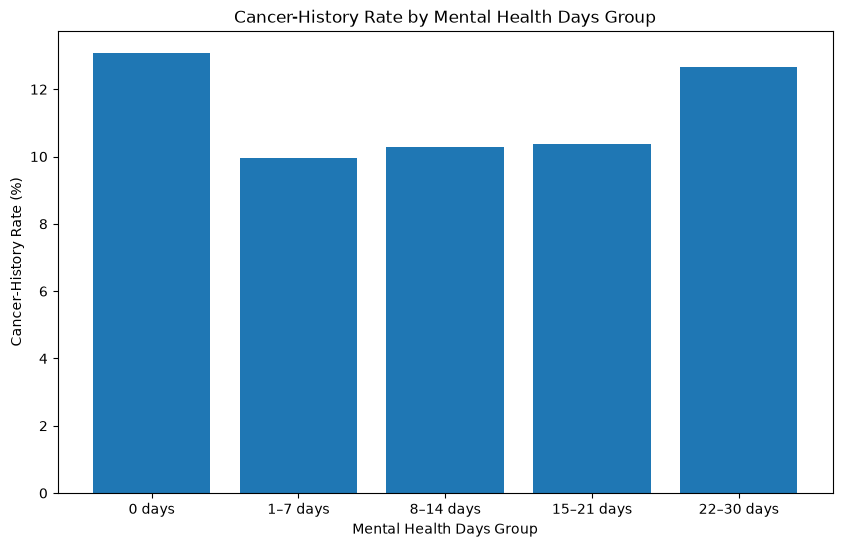

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(relationship.index.astype(str), relationship["cancer_history_rate"])
plt.title("Cancer-History Rate by Mental Health Days Group")
plt.xlabel("Mental Health Days Group")
plt.ylabel("Cancer-History Rate (%)")   

### M3 — `MENTHLTH`: Simplified Predictive Signal Check

The previous analysis showed that cancer-history rates vary across
mental-health-day groups, but the relationship is not monotonic.

We will therefore perform a second descriptive check by comparing:

- 0 days of poor mental health
- At least 1 day of poor mental health

This provides a simpler measure of whether `MENTHLTH` separates the
target population at all.

This remains a descriptive analysis and does not establish causation,
future cancer risk, or clinical significance.

In [ ]:
# Simplified MENTHLTH signal analysis

signal_analysis = df[["MENTHLTH", "target"]].copy()

# Convert BRFSS 88 ("none") to 0
signal_analysis["mental_health_days"] = (
    signal_analysis["MENTHLTH"].replace(88, 0)
)

# Create a simple binary grouping
signal_analysis["mental_health_group"] = (
    signal_analysis["mental_health_days"]
    .gt(0)
    .map({
        False: "0 days",
        True: "1+ days"
    })
)

# Compare target rates
signal_result = (
    signal_analysis
    .groupby("mental_health_group", observed=False)["target"]
    .agg(
        records="count",
        positive_cases="sum",
        cancer_history_rate="mean"
    )
)

signal_result["cancer_history_rate"] *= 100

print("MENTHLTH: 0 days vs 1+ days")
print("=" * 70)
print(signal_result.round(2))

print("\nDifference in cancer-history rate:")
rates = signal_result["cancer_history_rate"]
print(round(rates["1+ days"] - rates["0 days"], 2), "percentage points")

MENTHLTH: 0 days vs 1+ days
                     records  positive_cases  cancer_history_rate
mental_health_group                                              
0 days                268655         35130.0                13.08
1+ days               178631         18851.0                10.55

Difference in cancer-history rate:
-2.52 percentage points


### M3 — `MENTHLTH`: Target Leakage Assessment

The current CuraMind V1 target is derived from `CHCOCNC1`, which measures
whether the respondent has ever been told by a health professional that
they had cancer.

`MENTHLTH` measures the number of days during the past 30 days when the
respondent's mental health was not good.

These variables measure different concepts and `MENTHLTH` is not used
to construct the current target.

Therefore, there is no direct target leakage between `MENTHLTH` and
the current target definition.

However, absence of direct leakage does not prove predictive usefulness.

The next analysis will determine whether `MENTHLTH` provides useful
information beyond the other selected V1 features.

### M3 — `MENTHLTH`: Incremental Predictive Signal

The previous analysis showed that `MENTHLTH` is associated with the
cancer-history target, but the relationship is not monotonic.

A raw association may be explained by other variables such as age,
sex, BMI, smoking, or medical history.

We will therefore perform a stratified analysis to determine whether
the relationship between `MENTHLTH` and the target remains visible
within important existing risk-factor groups.

For this first check, we will examine `MENTHLTH` against the target
within age groups and smoking status.

This is still an M3 feature-selection analysis, not final model
training.

No records will be removed and the original dataframe will not be
modified.

In [ ]:
# Analyze MENTHLTH signal while accounting for age and smoking status

analysis = df[
    ["MENTHLTH", "_AGE80", "_SMOKER3", "target"]
].copy()

# BRFSS 88 = 0 days of poor mental health
analysis["mental_health_days"] = (
    analysis["MENTHLTH"].replace(88, 0)
)

# Create broad age groups
analysis["age_group"] = pd.cut(
    analysis["_AGE80"],
    bins=[0, 39, 49, 59, 69, 79, 120],
    labels=[
        "<40",
        "40–49",
        "50–59",
        "60–69",
        "70–79",
        "80+"
    ]
)

# Create simple mental-health groups
analysis["mental_health_group"] = (
    analysis["mental_health_days"]
    .gt(0)
    .map({
        False: "0 days",
        True: "1+ days"
    })
)

# Compare cancer-history rate by age and mental-health group
age_result = (
    analysis
    .groupby(
        ["age_group", "mental_health_group"],
        observed=False
    )["target"]
    .agg(
        records="count",
        positive_cases="sum",
        cancer_history_rate="mean"
    )
)

age_result["cancer_history_rate"] *= 100

print("MENTHLTH signal within age groups")
print("=" * 70)
print(age_result.round(2))

MENTHLTH signal within age groups
                               records  positive_cases  cancer_history_rate
age_group mental_health_group                                              
<40       0 days                 44909           465.0                 1.04
          1+ days                61909          1103.0                 1.78
40–49     0 days                 30648          1132.0                 3.69
          1+ days                29326          1655.0                 5.64
50–59     0 days                 40765          3211.0                 7.88
          1+ days                29048          3132.0                10.78
60–69     0 days                 60673          8611.0                14.19
          1+ days                28830          5098.0                17.68
70–79     0 days                 59720         13182.0                22.07
          1+ days                21356          5400.0                25.29
80+       0 days                 31940          8529.0

### MENTHLTH Signal Within Age and Smoking Groups

We now check whether the association between mental-health days and the cancer-history
proxy remains within combinations of age and smoking status.

This helps determine whether MENTHLTH provides information beyond two important
established predictors: age and smoking.

MENTHLTH:
- 88 = 0 days
- 1–30 = number of days during the past 30 days when mental health was not good

For this analysis, we group MENTHLTH into:
- 0 days
- 1+ days

In [ ]:
analysis = df[
    ["MENTHLTH", "_AGE80", "_SMOKER3", "target"]
].copy()

# Convert BRFSS 88 code to 0 days
analysis["mental_health_days"] = (
    analysis["MENTHLTH"].replace(88, 0)
)

# Age groups
analysis["age_group"] = pd.cut(
    analysis["_AGE80"],
    bins=[0, 39, 49, 59, 69, 79, 120],
    labels=[
        "<40",
        "40–49",
        "50–59",
        "60–69",
        "70–79",
        "80+"
    ]
)

# Smoking status
analysis["smoking_group"] = analysis["_SMOKER3"].map({
    1: "Current every day",
    2: "Current some days",
    3: "Former smoker",
    4: "Never smoker"
})

# Mental-health grouping
analysis["mental_health_group"] = (
    analysis["mental_health_days"]
    .gt(0)
    .map({
        False: "0 days",
        True: "1+ days"
    })
)

result = (
    analysis
    .groupby(
        [
            "age_group",
            "smoking_group",
            "mental_health_group"
        ],
        observed=False
    )["target"]
    .agg(
        records="count",
        positive_cases="sum",
        cancer_history_rate="mean"
    )
)

result["cancer_history_rate"] *= 100

print("MENTHLTH signal within age and smoking groups")
print("=" * 90)
print(result.round(2))

MENTHLTH signal within age and smoking groups
                                                 records  positive_cases  \
age_group smoking_group     mental_health_group                            
<40       Current every day 0 days                  1855            26.0   
                            1+ days                 3610           121.0   
          Current some days 0 days                  1508            13.0   
                            1+ days                 2493            59.0   
          Former smoker     0 days                  5902            97.0   
                            1+ days                 9758           246.0   
          Never smoker      0 days                 32066           295.0   
                            1+ days                42510           625.0   
40–49     Current every day 0 days                  2325            84.0   
                            1+ days                 3543           229.0   
          Current some days 0 days        

### M3 Feature Validation: Does MENTHLTH Add Predictive Value?

We compare two models using the same dataset and target:

Model A:
- Age
- Sex
- BMI
- Smoking
- Alcohol status
- Physical activity
- Diabetes
- Heart disease proxy
- COPD

Model B:
- All Model A features
- Mental-health days (`MENTHLTH`)

The purpose is to determine whether MENTHLTH provides additional predictive
information beyond the features already selected for V1.

This is a feature-selection analysis, not the final CuraMind model.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------------------
# 1. Feature sets
# -----------------------------------------

base_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3"
]

extended_features = base_features + ["MENTHLTH"]


# -----------------------------------------
# 2. Prepare analysis data
# -----------------------------------------

analysis = df[extended_features + ["target"]].copy()

# BRFSS MENTHLTH:
# 88 = 0 days of poor mental health
analysis["MENTHLTH"] = analysis["MENTHLTH"].replace(88, 0)

# Only remove rows with missing target
analysis = analysis.dropna(subset=["target"])


# -----------------------------------------
# 3. Same train/test split for both models
# -----------------------------------------

train, test = train_test_split(
    analysis,
    test_size=0.20,
    random_state=42,
    stratify=analysis["target"]
)

y_train = train["target"]
y_test = test["target"]


# -----------------------------------------
# 4. Feature groups
# -----------------------------------------

categorical_features = [
    "SEXVAR",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3"
]

numerical_base = [
    "_AGE80",
    "_BMI5"
]

numerical_extended = [
    "_AGE80",
    "_BMI5",
    "MENTHLTH"
]


# -----------------------------------------
# 5. Model-building function
# -----------------------------------------

def build_model(numerical_features):

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]),
                numerical_features
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(
                        handle_unknown="ignore"
                    ))
                ]),
                categorical_features
            )
        ]
    )

    return Pipeline([
        ("preprocessing", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced"
            )
        )
    ])


# -----------------------------------------
# 6. Model A — without MENTHLTH
# -----------------------------------------

model_base = build_model(numerical_base)

model_base.fit(
    train[base_features],
    y_train
)

base_probability = model_base.predict_proba(
    test[base_features]
)[:, 1]

base_auc = roc_auc_score(
    y_test,
    base_probability
)


# -----------------------------------------
# 7. Model B — with MENTHLTH
# -----------------------------------------

model_extended = build_model(numerical_extended)

model_extended.fit(
    train[extended_features],
    y_train
)

extended_probability = model_extended.predict_proba(
    test[extended_features]
)[:, 1]

extended_auc = roc_auc_score(
    y_test,
    extended_probability
)


# -----------------------------------------
# 8. Compare
# -----------------------------------------

auc_difference = extended_auc - base_auc

print("MENTHLTH Incremental Predictive Value")
print("=" * 60)

print(f"Model A AUC (without MENTHLTH): {base_auc:.4f}")
print(f"Model B AUC (with MENTHLTH):    {extended_auc:.4f}")
print(f"AUC improvement:                {auc_difference:+.4f}")

MENTHLTH Incremental Predictive Value
Model A AUC (without MENTHLTH): 0.7518
Model B AUC (with MENTHLTH):    0.7537
AUC improvement:                +0.0019


In [ ]:
selected_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3"
]

In [ ]:
# M3-S1: Search for variables potentially related to lumps/swelling

lump_keywords = [
    "LUMP",
    "SWELL",
    "MASS",
    "NODULE",
    "GROWTH"
]

lump_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in lump_keywords)
]

print("Potential lump/swelling variables:")
print(lump_candidates)

Potential lump/swelling variables:
[]


In [ ]:
# M3-S1: Inspect BRFSS columns for potentially related health concepts

health_keywords = [
    "CANCER",
    "BREAST",
    "SKIN",
    "ORAL",
    "MOUTH",
    "THROAT",
    "NECK",
    "SWALLOW",
    "BLEED",
    "PAIN",
    "ULCER",
    "SYMPTOM"
]

concept_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in health_keywords)
]

print("Potential symptom/cancer-related variables:")
print(concept_candidates)
print("\nNumber of candidates:", len(concept_candidates))

Potential symptom/cancer-related variables:
['CSRVPAIN']

Number of candidates: 1


In [ ]:
# M3-S1: Search for swallowing-related variables

swallow_keywords = [
    "SWALLOW",
    "DYSPH",
    "THROAT",
    "FOOD",
    "EAT"
]

swallow_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in swallow_keywords)
]

print("Potential swallowing-related variables:")
print(swallow_candidates)
print("\nNumber of candidates:", len(swallow_candidates))

Potential swallowing-related variables:
['FOODSTMP', 'SDHFOOD1', 'MARJEAT', 'HEATTBCO']

Number of candidates: 4


In [ ]:
# M3-S1: Search for voice-change related variables

voice_keywords = [
    "VOICE",
    "HOARSE",
    "HOARS",
    "SPEECH",
    "VOCAL",
    "LARYN"
]

voice_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in voice_keywords)
]

print("Potential voice-change variables:")
print(voice_candidates)
print("\nNumber of candidates:", len(voice_candidates))

Potential voice-change variables:
[]

Number of candidates: 0


In [ ]:
# M3-S1: Search for non-healing ulcer / oral-ulcer related variables

ulcer_keywords = [
    "ULCER",
    "WOUND",
    "SORE",
    "MOUTH",
    "ORAL",
    "GUM",
    "TOOTH"
]

ulcer_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in ulcer_keywords)
]

print("Potential ulcer/oral-health variables:")
print(ulcer_candidates)
print("\nNumber of candidates:", len(ulcer_candidates))

Potential ulcer/oral-health variables:
['FEETSORE']

Number of candidates: 1


In [ ]:
# M3-S1: Search for abnormal-bleeding related variables

bleeding_keywords = [
    "BLEED",
    "BLOOD",
    "HEAVY",
    "BLEEDING",
    "HEMOR",
    "MENSTR"
]

bleeding_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in bleeding_keywords)
]

print("Potential abnormal-bleeding variables:")
print(bleeding_candidates)
print("\nNumber of candidates:", len(bleeding_candidates))

Potential abnormal-bleeding variables:
[]

Number of candidates: 0


In [ ]:
# M3-S1: Search for skin-change related variables

skin_keywords = [
    "SKIN",
    "MOLE",
    "MELANOMA",
    "RASH",
    "LESION",
    "SPOT"
]

skin_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in skin_keywords)
]

print("Potential skin-change variables:")
print(skin_candidates)
print("\nNumber of candidates:", len(skin_candidates))

Potential skin-change variables:
[]

Number of candidates: 0


In [ ]:
# M3-S1: Search for appetite-related variables

appetite_keywords = [
    "APPET",
    "HUNGER",
    "EAT",
    "FOOD"
]

appetite_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in appetite_keywords)
]

print("Potential appetite-related variables:")
print(appetite_candidates)
print("\nNumber of candidates:", len(appetite_candidates))

Potential appetite-related variables:
['FOODSTMP', 'SDHFOOD1', 'MARJEAT', 'HEATTBCO']

Number of candidates: 4


In [ ]:
# M3: Search for family-history-related BRFSS variables

family_keywords = [
    "FAMILY",
    "FAM",
    "RELATIVE",
    "PARENT",
    "MOTHER",
    "FATHER",
    "SIBLING",
    "HEREDIT"
]

family_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in family_keywords)
]

print("Potential family-history variables:")
print(family_candidates)
print("\nNumber of candidates:", len(family_candidates))

Potential family-history variables:
[]

Number of candidates: 0


In [ ]:
# M3: Inspect all cancer-related BRFSS variables

cancer_candidates = [
    col for col in df.columns
    if "CNCR" in col.upper()
    or "CANCER" in col.upper()
]

print("Cancer-related variables:")
print(cancer_candidates)
print("\nNumber of candidates:", len(cancer_candidates))

Cancer-related variables:
['COLNCNCR', 'LCSSCNCR', 'CNCRDIFF', 'CNCRAGE', 'CNCRTYP2']

Number of candidates: 5


In [ ]:
# M3: Search for air-pollution/environmental exposure variables

environment_keywords = [
    "AIR",
    "POLLUT",
    "ENVIR",
    "EXPOS",
    "CHEM",
    "RADIAT",
    "SMOKE"
]

environment_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in environment_keywords)
]

print("Potential environmental-exposure variables:")
print(environment_candidates)
print("\nNumber of candidates:", len(environment_candidates))

Potential environmental-exposure variables:
['SMOKE100', '_SMOKER3']

Number of candidates: 2


In [ ]:
selected_features = [
    "_AGE80",       # Age
    "SEXVAR",       # Sex
    "_BMI5",        # BMI
    "_SMOKER3",     # Smoking status
    "DRNKANY6",     # Alcohol status
    "_TOTINDA",     # Physical activity
    "MENTHLTH",     # Mental-health days proxy
    "DIABETE4",     # Diabetes
    "_MICHD",       # Heart disease proxy
    "CHCCOPD3"      # COPD
]

In [ ]:
# M3: Air-pollution-related concept search

air_keywords = [
    "AIR",
    "POLLUTION",
    "POLLUT",
    "OUTDOOR",
    "INDOOR",
    "OZONE",
    "PARTICLE",
    "PM25",
    "SMOG",
    "DUST",
    "FUME"
]

air_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in air_keywords)
]

print("Potential air-pollution variables:")
print(air_candidates)
print("\nNumber of candidates:", len(air_candidates))

Potential air-pollution variables:
[]

Number of candidates: 0


In [ ]:
# M3: Chemical-exposure-related variable search

chemical_keywords = [
    "CHEM",
    "CHEMICAL",
    "PEST",
    "SOLVENT",
    "TOXIC",
    "POISON",
    "INDUSTR",
    "OCCUP",
    "WORK",
    "FACTORY",
    "HAZARD",
    "EXPOS"
]

chemical_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in chemical_keywords)
]

print("Potential chemical/occupational exposure variables:")
print(chemical_candidates)
print("\nNumber of candidates:", len(chemical_candidates))

Potential chemical/occupational exposure variables:
[]

Number of candidates: 0


In [ ]:
# M3: Radiation-exposure-related variable search

radiation_keywords = [
    "RADIAT",
    "RADIATION",
    "XRAY",
    "X_RAY",
    "CT",
    "NUCLEAR",
    "RADON",
    "RADIUM",
    "IONIZ",
    "RADIOTHER"
]

radiation_candidates = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in radiation_keywords)
]

print("Potential radiation-exposure variables:")
print(radiation_candidates)
print("\nNumber of candidates:", len(radiation_candidates))

Potential radiation-exposure variables:
['CTELENM1', 'CTELNUM1', 'LCSCTSC1', 'LCSCTWHN', 'CSRVCTL2', '_LCSCTSN']

Number of candidates: 6


In [ ]:
# M3: Inspect CT-related candidate variables

ct_candidates = [
    "CTELENM1",
    "CTELNUM1",
    "LCSCTSC1",
    "LCSCTWHN",
    "CSRVCTL2",
    "_LCSCTSN"
]

for col in ct_candidates:
    if col in df.columns:
        print("\n" + "=" * 70)
        print(f"VARIABLE: {col}")
        print("=" * 70)
        print("Data type:", df[col].dtype)
        print("Unique values:", df[col].nunique(dropna=False))
        print("\nValue counts:")
        print(df[col].value_counts(dropna=False).head(20))


VARIABLE: CTELENM1
Data type: float64
Unique values: 2

Value counts:
CTELENM1
NaN    369616
1.0     79898
Name: count, dtype: int64

VARIABLE: CTELNUM1
Data type: float64
Unique values: 2

Value counts:
CTELNUM1
1.0    369616
NaN     79898
Name: count, dtype: int64

VARIABLE: LCSCTSC1
Data type: float64
Unique values: 5

Value counts:
LCSCTSC1
2.0    219046
1.0    179134
NaN     35719
7.0     15043
9.0       572
Name: count, dtype: int64

VARIABLE: LCSCTWHN
Data type: float64
Unique values: 9

Value counts:
LCSCTWHN
NaN    410959
1.0     18457
2.0      5478
4.0      3555
6.0      3498
5.0      3270
3.0      3081
7.0      1140
9.0        76
Name: count, dtype: int64

VARIABLE: CSRVCTL2
Data type: float64
Unique values: 7

Value counts:
CSRVCTL2
NaN    448944
1.0       235
2.0       177
4.0        82
3.0        58
7.0        13
9.0         5
Name: count, dtype: int64

VARIABLE: _LCSCTSN
Data type: float64
Unique values: 5

Value counts:
_LCSCTSN
4.0    219046
3.0    130971
NaN     6215

In [ ]:
selected_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3"
]

In [ ]:
# M3: LCSCTSC1 target association

ct_analysis = df[
    ["LCSCTSC1", "target"]
].copy()

ct_analysis["ct_history"] = ct_analysis["LCSCTSC1"].map({
    1: "Yes",
    2: "No",
    7: pd.NA,
    9: pd.NA
})

ct_result = (
    ct_analysis
    .groupby("ct_history", observed=False)["target"]
    .agg(
        records="count",
        positive_cases="sum",
        cancer_history_rate="mean"
    )
)

ct_result["cancer_history_rate"] *= 100

print("LCSCTSC1 — Chest CT history vs cancer-history proxy")
print("=" * 70)
print(ct_result.round(2))

LCSCTSC1 — Chest CT history vs cancer-history proxy
            records  positive_cases  cancer_history_rate
ct_history                                              
No           218363         13356.0                 6.12
Yes          178027         35158.0                19.75


In [ ]:
# ============================================================
# M3 FEATURE RESEARCH
# Incremental Predictive Value Test for LCSCTSC1
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


# ============================================================
# 1. COPY DATA
# ============================================================

df_test = df.copy()


# ============================================================
# 2. CLEAN MENTHLTH
# ============================================================
# BRFSS coding:
# 1-30 = number of days mental health was not good
# 88   = none / 0 days
# 77   = don't know
# 99   = refused
#
# For this experiment:
# 88 -> 0
# 77/99 -> missing

df_test["MENTHLTH_clean"] = df_test["MENTHLTH"].replace({
    88: 0,
    77: np.nan,
    99: np.nan
})


# ============================================================
# 3. CLEAN LCSCTSC1
# ============================================================
# BRFSS coding:
# 1 = Yes
# 2 = No
# 7 = Don't know
# 9 = Refused
#
# Convert to:
# Yes -> 1
# No  -> 0
# 7/9 -> missing

df_test["LCSCTSC1_clean"] = df_test["LCSCTSC1"].map({
    1: 1,
    2: 0,
    7: np.nan,
    9: np.nan
})


# ============================================================
# 4. DEFINE BASE FEATURES
# ============================================================
# These are the current 10 V1 candidate features.

base_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH_clean",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3"
]


# ============================================================
# 5. DEFINE EXTENDED FEATURE SET
# ============================================================
# Same model + LCSCTSC1

extended_features = base_features + [
    "LCSCTSC1_clean"
]


# ============================================================
# 6. NUMERIC FEATURES
# ============================================================

numeric_features_base = [
    "_AGE80",
    "_BMI5",
    "MENTHLTH_clean"
]

numeric_features_extended = [
    "_AGE80",
    "_BMI5",
    "MENTHLTH_clean"
]


# ============================================================
# 7. CATEGORICAL FEATURES
# ============================================================

categorical_features_base = [
    "SEXVAR",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3"
]

categorical_features_extended = [
    "SEXVAR",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1_clean"
]


# ============================================================
# 8. PREPROCESSING FOR BASE MODEL
# ============================================================

numeric_transformer_base = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_base = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor_base = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_base, numeric_features_base),
        ("cat", categorical_transformer_base, categorical_features_base)
    ]
)


# ============================================================
# 9. PREPROCESSING FOR EXTENDED MODEL
# ============================================================

numeric_transformer_extended = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_extended = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor_extended = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_extended, numeric_features_extended),
        ("cat", categorical_transformer_extended, categorical_features_extended)
    ]
)


# ============================================================
# 10. LOGISTIC REGRESSION
# ============================================================
# We use Logistic Regression for this incremental AUC test
# because we want to compare whether adding one feature
# provides additional predictive information.

model_base = Pipeline(
    steps=[
        ("preprocessor", preprocessor_base),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            random_state=42
        ))
    ]
)

model_extended = Pipeline(
    steps=[
        ("preprocessor", preprocessor_extended),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            random_state=42
        ))
    ]
)


# ============================================================
# 11. PREPARE TARGET
# ============================================================

# Keep only rows where target is known.
df_test = df_test[df_test["target"].notna()].copy()

X_base = df_test[base_features]
X_extended = df_test[extended_features]

y = df_test["target"]


# ============================================================
# 12. SAME TRAIN/TEST SPLIT FOR BOTH MODELS
# ============================================================
# Using exactly the same split makes the AUC comparison fair.

X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


# Create the corresponding extended dataset using
# the SAME row indices.

X_extended_train = X_extended.loc[X_base_train.index]
X_extended_test = X_extended.loc[X_base_test.index]


# ============================================================
# 13. TRAIN BASE MODEL
# ============================================================

print("Training BASE model...")

model_base.fit(
    X_base_train,
    y_train
)


# ============================================================
# 14. TRAIN EXTENDED MODEL
# ============================================================

print("Training BASE + LCSCTSC1 model...")

model_extended.fit(
    X_extended_train,
    y_train
)


# ============================================================
# 15. GENERATE PROBABILITIES
# ============================================================

base_probabilities = model_base.predict_proba(
    X_base_test
)[:, 1]

extended_probabilities = model_extended.predict_proba(
    X_extended_test
)[:, 1]


# ============================================================
# 16. CALCULATE ROC-AUC
# ============================================================

base_auc = roc_auc_score(
    y_test,
    base_probabilities
)

extended_auc = roc_auc_score(
    y_test,
    extended_probabilities
)


# ============================================================
# 17. CALCULATE IMPROVEMENT
# ============================================================

auc_improvement = extended_auc - base_auc


# ============================================================
# 18. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 60)
print("LCSCTSC1 INCREMENTAL AUC TEST")
print("=" * 60)

print(f"Base model AUC:             {base_auc:.4f}")
print(f"Base + LCSCTSC1 AUC:        {extended_auc:.4f}")
print(f"AUC improvement:            {auc_improvement:+.4f}")

print("=" * 60)


# ============================================================
# 19. SIMPLE INTERPRETATION
# ============================================================

if auc_improvement > 0.01:
    print("Interpretation: Meaningful improvement.")
elif auc_improvement > 0:
    print("Interpretation: Small positive improvement.")
elif auc_improvement == 0:
    print("Interpretation: No improvement.")
else:
    print("Interpretation: AUC decreased.")

Training BASE model...
Training BASE + LCSCTSC1 model...

LCSCTSC1 INCREMENTAL AUC TEST
Base model AUC:             0.7537
Base + LCSCTSC1 AUC:        0.7713
AUC improvement:            +0.0176
Interpretation: Meaningful improvement.


In [ ]:
selected_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1"
]


In [ ]:
# ============================================================
# M3 — GENERAL HEALTH STATUS RESEARCH
# Step 1: Find relevant BRFSS variables
# ============================================================

# Search column names for general-health-related terms

health_keywords = [
    "GENHLTH",
    "PHYSHLTH",
    "POORHLTH",
    "HEALTH",
    "HEALTHY",
    "HLTH"
]

health_columns = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in health_keywords)
]

print("General-health-related columns found:")
print("-" * 50)

for col in health_columns:
    print(col)

print("\nTotal columns found:", len(health_columns))

General-health-related columns found:
--------------------------------------------------
GENHLTH
PHYSHLTH
MENTHLTH
POORHLTH
_RFHLTH
_HLTHPL2

Total columns found: 6


In [ ]:
# ============================================================
# M3 — GENERAL HEALTH STATUS RESEARCH
# Step 2: Inspect candidate variables
# ============================================================

health_candidates = [
    "GENHLTH",
    "PHYSHLTH",
    "POORHLTH",
    "_RFHLTH",
    "_HLTHPL2"
]

for col in health_candidates:

    print("\n" + "=" * 60)
    print(f"VARIABLE: {col}")
    print("=" * 60)

    print("\nData type:")
    print(df[col].dtype)

    print("\nMissing values:")
    print(df[col].isna().sum())

    print("\nUnique values:")
    print(df[col].nunique(dropna=False))

    print("\nValue counts:")
    print(df[col].value_counts(dropna=False).sort_index())


VARIABLE: GENHLTH

Data type:
float64

Missing values:
2

Unique values:
8

Value counts:
GENHLTH
1.0     63566
2.0    144170
3.0    153380
4.0     65915
5.0     21425
7.0       776
9.0       280
NaN         2
Name: count, dtype: int64

VARIABLE: PHYSHLTH

Data type:
float64

Missing values:
2

Unique values:
34

Value counts:
PHYSHLTH
1.0      18317
2.0      27615
3.0      16725
4.0       8891
5.0      15977
6.0       2448
7.0       9213
8.0       1822
9.0        407
10.0     10993
11.0       126
12.0      1101
13.0       151
14.0      4581
15.0      9661
16.0       294
17.0       194
18.0       340
19.0        56
20.0      6372
21.0       957
22.0       205
23.0       114
24.0       114
25.0      2449
26.0       138
27.0       242
28.0       883
29.0       403
30.0     35436
77.0      7011
88.0    264678
99.0      1598
NaN          2
Name: count, dtype: int64

VARIABLE: POORHLTH

Data type:
float64

Missing values:
189419

Unique values:
34

Value counts:
POORHLTH
1.0      12361
2.0

In [ ]:
# ============================================================
# M3 — INCREMENTAL AUC TEST
# GENHLTH and PHYSHLTH
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


# ============================================================
# 1. COPY DATA
# ============================================================

df_test = df.copy()


# ============================================================
# 2. CLEAN GENHLTH
# ============================================================
# BRFSS coding:
# 1 = Excellent
# 2 = Very good
# 3 = Good
# 4 = Fair
# 5 = Poor
# 7 = Don't know / Not sure
# 9 = Refused
#
# Keep 1-5 as valid values.
# Convert 7/9 to np.nan.

df_test["GENHLTH_clean"] = df_test["GENHLTH"].replace({
    7: np.nan,
    9: np.nan
})


# ============================================================
# 3. CLEAN PHYSHLTH
# ============================================================
# BRFSS coding:
# 1-30 = number of days physical health was not good
# 88 = none / 0 days
# 77 = don't know / not sure
# 99 = refused
#
# Convert 88 -> 0
# Convert 77/99 -> missing

df_test["PHYSHLTH_clean"] = df_test["PHYSHLTH"].replace({
    88: 0,
    77: np.nan,
    99: np.nan
})


# ============================================================
# 4. CURRENT 11-FEATURE BASELINE
# ============================================================

base_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1"
]


# ============================================================
# 5. EXTENDED FEATURE SETS
# ============================================================

genhlth_features = base_features + [
    "GENHLTH_clean"
]

physhlth_features = base_features + [
    "PHYSHLTH_clean"
]


# ============================================================
# 6. NUMERIC FEATURES
# ============================================================

numeric_base = [
    "_AGE80",
    "_BMI5",
    "MENTHLTH"
]

numeric_genhlth = [
    "_AGE80",
    "_BMI5",
    "MENTHLTH",
    "GENHLTH_clean"
]

numeric_physhlth = [
    "_AGE80",
    "_BMI5",
    "MENTHLTH",
    "PHYSHLTH_clean"
]


# ============================================================
# 7. CATEGORICAL FEATURES
# ============================================================

categorical_base = [
    "SEXVAR",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1"
]


# ============================================================
# 8. FUNCTION TO BUILD MODEL
# ============================================================

def build_model(numeric_features, categorical_features):

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(
                class_weight="balanced",
                max_iter=3000,
                random_state=42
            ))
        ]
    )

    return model


# ============================================================
# 9. REMOVE ONLY UNKNOWN TARGET VALUES
# ============================================================

df_test = df_test[
    df_test["target"].notna()
].copy()


# ============================================================
# 10. CREATE DATASETS
# ============================================================

X_base = df_test[base_features]

X_genhlth = df_test[genhlth_features]

X_physhlth = df_test[physhlth_features]

y = df_test["target"]


# ============================================================
# 11. SAME TRAIN / TEST SPLIT
# ============================================================

base_train, base_test, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


# Use the exact same rows for the other models.

genhlth_train = X_genhlth.loc[base_train.index]
genhlth_test = X_genhlth.loc[base_test.index]

physhlth_train = X_physhlth.loc[base_train.index]
physhlth_test = X_physhlth.loc[base_test.index]


# ============================================================
# 12. BUILD MODELS
# ============================================================

model_base = build_model(
    numeric_base,
    categorical_base
)

model_genhlth = build_model(
    numeric_genhlth,
    categorical_base
)

model_physhlth = build_model(
    numeric_physhlth,
    categorical_base
)


# ============================================================
# 13. TRAIN BASE MODEL
# ============================================================

print("Training BASE model...")

model_base.fit(
    base_train,
    y_train
)


# ============================================================
# 14. TRAIN BASE + GENHLTH
# ============================================================

print("Training BASE + GENHLTH model...")

model_genhlth.fit(
    genhlth_train,
    y_train
)


# ============================================================
# 15. TRAIN BASE + PHYSHLTH
# ============================================================

print("Training BASE + PHYSHLTH model...")

model_physhlth.fit(
    physhlth_train,
    y_train
)


# ============================================================
# 16. PREDICT PROBABILITIES
# ============================================================

base_prob = model_base.predict_proba(
    base_test
)[:, 1]

genhlth_prob = model_genhlth.predict_proba(
    genhlth_test
)[:, 1]

physhlth_prob = model_physhlth.predict_proba(
    physhlth_test
)[:, 1]


# ============================================================
# 17. CALCULATE ROC-AUC
# ============================================================

base_auc = roc_auc_score(
    y_test,
    base_prob
)

genhlth_auc = roc_auc_score(
    y_test,
    genhlth_prob
)

physhlth_auc = roc_auc_score(
    y_test,
    physhlth_prob
)


# ============================================================
# 18. CALCULATE IMPROVEMENTS
# ============================================================

genhlth_improvement = genhlth_auc - base_auc

physhlth_improvement = physhlth_auc - base_auc


# ============================================================
# 19. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 65)
print("GENERAL HEALTH STATUS — INCREMENTAL AUC TEST")
print("=" * 65)

print(f"Base model AUC:              {base_auc:.4f}")

print(f"Base + GENHLTH AUC:          {genhlth_auc:.4f}")
print(f"GENHLTH improvement:         {genhlth_improvement:+.4f}")

print(f"\nBase + PHYSHLTH AUC:         {physhlth_auc:.4f}")
print(f"PHYSHLTH improvement:        {physhlth_improvement:+.4f}")

print("=" * 65)


# ============================================================
# 20. INTERPRETATION
# ============================================================

print("\nINTERPRETATION")
print("-" * 65)

if genhlth_improvement > 0.01:
    print("GENHLTH: Meaningful improvement.")
elif genhlth_improvement > 0:
    print("GENHLTH: Small positive improvement.")
elif genhlth_improvement == 0:
    print("GENHLTH: No improvement.")
else:
    print("GENHLTH: AUC decreased.")


if physhlth_improvement > 0.01:
    print("PHYSHLTH: Meaningful improvement.")
elif physhlth_improvement > 0:
    print("PHYSHLTH: Small positive improvement.")
elif physhlth_improvement == 0:
    print("PHYSHLTH: No improvement.")
else:
    print("PHYSHLTH: AUC decreased.")

Training BASE model...
Training BASE + GENHLTH model...
Training BASE + PHYSHLTH model...

GENERAL HEALTH STATUS — INCREMENTAL AUC TEST
Base model AUC:              0.7715
Base + GENHLTH AUC:          0.7774
GENHLTH improvement:         +0.0059

Base + PHYSHLTH AUC:         0.7751
PHYSHLTH improvement:        +0.0036

INTERPRETATION
-----------------------------------------------------------------
GENHLTH: Small positive improvement.
PHYSHLTH: Small positive improvement.


In [ ]:
# ============================================================
# M3 — COMBINED INCREMENTAL AUC TEST
# GENHLTH + PHYSHLTH
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


# ============================================================
# 1. COPY DATA
# ============================================================

df_test = df.copy()


# ============================================================
# 2. CLEAN MENTHLTH
# ============================================================

# 88 = 0 days
# 77 = Don't know / Not sure
# 99 = Refused

df_test["MENTHLTH_clean"] = df_test["MENTHLTH"].replace({
    88: 0,
    77: np.nan,
    99: np.nan
})


# ============================================================
# 3. CLEAN LCSCTSC1
# ============================================================

# 1 = Yes
# 2 = No
# 7 = Don't know
# 9 = Refused

df_test["LCSCTSC1_clean"] = df_test["LCSCTSC1"].map({
    1: 1,
    2: 0,
    7: np.nan,
    9: np.nan
})


# ============================================================
# 4. CLEAN GENHLTH
# ============================================================

# 1 = Excellent
# 2 = Very good
# 3 = Good
# 4 = Fair
# 5 = Poor
# 7 = Don't know
# 9 = Refused

df_test["GENHLTH_clean"] = df_test["GENHLTH"].replace({
    7: np.nan,
    9: np.nan
})


# ============================================================
# 5. CLEAN PHYSHLTH
# ============================================================

# 1–30 = number of physically unhealthy days
# 88 = 0 days
# 77 = Don't know
# 99 = Refused

df_test["PHYSHLTH_clean"] = df_test["PHYSHLTH"].replace({
    88: 0,
    77: np.nan,
    99: np.nan
})


# ============================================================
# 6. CURRENT 11-FEATURE BASELINE
# ============================================================

base_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH_clean",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1_clean"
]


# ============================================================
# 7. COMBINED FEATURE SET
# ============================================================

combined_features = base_features + [
    "GENHLTH_clean",
    "PHYSHLTH_clean"
]


# ============================================================
# 8. NUMERIC FEATURES
# ============================================================

numeric_base = [
    "_AGE80",
    "_BMI5",
    "MENTHLTH_clean"
]

numeric_combined = [
    "_AGE80",
    "_BMI5",
    "MENTHLTH_clean",
    "GENHLTH_clean",
    "PHYSHLTH_clean"
]


# ============================================================
# 9. CATEGORICAL FEATURES
# ============================================================

categorical_features = [
    "SEXVAR",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1_clean"
]


# ============================================================
# 10. MODEL-BUILDING FUNCTION
# ============================================================

def build_model(numeric_features, categorical_features):

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(
                class_weight="balanced",
                max_iter=3000,
                random_state=42
            ))
        ]
    )

    return model


# ============================================================
# 11. REMOVE UNKNOWN TARGET VALUES
# ============================================================

df_test = df_test[
    df_test["target"].notna()
].copy()


# ============================================================
# 12. CREATE X AND Y
# ============================================================

X_base = df_test[base_features]

X_combined = df_test[combined_features]

y = df_test["target"]


# ============================================================
# 13. SAME TRAIN / TEST SPLIT
# ============================================================

X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


# ============================================================
# 14. USE SAME ROWS FOR COMBINED MODEL
# ============================================================

X_combined_train = X_combined.loc[
    X_base_train.index
]

X_combined_test = X_combined.loc[
    X_base_test.index
]


# ============================================================
# 15. BUILD MODELS
# ============================================================

model_base = build_model(
    numeric_base,
    categorical_features
)

model_combined = build_model(
    numeric_combined,
    categorical_features
)


# ============================================================
# 16. TRAIN BASE MODEL
# ============================================================

print("Training BASE model...")

model_base.fit(
    X_base_train,
    y_train
)


# ============================================================
# 17. TRAIN COMBINED MODEL
# ============================================================

print("Training BASE + GENHLTH + PHYSHLTH model...")

model_combined.fit(
    X_combined_train,
    y_train
)


# ============================================================
# 18. PREDICT PROBABILITIES
# ============================================================

base_probabilities = model_base.predict_proba(
    X_base_test
)[:, 1]

combined_probabilities = model_combined.predict_proba(
    X_combined_test
)[:, 1]


# ============================================================
# 19. CALCULATE ROC-AUC
# ============================================================

base_auc = roc_auc_score(
    y_test,
    base_probabilities
)

combined_auc = roc_auc_score(
    y_test,
    combined_probabilities
)


# ============================================================
# 20. CALCULATE IMPROVEMENT
# ============================================================

combined_improvement = combined_auc - base_auc


# ============================================================
# 21. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 70)
print("COMBINED GENERAL HEALTH STATUS — INCREMENTAL AUC TEST")
print("=" * 70)

print(f"Base 11-feature AUC:                    {base_auc:.4f}")

print(
    f"Base + GENHLTH + PHYSHLTH AUC:         "
    f"{combined_auc:.4f}"
)

print(
    f"Combined AUC improvement:               "
    f"{combined_improvement:+.4f}"
)

print("=" * 70)


# ============================================================
# 22. INTERPRETATION
# ============================================================

print("\nINTERPRETATION")
print("-" * 70)

if combined_improvement > 0.01:
    print(
        "GENHLTH + PHYSHLTH: Meaningful combined improvement."
    )

elif combined_improvement > 0:
    print(
        "GENHLTH + PHYSHLTH: Small positive combined improvement."
    )

elif combined_improvement == 0:
    print(
        "GENHLTH + PHYSHLTH: No combined improvement."
    )

else:
    print(
        "GENHLTH + PHYSHLTH: AUC decreased."
    )

Training BASE model...
Training BASE + GENHLTH + PHYSHLTH model...

COMBINED GENERAL HEALTH STATUS — INCREMENTAL AUC TEST
Base 11-feature AUC:                    0.7713
Base + GENHLTH + PHYSHLTH AUC:         0.7779
Combined AUC improvement:               +0.0066

INTERPRETATION
----------------------------------------------------------------------
GENHLTH + PHYSHLTH: Small positive combined improvement.


In [ ]:
selected_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1",
    "GENHLTH",
    "PHYSHLTH"
]

Original baseline
      ↓
10 features
      ↓
+ MENTHLTH
      ↓
11 features
      ↓
+ LCSCTSC1
      ↓
11-feature baseline used here
      ↓
+ GENHLTH
+ PHYSHLTH
      ↓
13 V1 candidate features
      ↓
AUC = 0.7779

# M3 — Feature Research & Selection

## Progress So Far 🧠

We researched the CuraMind assessment concepts against BRFSS 2024 and tested promising variables incrementally.

### Current V1 candidate features

* Age — `_AGE80`
* Sex — `SEXVAR`
* BMI — `_BMI5`
* Smoking — `_SMOKER3`
* Alcohol use — `DRNKANY6`
* Physical activity — `_TOTINDA`
* Mental health — `MENTHLTH`
* Diabetes — `DIABETE4`
* Heart disease — `_MICHD`
* COPD — `CHCCOPD3`
* Chest CT history — `LCSCTSC1`
* General health — `GENHLTH`
* Physical health days — `PHYSHLTH`

### Predictive testing

We used **incremental ROC-AUC testing** to check whether promising features added information beyond the existing baseline.

* `MENTHLTH` → **+0.0019**
* `LCSCTSC1` → **+0.0176**
* `GENHLTH` + `PHYSHLTH` together → **+0.0066**

Therefore, these are currently retained as **V1 candidates**.

### Features we did not select

* `_RFHLTH` → 🔴 redundant with `GENHLTH`
* Family cancer history → 🔵 future / 🟡 frontend because no suitable BRFSS 2024 variable was found
* Symptoms → 🟡 frontend / 🔵 future because BRFSS did not provide valid matching symptom variables
* Environmental exposure → 🟡 frontend / 🔵 future because suitable BRFSS variables were not identified
* Medical report upload → 🔵 skipped for this hackathon V1

> **Current status: 13 V1 candidate features. M3 is still ongoing.**

---

# M3 — Next Research

## Healthcare Access & Utilization 🔎

We now move to the next area:

> **Can healthcare-access information provide useful, non-leaky information for CuraMind's first ML baseline?**

This area is worth investigating because BRFSS contains questions related to access to healthcare, while CuraMind is ultimately intended as a **screening/risk-assessment system**.

### What we'll investigate

We'll look for variables covering concepts such as:

* Health insurance
* Primary healthcare provider
* Difficulty accessing healthcare
* Delayed medical care
* Cost-related barriers
* Routine healthcare visits

### ⚠️ Important leakage check

We need to be especially careful with variables related to:

* Cancer screening
* Cancer diagnosis
* Cancer treatment
* Cancer survivorship
* Previous cancer

A variable may dramatically improve AUC simply because it indirectly reveals that someone already had cancer.

That would **not** make it a valid feature.

Our process remains:

```text
Healthcare concept
        ↓
BRFSS 2024 variable
        ↓
Official definition
        ↓
Missingness / coding
        ↓
Leakage check
        ↓
Redundancy check
        ↓
Incremental AUC test
        ↓
🟢 V1 / 🟡 Frontend / 🔵 Future / 🔴 Exclude
```

### First target

We already discovered:

```text
_HLTHPL2
```

which appears to represent **health insurance coverage**.

Rather than immediately testing it, we'll first search the dataframe for the **full healthcare-access variable family** and then inspect the relevant variables individually.

**Next: identify the BRFSS 2024 healthcare-access variables.** 🔬


In [ ]:
# ============================================================
# M3 — HEALTHCARE ACCESS & UTILIZATION RESEARCH
# Step 1: Find candidate BRFSS variables
# ============================================================

healthcare_keywords = [
    "INSUR",
    "PRIM",
    "COST",
    "DELAY",
    "ACCESS",
    "CARE",
    "CHECK",
    "DOCTOR",
    "PROVIDER",
    "MEDICAL",
    "HEALTHCARE",
    "ROUTINE",
    "VISIT"
]

healthcare_columns = [
    col for col in df.columns
    if any(keyword in col.upper() for keyword in healthcare_keywords)
]

print("Healthcare-access-related columns found:")
print("-" * 60)

for col in healthcare_columns:
    print(col)

print("\nTotal columns found:", len(healthcare_columns))

Healthcare-access-related columns found:
------------------------------------------------------------
PRIMINS2
MEDCOST1
CHECKUP1
CAREGIV1

Total columns found: 4


In [ ]:
# ============================================================
# M3 — HEALTHCARE ACCESS & UTILIZATION
# Step 2: Inspect candidate variables
# ============================================================

healthcare_candidates = [
    "PRIMINS2",
    "MEDCOST1",
    "CHECKUP1",
    "CAREGIV1",
    "_HLTHPL2"
]

for col in healthcare_candidates:

    print("\n" + "=" * 60)
    print(f"VARIABLE: {col}")
    print("=" * 60)

    print("\nData type:")
    print(df[col].dtype)

    print("\nMissing values:")
    print(df[col].isna().sum())

    print("\nUnique values:")
    print(df[col].nunique(dropna=False))

    print("\nValue counts:")
    print(df[col].value_counts(dropna=False).sort_index())


VARIABLE: PRIMINS2

Data type:
float64

Missing values:
1

Unique values:
14

Value counts:
PRIMINS2
1.0     153819
2.0      38103
3.0     142829
4.0        379
5.0      32015
6.0        140
7.0      16583
8.0       1382
9.0      12083
10.0      9889
77.0     11874
88.0     24745
99.0      5672
NaN          1
Name: count, dtype: int64

VARIABLE: MEDCOST1

Data type:
float64

Missing values:
4

Unique values:
5

Value counts:
MEDCOST1
1.0     42181
2.0    405931
7.0      1072
9.0       326
NaN         4
Name: count, dtype: int64

VARIABLE: CHECKUP1

Data type:
float64

Missing values:
0

Unique values:
7

Value counts:
CHECKUP1
1.0    363816
2.0     39003
3.0     21129
4.0     18019
7.0      4273
8.0      2692
9.0       582
Name: count, dtype: int64

VARIABLE: CAREGIV1

Data type:
float64

Missing values:
354847

Unique values:
6

Value counts:
CAREGIV1
1.0     20812
2.0     73332
7.0       224
8.0       204
9.0        95
NaN    354847
Name: count, dtype: int64

VARIABLE: _HLTHPL2

Dat

In [ ]:
# ============================================================
# M3 — HEALTHCARE ACCESS & UTILIZATION
# Incremental ROC-AUC Test
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


# ============================================================
# 1. COPY DATA
# ============================================================

df_test = df.copy()


# ============================================================
# 2. CLEAN EXISTING FEATURES
# ============================================================

# ----------------------------
# MENTHLTH
# ----------------------------
# 88 = 0 days
# 77/99 = unknown/refused

df_test["MENTHLTH_clean"] = df_test["MENTHLTH"].replace({
    88: 0,
    77: np.nan,
    99: np.nan
})


# ----------------------------
# LCSCTSC1
# ----------------------------
# 1 = Yes
# 2 = No
# 7/9 = unknown/refused

df_test["LCSCTSC1_clean"] = df_test["LCSCTSC1"].map({
    1: 1,
    2: 0,
    7: np.nan,
    9: np.nan
})


# ============================================================
# 3. CLEAN HEALTHCARE VARIABLES
# ============================================================

# ----------------------------
# _HLTHPL2
# ----------------------------
# 1 = Has health insurance
# 2 = No health insurance
# 9 = Unknown

df_test["HLTHPL2_clean"] = df_test["_HLTHPL2"].replace({
    9: np.nan
})


# ----------------------------
# MEDCOST1
# ----------------------------
# 1 = Yes
# 2 = No
# 7 = Don't know
# 9 = Refused

df_test["MEDCOST1_clean"] = df_test["MEDCOST1"].replace({
    7: np.nan,
    9: np.nan
})


# ----------------------------
# CHECKUP1
# ----------------------------
# 1-4 = valid time categories
# 7/8/9 = unknown/refused/not applicable
#
# Keep 1-4 as categorical values.

df_test["CHECKUP1_clean"] = df_test["CHECKUP1"].replace({
    7: np.nan,
    8: np.nan,
    9: np.nan
})


# ============================================================
# 4. CURRENT 13-FEATURE BASELINE
# ============================================================

base_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH_clean",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1_clean",
    "GENHLTH_clean",
    "PHYSHLTH_clean"
]


# ============================================================
# 5. MAKE SURE GENHLTH AND PHYSHLTH ARE CLEANED
# ============================================================

df_test["GENHLTH_clean"] = df_test["GENHLTH"].replace({
    7: np.nan,
    9: np.nan
})

df_test["PHYSHLTH_clean"] = df_test["PHYSHLTH"].replace({
    88: 0,
    77: np.nan,
    99: np.nan
})


# ============================================================
# 6. ADD EACH CANDIDATE SEPARATELY
# ============================================================

insurance_features = base_features + [
    "HLTHPL2_clean"
]

medcost_features = base_features + [
    "MEDCOST1_clean"
]

checkup_features = base_features + [
    "CHECKUP1_clean"
]


# ============================================================
# 7. NUMERIC FEATURES
# ============================================================

numeric_base = [
    "_AGE80",
    "_BMI5",
    "MENTHLTH_clean",
    "GENHLTH_clean",
    "PHYSHLTH_clean"
]


numeric_insurance = numeric_base

numeric_medcost = numeric_base

numeric_checkup = numeric_base


# ============================================================
# 8. CATEGORICAL FEATURES
# ============================================================

categorical_base = [
    "SEXVAR",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1_clean"
]


categorical_insurance = categorical_base + [
    "HLTHPL2_clean"
]

categorical_medcost = categorical_base + [
    "MEDCOST1_clean"
]

categorical_checkup = categorical_base + [
    "CHECKUP1_clean"
]


# ============================================================
# 9. MODEL-BUILDING FUNCTION
# ============================================================

def build_model(numeric_features, categorical_features):

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(
                class_weight="balanced",
                max_iter=3000,
                random_state=42
            ))
        ]
    )

    return model


# ============================================================
# 10. REMOVE UNKNOWN TARGET VALUES
# ============================================================

df_test = df_test[
    df_test["target"].notna()
].copy()


# ============================================================
# 11. CREATE DATASETS
# ============================================================

X_base = df_test[base_features]

X_insurance = df_test[insurance_features]

X_medcost = df_test[medcost_features]

X_checkup = df_test[checkup_features]

y = df_test["target"]


# ============================================================
# 12. SAME TRAIN / TEST SPLIT
# ============================================================

X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


# ============================================================
# 13. APPLY SAME ROW SPLIT TO ALL CANDIDATES
# ============================================================

X_insurance_train = X_insurance.loc[
    X_base_train.index
]

X_insurance_test = X_insurance.loc[
    X_base_test.index
]


X_medcost_train = X_medcost.loc[
    X_base_train.index
]

X_medcost_test = X_medcost.loc[
    X_base_test.index
]


X_checkup_train = X_checkup.loc[
    X_base_train.index
]

X_checkup_test = X_checkup.loc[
    X_base_test.index
]


# ============================================================
# 14. BUILD MODELS
# ============================================================

model_base = build_model(
    numeric_base,
    categorical_base
)

model_insurance = build_model(
    numeric_insurance,
    categorical_insurance
)

model_medcost = build_model(
    numeric_medcost,
    categorical_medcost
)

model_checkup = build_model(
    numeric_checkup,
    categorical_checkup
)


# ============================================================
# 15. TRAIN BASELINE
# ============================================================

print("Training BASE 13-feature model...")

model_base.fit(
    X_base_train,
    y_train
)


# ============================================================
# 16. TRAIN + INSURANCE
# ============================================================

print("Training BASE + _HLTHPL2 model...")

model_insurance.fit(
    X_insurance_train,
    y_train
)


# ============================================================
# 17. TRAIN + MEDCOST1
# ============================================================

print("Training BASE + MEDCOST1 model...")

model_medcost.fit(
    X_medcost_train,
    y_train
)


# ============================================================
# 18. TRAIN + CHECKUP1
# ============================================================

print("Training BASE + CHECKUP1 model...")

model_checkup.fit(
    X_checkup_train,
    y_train
)


# ============================================================
# 19. PREDICT PROBABILITIES
# ============================================================

base_prob = model_base.predict_proba(
    X_base_test
)[:, 1]

insurance_prob = model_insurance.predict_proba(
    X_insurance_test
)[:, 1]

medcost_prob = model_medcost.predict_proba(
    X_medcost_test
)[:, 1]

checkup_prob = model_checkup.predict_proba(
    X_checkup_test
)[:, 1]


# ============================================================
# 20. CALCULATE ROC-AUC
# ============================================================

base_auc = roc_auc_score(
    y_test,
    base_prob
)

insurance_auc = roc_auc_score(
    y_test,
    insurance_prob
)

medcost_auc = roc_auc_score(
    y_test,
    medcost_prob
)

checkup_auc = roc_auc_score(
    y_test,
    checkup_prob
)


# ============================================================
# 21. CALCULATE IMPROVEMENTS
# ============================================================

insurance_improvement = insurance_auc - base_auc

medcost_improvement = medcost_auc - base_auc

checkup_improvement = checkup_auc - base_auc


# ============================================================
# 22. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 75)
print("HEALTHCARE ACCESS — INCREMENTAL ROC-AUC TEST")
print("=" * 75)

print(f"Base 13-feature AUC:                  {base_auc:.4f}")

print(
    f"\nBase + _HLTHPL2 AUC:                 "
    f"{insurance_auc:.4f}"
)

print(
    f"_HLTHPL2 improvement:                "
    f"{insurance_improvement:+.4f}"
)

print(
    f"\nBase + MEDCOST1 AUC:                 "
    f"{medcost_auc:.4f}"
)

print(
    f"MEDCOST1 improvement:                "
    f"{medcost_improvement:+.4f}"
)

print(
    f"\nBase + CHECKUP1 AUC:                 "
    f"{checkup_auc:.4f}"
)

print(
    f"CHECKUP1 improvement:                "
    f"{checkup_improvement:+.4f}"
)

print("=" * 75)

Training BASE 13-feature model...
Training BASE + _HLTHPL2 model...
Training BASE + MEDCOST1 model...
Training BASE + CHECKUP1 model...

HEALTHCARE ACCESS — INCREMENTAL ROC-AUC TEST
Base 13-feature AUC:                  0.7779

Base + _HLTHPL2 AUC:                 0.7784
_HLTHPL2 improvement:                +0.0005

Base + MEDCOST1 AUC:                 0.7779
MEDCOST1 improvement:                +0.0001

Base + CHECKUP1 AUC:                 0.7788
CHECKUP1 improvement:                +0.0009


In [ ]:
# ============================================================
# M3 — COMBINED HEALTHCARE ACCESS TEST
# _HLTHPL2 + MEDCOST1 + CHECKUP1
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


# ============================================================
# 1. COPY DATA
# ============================================================

df_test = df.copy()


# ============================================================
# 2. CLEAN EXISTING FEATURES
# ============================================================

# MENTHLTH
# 88 = 0 days
# 77/99 = unknown/refused

df_test["MENTHLTH_clean"] = df_test["MENTHLTH"].replace({
    88: 0,
    77: np.nan,
    99: np.nan
})


# LCSCTSC1
# 1 = Yes
# 2 = No
# 7/9 = unknown/refused

df_test["LCSCTSC1_clean"] = df_test["LCSCTSC1"].map({
    1: 1,
    2: 0,
    7: np.nan,
    9: np.nan
})


# GENHLTH
# 1-5 = valid
# 7/9 = unknown/refused

df_test["GENHLTH_clean"] = df_test["GENHLTH"].replace({
    7: np.nan,
    9: np.nan
})


# PHYSHLTH
# 1-30 = days
# 88 = 0
# 77/99 = unknown/refused

df_test["PHYSHLTH_clean"] = df_test["PHYSHLTH"].replace({
    88: 0,
    77: np.nan,
    99: np.nan
})


# ============================================================
# 3. CLEAN HEALTHCARE VARIABLES
# ============================================================

# ------------------------------------------------------------
# _HLTHPL2
# ------------------------------------------------------------
# 1 = Has health insurance
# 2 = No health insurance
# 9 = Unknown

df_test["HLTHPL2_clean"] = df_test["_HLTHPL2"].replace({
    9: np.nan
})


# ------------------------------------------------------------
# MEDCOST1
# ------------------------------------------------------------
# 1 = Yes
# 2 = No
# 7 = Don't know
# 9 = Refused

df_test["MEDCOST1_clean"] = df_test["MEDCOST1"].replace({
    7: np.nan,
    9: np.nan
})


# ------------------------------------------------------------
# CHECKUP1
# ------------------------------------------------------------
# 1-4 = valid categories
# 7/8/9 = unknown/refused/not applicable

df_test["CHECKUP1_clean"] = df_test["CHECKUP1"].replace({
    7: np.nan,
    8: np.nan,
    9: np.nan
})


# ============================================================
# 4. CURRENT 13-FEATURE BASELINE
# ============================================================

base_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH_clean",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1_clean",
    "GENHLTH_clean",
    "PHYSHLTH_clean"
]


# ============================================================
# 5. COMBINED HEALTHCARE FEATURE SET
# ============================================================

combined_features = base_features + [
    "HLTHPL2_clean",
    "MEDCOST1_clean",
    "CHECKUP1_clean"
]


# ============================================================
# 6. NUMERIC FEATURES
# ============================================================

numeric_base = [
    "_AGE80",
    "_BMI5",
    "MENTHLTH_clean",
    "GENHLTH_clean",
    "PHYSHLTH_clean"
]


numeric_combined = [
    "_AGE80",
    "_BMI5",
    "MENTHLTH_clean",
    "GENHLTH_clean",
    "PHYSHLTH_clean"
]


# ============================================================
# 7. CATEGORICAL FEATURES
# ============================================================

categorical_base = [
    "SEXVAR",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1_clean"
]


categorical_combined = categorical_base + [
    "HLTHPL2_clean",
    "MEDCOST1_clean",
    "CHECKUP1_clean"
]


# ============================================================
# 8. MODEL BUILDING FUNCTION
# ============================================================

def build_model(numeric_features, categorical_features):

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ))
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(
                class_weight="balanced",
                max_iter=3000,
                random_state=42
            ))
        ]
    )

    return model


# ============================================================
# 9. REMOVE UNKNOWN TARGET VALUES
# ============================================================

df_test = df_test[
    df_test["target"].notna()
].copy()


# ============================================================
# 10. CREATE X AND Y
# ============================================================

X_base = df_test[base_features]

X_combined = df_test[combined_features]

y = df_test["target"]


# ============================================================
# 11. SAME TRAIN / TEST SPLIT
# ============================================================

X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


# ============================================================
# 12. USE EXACT SAME ROWS FOR COMBINED MODEL
# ============================================================

X_combined_train = X_combined.loc[
    X_base_train.index
]

X_combined_test = X_combined.loc[
    X_base_test.index
]


# ============================================================
# 13. BUILD MODELS
# ============================================================

model_base = build_model(
    numeric_base,
    categorical_base
)

model_combined = build_model(
    numeric_combined,
    categorical_combined
)


# ============================================================
# 14. TRAIN BASE MODEL
# ============================================================

print("Training BASE 13-feature model...")

model_base.fit(
    X_base_train,
    y_train
)


# ============================================================
# 15. TRAIN COMBINED MODEL
# ============================================================

print(
    "Training BASE + _HLTHPL2 + MEDCOST1 + CHECKUP1 model..."
)

model_combined.fit(
    X_combined_train,
    y_train
)


# ============================================================
# 16. PREDICT PROBABILITIES
# ============================================================

base_probabilities = model_base.predict_proba(
    X_base_test
)[:, 1]

combined_probabilities = model_combined.predict_proba(
    X_combined_test
)[:, 1]


# ============================================================
# 17. CALCULATE ROC-AUC
# ============================================================

base_auc = roc_auc_score(
    y_test,
    base_probabilities
)

combined_auc = roc_auc_score(
    y_test,
    combined_probabilities
)


# ============================================================
# 18. CALCULATE IMPROVEMENT
# ============================================================

combined_improvement = combined_auc - base_auc


# ============================================================
# 19. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 75)
print("COMBINED HEALTHCARE ACCESS — INCREMENTAL ROC-AUC TEST")
print("=" * 75)

print(
    f"Base 13-feature AUC:                       "
    f"{base_auc:.4f}"
)

print(
    f"Base + all 3 healthcare features AUC:     "
    f"{combined_auc:.4f}"
)

print(
    f"Combined AUC improvement:                  "
    f"{combined_improvement:+.4f}"
)

print("=" * 75)


# ============================================================
# 20. SIMPLE INTERPRETATION
# ============================================================

print("\nINTERPRETATION")
print("-" * 75)

if combined_improvement > 0.01:

    print(
        "Healthcare features provide a meaningful "
        "combined improvement."
    )

elif combined_improvement > 0:

    print(
        "Healthcare features provide a small positive "
        "combined improvement."
    )

elif combined_improvement == 0:

    print(
        "Healthcare features provide no combined "
        "improvement."
    )

else:

    print(
        "Healthcare features decrease the model AUC."
    )

Training BASE 13-feature model...
Training BASE + _HLTHPL2 + MEDCOST1 + CHECKUP1 model...

COMBINED HEALTHCARE ACCESS — INCREMENTAL ROC-AUC TEST
Base 13-feature AUC:                       0.7779
Base + all 3 healthcare features AUC:     0.7791
Combined AUC improvement:                  +0.0012

INTERPRETATION
---------------------------------------------------------------------------
Healthcare features provide a small positive combined improvement.


In [ ]:
# ============================================================
# M3 — PRIMINS2 vs _HLTHPL2
# Step 1: Inspect redundancy
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("PRIMINS2 — PRIMARY INSURANCE TYPE")
print("=" * 70)

print("\nPRIMINS2 value counts:")
print(df["PRIMINS2"].value_counts(dropna=False).sort_index())


print("\n" + "=" * 70)
print("_HLTHPL2 — INSURANCE COVERAGE")
print("=" * 70)

print("\n_HLTHPL2 value counts:")
print(df["_HLTHPL2"].value_counts(dropna=False).sort_index())


# ============================================================
# CROSS-TABULATION
# ============================================================

print("\n" + "=" * 70)
print("PRIMINS2 vs _HLTHPL2 CROSS-TAB")
print("=" * 70)

crosstab = pd.crosstab(
    df["PRIMINS2"],
    df["_HLTHPL2"],
    dropna=False
)

print(crosstab)

PRIMINS2 — PRIMARY INSURANCE TYPE

PRIMINS2 value counts:
PRIMINS2
1.0     153819
2.0      38103
3.0     142829
4.0        379
5.0      32015
6.0        140
7.0      16583
8.0       1382
9.0      12083
10.0      9889
77.0     11874
88.0     24745
99.0      5672
NaN          1
Name: count, dtype: int64

_HLTHPL2 — INSURANCE COVERAGE

_HLTHPL2 value counts:
_HLTHPL2
1.0    407222
2.0     24745
9.0     17547
Name: count, dtype: int64

PRIMINS2 vs _HLTHPL2 CROSS-TAB
_HLTHPL2     1.0    2.0    9.0
PRIMINS2                      
1.0       153818      1      0
2.0        38103      0      0
3.0       142829      0      0
4.0          379      0      0
5.0        32015      0      0
6.0          140      0      0
7.0        16583      0      0
8.0         1382      0      0
9.0        12083      0      0
10.0        9889      0      0
77.0           0      0  11874
88.0           1  24744      0
99.0           0      0   5672
NaN            0      0      1


In [ ]:
# ============================================================
# M3 — PRIMINS2 INCREMENTAL AUC TEST
# Test whether detailed insurance type adds value
# beyond _HLTHPL2 + MEDCOST1 + CHECKUP1
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


# ============================================================
# 1. COPY DATA
# ============================================================

df_test = df.copy()


# ============================================================
# 2. CLEAN EXISTING FEATURES
# ============================================================

# ------------------------------------------------------------
# MENTHLTH
# ------------------------------------------------------------

df_test["MENTHLTH_clean"] = df_test["MENTHLTH"].replace({
    88: 0,
    77: np.nan,
    99: np.nan
})


# ------------------------------------------------------------
# LCSCTSC1
# ------------------------------------------------------------

df_test["LCSCTSC1_clean"] = df_test["LCSCTSC1"].map({
    1: 1,
    2: 0,
    7: np.nan,
    9: np.nan
})


# ------------------------------------------------------------
# GENHLTH
# ------------------------------------------------------------

df_test["GENHLTH_clean"] = df_test["GENHLTH"].replace({
    7: np.nan,
    9: np.nan
})


# ------------------------------------------------------------
# PHYSHLTH
# ------------------------------------------------------------

df_test["PHYSHLTH_clean"] = df_test["PHYSHLTH"].replace({
    88: 0,
    77: np.nan,
    99: np.nan
})


# ============================================================
# 3. CLEAN HEALTHCARE VARIABLES
# ============================================================

# ------------------------------------------------------------
# _HLTHPL2
# ------------------------------------------------------------

df_test["HLTHPL2_clean"] = df_test["_HLTHPL2"].replace({
    9: np.nan
})


# ------------------------------------------------------------
# MEDCOST1
# ------------------------------------------------------------

df_test["MEDCOST1_clean"] = df_test["MEDCOST1"].replace({
    7: np.nan,
    9: np.nan
})


# ------------------------------------------------------------
# CHECKUP1
# ------------------------------------------------------------

df_test["CHECKUP1_clean"] = df_test["CHECKUP1"].replace({
    7: np.nan,
    8: np.nan,
    9: np.nan
})


# ============================================================
# 4. CLEAN PRIMINS2
# ============================================================
#
# Valid insurance categories:
# 1–10 = insurance types
# 88 = no coverage
# 77 = don't know
# 99 = refused
#
# Treat PRIMINS2 as CATEGORICAL.
#
# 77, 99 and missing are represented as np.nan.
# 88 remains a valid "no coverage" category.

df_test["PRIMINS2_clean"] = df_test["PRIMINS2"].replace({
    77: np.nan,
    99: np.nan
})


# ============================================================
# 5. CURRENT 16-FEATURE HEALTHCARE BASELINE
# ============================================================

base_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH_clean",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1_clean",
    "GENHLTH_clean",
    "PHYSHLTH_clean",
    "HLTHPL2_clean",
    "MEDCOST1_clean",
    "CHECKUP1_clean"
]


# ============================================================
# 6. EXTENDED FEATURE SET
# ============================================================

primins_features = base_features + [
    "PRIMINS2_clean"
]


# ============================================================
# 7. NUMERIC FEATURES
# ============================================================

numeric_base = [
    "_AGE80",
    "_BMI5",
    "MENTHLTH_clean",
    "GENHLTH_clean",
    "PHYSHLTH_clean"
]


numeric_primins = numeric_base.copy()


# ============================================================
# 8. CATEGORICAL FEATURES
# ============================================================

categorical_base = [
    "SEXVAR",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1_clean",
    "HLTHPL2_clean",
    "MEDCOST1_clean",
    "CHECKUP1_clean"
]


categorical_primins = categorical_base + [
    "PRIMINS2_clean"
]


# ============================================================
# 9. MODEL BUILDING FUNCTION
# ============================================================

def build_model(numeric_features, categorical_features):

    numeric_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="median")
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                )
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_transformer,
                numeric_features
            ),
            (
                "cat",
                categorical_transformer,
                categorical_features
            )
        ]
    )

    model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=3000,
                    random_state=42
                )
            )
        ]
    )

    return model


# ============================================================
# 10. REMOVE UNKNOWN TARGET VALUES
# ============================================================

df_test = df_test[
    df_test["target"].notna()
].copy()


# ============================================================
# 11. CREATE DATASETS
# ============================================================

X_base = df_test[base_features]

X_primins = df_test[primins_features]

y = df_test["target"]


# ============================================================
# 12. SAME TRAIN / TEST SPLIT
# ============================================================

X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


# ============================================================
# 13. SAME ROWS FOR PRIMINS2 MODEL
# ============================================================

X_primins_train = X_primins.loc[
    X_base_train.index
]

X_primins_test = X_primins.loc[
    X_base_test.index
]


# ============================================================
# 14. BUILD MODELS
# ============================================================

model_base = build_model(
    numeric_base,
    categorical_base
)

model_primins = build_model(
    numeric_primins,
    categorical_primins
)


# ============================================================
# 15. TRAIN BASE MODEL
# ============================================================

print("Training BASE 16-feature healthcare model...")

model_base.fit(
    X_base_train,
    y_train
)


# ============================================================
# 16. TRAIN PRIMINS2 MODEL
# ============================================================

print(
    "Training BASE + PRIMINS2 model..."
)

model_primins.fit(
    X_primins_train,
    y_train
)


# ============================================================
# 17. PREDICT PROBABILITIES
# ============================================================

base_probabilities = model_base.predict_proba(
    X_base_test
)[:, 1]

primins_probabilities = model_primins.predict_proba(
    X_primins_test
)[:, 1]


# ============================================================
# 18. CALCULATE ROC-AUC
# ============================================================

base_auc = roc_auc_score(
    y_test,
    base_probabilities
)

primins_auc = roc_auc_score(
    y_test,
    primins_probabilities
)


# ============================================================
# 19. CALCULATE INCREMENTAL IMPROVEMENT
# ============================================================

primins_improvement = primins_auc - base_auc


# ============================================================
# 20. DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 75)
print("PRIMINS2 — DETAILED INSURANCE TYPE INCREMENTAL AUC TEST")
print("=" * 75)

print(
    f"Base 16-feature AUC:             "
    f"{base_auc:.4f}"
)

print(
    f"Base + PRIMINS2 AUC:             "
    f"{primins_auc:.4f}"
)

print(
    f"PRIMINS2 AUC improvement:        "
    f"{primins_improvement:+.4f}"
)

print("=" * 75)


# ============================================================
# 21. INTERPRETATION
# ============================================================

print("\nINTERPRETATION")
print("-" * 75)

if primins_improvement > 0.01:

    print(
        "PRIMINS2 provides a meaningful additional improvement."
    )

elif primins_improvement > 0:

    print(
        "PRIMINS2 provides a small positive additional improvement."
    )

elif primins_improvement == 0:

    print(
        "PRIMINS2 provides no additional improvement."
    )

else:

    print(
        "PRIMINS2 decreases model AUC."
    )

Training BASE 16-feature healthcare model...
Training BASE + PRIMINS2 model...

PRIMINS2 — DETAILED INSURANCE TYPE INCREMENTAL AUC TEST
Base 16-feature AUC:             0.7791
Base + PRIMINS2 AUC:             0.7794
PRIMINS2 AUC improvement:        +0.0003

INTERPRETATION
---------------------------------------------------------------------------
PRIMINS2 provides a small positive additional improvement.


In [ ]:
selected_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1",
    "GENHLTH",
    "PHYSHLTH",
    "_HLTHPL2",
    "MEDCOST1",
    "CHECKUP1"
]

Absolutely. Let's **properly audit and lock M3 first**, using the methodology we've been following. Then we'll move into **M4 only after the audit is complete**. 🔒

# M3 — Final Feature Audit & Lock

### Purpose

The goal of M3 was **not** to collect as many BRFSS variables as possible.

Our process was:

> **CuraMind assessment concept → BRFSS variable → official meaning/coding → leakage/redundancy check → predictive-value test → V1 decision**

The BRFSS 2024 dataset is being used as the **first baseline dataset**, while the CuraMind assessment remains the broader long-term input architecture.

---

## 1. 👤 Demographics & Body Measurements

| CuraMind concept    | BRFSS    | Decision        | Reason                                                     |
| ------------------- | -------- | --------------- | ---------------------------------------------------------- |
| Age                 | `_AGE80` | 🟢 **V1**       | Strong basic demographic variable; clean and detailed      |
| Sex                 | `SEXVAR` | 🟢 **V1**       | Core demographic feature                                   |
| Height/Weight → BMI | `_BMI5`  | 🟢 **V1**       | Compact representation of body size; ~9.36% missing        |
| Occupation          | —        | 🔵 **Future**   | No suitable BRFSS variable identified for our intended use |
| DOB                 | —        | 🟡 **Frontend** | Not necessary when age is available                        |

### Verdict

**Keep:** `_AGE80`, `SEXVAR`, `_BMI5`

---

# 2. 🚬 Lifestyle

### Smoking

`_SMOKER3`

* Current every-day smoker
* Current some-day smoker
* Former smoker
* Never smoker

🟢 **Include**

We deliberately did not separately add `SMOKE100` because it substantially overlaps with smoking-status information.

---

### Alcohol

`DRNKANY6`

🟢 **Include**

It gives a clean alcohol-use status.

We investigated `_DRNKWK3` for drinks/week, but its extreme values and special coding make it better suited for later refinement.

🔵 **Future feature:** `_DRNKWK3`

---

### Physical activity

`_TOTINDA`

🟢 **Include**

This is preferable to using the frontend's four exercise levels as if BRFSS measured those same four levels.

The current BRFSS feature essentially gives an **active/inactive** distinction.

---

### Diet

No sufficiently suitable general diet variable was identified for our V1 model.

`SSBFRUT3`, for example, was extremely sparse and represented a narrow dietary behavior rather than the CuraMind diet concept.

🟡 **Frontend / 🔵 Future**

---

### Sleep

No suitable BRFSS 2024 variable was identified.

🟡 **Frontend / 🔵 Future**

---

### Lifestyle verdict

🟢 `_SMOKER3`
🟢 `DRNKANY6`
🟢 `_TOTINDA`
🔵 `_DRNKWK3` future
🟡/🔵 Diet and sleep

---

# 3. 🧠 Mental Health / Stress

CuraMind currently has a stress concept.

BRFSS doesn't give us a direct "stress level" variable, but:

`MENTHLTH`

measures the number of days during the past 30 days when mental health was not good.

We tested it.

### Incremental test

```text
Base model:       AUC 0.7518
+ MENTHLTH:       AUC 0.7537

Improvement:      +0.0019
```

More importantly, the age-stratified analysis showed that the relationship was reasonably consistent rather than being driven only by one age group.

🟢 **Include `MENTHLTH`**

### M3 frontend note

Later, we should consider changing the frontend wording from a generic:

> Stress level

to something more aligned with the actual concept being measured, such as:

> **Mental Health & Stress**

That change is **documented for later**, not implemented now.

---

# 4. 🏥 Medical History

### Diabetes

`DIABETE4`

🟢 **Include**

We also checked `PREDIAB2` and related variables.

Because `PREDIAB2` overlaps with the diabetes-status structure, we don't need both for V1.

---

### Heart disease

`_MICHD`

🟢 **Include**

Important limitation:

> This is a derived MI/coronary-heart-disease proxy, not every possible form of heart disease.

That's acceptable for the V1 baseline.

---

### COPD

`CHCCOPD3`

🟢 **Include**

Directly captures whether the respondent was told by a health professional that they had COPD, emphysema, or chronic bronchitis.

---

### Hypertension

No suitable current BRFSS 2024 variable was identified for the intended general hypertension concept.

🟡 **Frontend**

🔵 **Future model feature**

---

### Previous cancer

`CHCOCNC1`

🔴 **EXCLUDE**

This is critical.

Our target itself is based on cancer history:

```text
CHCOCNC1 → target
```

Therefore using previous cancer history as an input would create **target leakage**.

We must not include it in the V1 predictive model.

---

### Free-text medical information

Medications, surgeries, allergies, clinician notes, etc.

🔵 **Future NLP / structured feature work**

Not suitable for this BRFSS tabular baseline.

---

# 5. 🩺 Symptoms

We deliberately **did not force symptoms into BRFSS**.

We investigated the actual CuraMind symptom concepts individually:

* unexplained weight loss
* persistent fatigue
* persistent cough
* lumps/swelling
* blood in stool
* difficulty swallowing
* voice changes
* non-healing ulcer
* abnormal bleeding
* skin changes
* loss of appetite

For these, we either found:

1. no direct BRFSS 2024 variable, or
2. a superficially matching variable that actually represented something different.

For example, a stool-screening variable is **not** the same thing as a symptom of blood in stool.

### Verdict

🟡 **Keep in broader frontend**

🔵 **Future cancer-specific models**

**Do not manufacture BRFSS proxies.**

This is an important M3 success rather than a failure.

---

# 6. 🧬 Family Cancer History

CuraMind captures:

* cancer in family
* cancer type
* relationship
* age at diagnosis
* multiple affected members

BRFSS 2024 did not provide a suitable direct family-cancer-history variable in the fields we identified.

Cancer variables such as `CNCRAGE` and `CNCRTYP2` refer to the **respondent's own cancer history**, not family history.

Therefore:

🟡 **Frontend**

🔵 **Future cancer-specific model**

And we must not substitute respondent cancer history because of leakage.

---

# 7. 🌍 Environmental Exposure

CuraMind currently has:

* chemical exposure
* radiation exposure
* air pollution

### Air pollution

No suitable BRFSS 2024 variable identified.

🔵 **Future**

### Chemical exposure

No suitable general BRFSS 2024 variable identified.

🔵 **Future**

### Radiation / CT

This one was different.

We found:

`LCSCTSC1`

> history of having a CT/CAT scan of the chest

And tested it.

```text
Base AUC:             0.7537
+ LCSCTSC1:           0.7713

Improvement:          +0.0176
```

That's a meaningful incremental improvement in this exploratory comparison.

🟢 **Include `LCSCTSC1`**

### But important:

We will **not call `LCSCTSC1` "radiation exposure."**

It measures **chest CT history**, and the association can reflect other factors such as age, smoking, COPD, or medical investigation.

So:

> `LCSCTSC1` = **chest CT history**

not

> `LCSCTSC1` = radiation dose/exposure.

The frontend environmental question can be redesigned later around better-supported concepts.

---

# 8. ❤️ General Health

We tested:

### `GENHLTH`

Self-rated general health.

🟢 **Include**

### `PHYSHLTH`

Number of days in the past 30 days when physical health was not good.

🟢 **Include**

Combined test:

```text
Current baseline:          0.7713
+ GENHLTH + PHYSHLTH:      0.7779

Improvement:               +0.0066
```

Both therefore earned their place.

We excluded `_RFHLTH` because it is a derived simplification of `GENHLTH`.

🔴 **Do not include `_RFHLTH` alongside `GENHLTH`.**

---

# 9. 🏥 Healthcare Access

We tested:

### `_HLTHPL2`

Whether the person has health insurance.

🟢 **Include**

### `MEDCOST1`

Whether cost prevented seeing a doctor.

🟢 **Include**

### `CHECKUP1`

Time since routine checkup.

🟢 **Include**

Combined healthcare test:

```text
13-feature baseline:       0.7779

+ healthcare variables:    0.7791
```

So there was a modest combined improvement.

---

## `PRIMINS2` final test

We then tested whether detailed insurance type adds enough value.

```text
Base:                     0.7791
+ PRIMINS2:               0.7794

Increment:                +0.0003
```

That's too small to justify the additional complexity.

🔴 **Exclude from V1**

🔵 **Possible future feature**

---

# 🔒 FINAL M3 V1 FEATURE SET

After the audit, our **16-feature V1 candidate set remains:**

```python
selected_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1",
    "GENHLTH",
    "PHYSHLTH",
    "_HLTHPL2",
    "MEDCOST1",
    "CHECKUP1"
]
```

### Feature groups

| Group                | Features                           |
| -------------------- | ---------------------------------- |
| 👤 Demographics      | `_AGE80`, `SEXVAR`                 |
| ⚖️ Body              | `_BMI5`                            |
| 🚬 Lifestyle         | `_SMOKER3`, `DRNKANY6`, `_TOTINDA` |
| 🧠 Mental health     | `MENTHLTH`                         |
| 🏥 Medical           | `DIABETE4`, `_MICHD`, `CHCCOPD3`   |
| 🩻 Imaging history   | `LCSCTSC1`                         |
| ❤️ General health    | `GENHLTH`, `PHYSHLTH`              |
| 🏥 Healthcare access | `_HLTHPL2`, `MEDCOST1`, `CHECKUP1` |

**Total = 16**

---

# 📌 M3 — What we are NOT putting into the model

This is equally important:

| Concept                              | Status                  |
| ------------------------------------ | ----------------------- |
| Previous cancer                      | 🔴 Leakage              |
| Family cancer history                | 🔵 Future               |
| Cancer symptoms                      | 🟡 Frontend / 🔵 Future |
| Diet                                 | 🟡 Frontend / 🔵 Future |
| Sleep                                | 🟡 Frontend / 🔵 Future |
| Hypertension                         | 🟡 Frontend / 🔵 Future |
| Air pollution                        | 🔵 Future               |
| Chemical exposure                    | 🔵 Future               |
| Detailed insurance type (`PRIMINS2`) | 🔴 V1 exclusion         |
| Drinks/week (`_DRNKWK3`)             | 🔵 Future               |
| Free-text medical information        | 🔵 Future               |

This gives us a **much cleaner architecture** than pretending every CuraMind question must have a BRFSS equivalent.

---

# ✅ M3 IS NOW LOCKED

The important transition is:

```text
                    M3
                     ↓
       CuraMind concepts researched
                     ↓
          BRFSS variables mapped
                     ↓
       Leakage + redundancy checked
                     ↓
       Incremental value tested where useful
                     ↓
             🔒 M3 LOCKED
                     ↓
                    M4
```

Now we can finally move to **M4 — Data Preprocessing**.

And M4 is where we'll stop doing exploratory cleaning and create the **single, reproducible preprocessing pipeline** that the eventual Random Forest will actually use. 🌲

### M4 sequence

We'll do it in small notebook steps:

**M4.1 → Define the final raw input dataset**
**M4.2 → Clean BRFSS special codes**
**M4.3 → Define missing-value strategy**
**M4.4 → Encode categorical features**
**M4.5 → Process numeric features**
**M4.6 → Build the unified preprocessing pipeline**
**M4.7 → Train/test split without leakage**
**M4.8 → Verify the final model matrix**

Then **M5 = Random Forest training**.

So yes — **M3 is officially done. 🔒🚀**


# M4 — Data Preprocessing

## M4.1 — Create the Final ML Dataset

M3 has now been completed and the V1 feature set is locked.

The purpose of M4 is to transform the selected BRFSS 2024 variables into a clean, consistent, model-ready representation.

We will first create a dedicated ML dataframe containing only the 16 selected features and the target.

The original BRFSS dataframe will be preserved unchanged so that preprocessing remains reproducible and auditable.

### Locked M3 V1 Features

1. `_AGE80` — Age
2. `SEXVAR` — Sex
3. `_BMI5` — BMI
4. `_SMOKER3` — Smoking status
5. `DRNKANY6` — Alcohol-use status
6. `_TOTINDA` — Physical activity
7. `MENTHLTH` — Poor mental-health days
8. `DIABETE4` — Diabetes status
9. `_MICHD` — Myocardial infarction / coronary heart disease proxy
10. `CHCCOPD3` — COPD history
11. `LCSCTSC1` — Chest CT history
12. `GENHLTH` — General health
13. `PHYSHLTH` — Poor physical-health days
14. `_HLTHPL2` — Health insurance coverage
15. `MEDCOST1` — Cost-related barrier to seeing a doctor
16. `CHECKUP1` — Time since routine checkup

### Important

At this stage we are only selecting the variables.

We are **not yet performing final missing-value handling, encoding, scaling, or imputation**.

Those decisions will be handled in the following M4 steps.

In [ ]:
# ============================================================
# M4.1 — CREATE FINAL ML DATASET
# ============================================================

# Locked M3 feature set
selected_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1",
    "GENHLTH",
    "PHYSHLTH",
    "_HLTHPL2",
    "MEDCOST1",
    "CHECKUP1"
]


# Create a separate dataframe for ML
ml_df = df[selected_features + ["target"]].copy()


# Display basic information
print("ML dataset shape:")
print(ml_df.shape)

print("\nSelected features:")
print(selected_features)

print("\nFirst 5 rows:")
display(ml_df.head())

ML dataset shape:
(449514, 17)

Selected features:
['_AGE80', 'SEXVAR', '_BMI5', '_SMOKER3', 'DRNKANY6', '_TOTINDA', 'MENTHLTH', 'DIABETE4', '_MICHD', 'CHCCOPD3', 'LCSCTSC1', 'GENHLTH', 'PHYSHLTH', '_HLTHPL2', 'MEDCOST1', 'CHECKUP1']

First 5 rows:


,_AGE80,SEXVAR,_BMI5,_SMOKER3,DRNKANY6,_TOTINDA,MENTHLTH,DIABETE4,_MICHD,CHCCOPD3,LCSCTSC1,GENHLTH,PHYSHLTH,_HLTHPL2,MEDCOST1,CHECKUP1,target
0,78.0,2.0,2249.0,4.0,2.0,1.0,88.0,3.0,2.0,2.0,1.0,3.0,2.0,1.0,2.0,1.0,0.0
1,80.0,1.0,2583.0,3.0,2.0,1.0,88.0,3.0,1.0,2.0,2.0,1.0,88.0,1.0,2.0,1.0,0.0
2,59.0,1.0,2253.0,1.0,1.0,1.0,88.0,3.0,2.0,2.0,2.0,2.0,30.0,1.0,1.0,4.0,0.0
3,80.0,1.0,2509.0,4.0,2.0,1.0,88.0,3.0,2.0,2.0,1.0,1.0,88.0,1.0,2.0,1.0,0.0
4,47.0,1.0,1977.0,4.0,2.0,2.0,88.0,3.0,2.0,2.0,1.0,3.0,88.0,1.0,2.0,1.0,0.0


In [ ]:
# ============================================================
# M4.1 — BASIC VERIFICATION
# ============================================================

print("Number of features:", len(selected_features))

print("\nColumns in ML dataset:")
print(ml_df.columns.tolist())

print("\nData types:")
print(ml_df.dtypes)

print("\nTarget distribution:")
print(ml_df["target"].value_counts(dropna=False))

Number of features: 16

Columns in ML dataset:
['_AGE80', 'SEXVAR', '_BMI5', '_SMOKER3', 'DRNKANY6', '_TOTINDA', 'MENTHLTH', 'DIABETE4', '_MICHD', 'CHCCOPD3', 'LCSCTSC1', 'GENHLTH', 'PHYSHLTH', '_HLTHPL2', 'MEDCOST1', 'CHECKUP1', 'target']

Data types:
_AGE80      float64
SEXVAR      float64
_BMI5       float64
_SMOKER3    float64
DRNKANY6    float64
_TOTINDA    float64
MENTHLTH    float64
DIABETE4    float64
_MICHD      float64
CHCCOPD3    float64
LCSCTSC1    float64
GENHLTH     float64
PHYSHLTH    float64
_HLTHPL2    float64
MEDCOST1    float64
CHECKUP1    float64
target      float64
dtype: object

Target distribution:
target
0.0    393305
1.0     53981
NaN      2228
Name: count, dtype: int64


In [ ]:
# ============================================================
# M4.1 — CHECK CURRENT DATAFRAME ORIGIN
# ============================================================

print("Current df shape:", df.shape)
print("Current ml_df shape:", ml_df.shape)

print("\nTarget distribution in current df:")
print(df["target"].value_counts(dropna=False))

print("\nMissing values in the 16 selected features:")
print(
    ml_df[selected_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

Current df shape: (449514, 306)
Current ml_df shape: (449514, 17)

Target distribution in current df:
target
0.0    393305
1.0     53981
NaN      2228
Name: count, dtype: int64

Missing values in the 16 selected features:
_BMI5       41540
LCSCTSC1    35719
_MICHD       4807
CHCCOPD3        4
MEDCOST1        4
DIABETE4        2
GENHLTH         2
PHYSHLTH        2
_AGE80          0
SEXVAR          0
_SMOKER3        0
DRNKANY6        0
_TOTINDA        0
MENTHLTH        0
_HLTHPL2        0
CHECKUP1        0
dtype: int64


# M4.2 — BRFSS Special-Code Cleaning

BRFSS uses special response codes for values such as "Don't know/Not sure",
"Refused", and, for some variables, valid zero or "none" responses.

These codes must be interpreted according to the official meaning of each
variable rather than replaced blindly.

The cleaning rules below convert invalid/uncertain survey responses into
`NaN`, while preserving valid zero and categorical responses.

### Cleaning principles

- `77`, `99`, etc. are converted to `NaN` only where they represent
  uncertainty/refusal for that variable.
- `88` is preserved when it represents a valid zero/no-response condition.
- Valid category codes are preserved.
- The original `ml_df` is not modified; a new preprocessing dataframe is created.
- Missing-value imputation will be handled later through the M4 preprocessing
  pipeline rather than by dropping rows feature-by-feature.
  
- CHECKUP1 → 7/9 → NaN; 8 preserved as "Never"

### Variable-specific rules

| Variable | Cleaning |
|---|---|
| `MENTHLTH` | 88 → 0; 77/99 → NaN |
| `PHYSHLTH` | 88 → 0; 77/99 → NaN |
| `DRNKANY6` | 7/9 → NaN |
| `DIABETE4` | 7/9 → NaN |
| `_SMOKER3` | 9 → NaN |
| `_TOTINDA` | 9 → NaN |
| `_MICHD` | missing already represented as NaN |
| `CHCCOPD3` | 7/9 → NaN |
| `LCSCTSC1` | 7/9 → NaN |
| `GENHLTH` | 7/9 → NaN |
| `_HLTHPL2` | 9 → NaN |
| `MEDCOST1` | 7/9 → NaN |
| `CHECKUP1` | 7/8/9 → NaN |
| `_AGE80` | no special-code conversion required |
| `SEXVAR` | no special-code conversion required |
| `_BMI5` | missing values remain NaN |

These cleaned variables will form the input to the unified M4 preprocessing
pipeline.

In [ ]:
# ============================================================
# M4.2 — BRFSS SPECIAL-CODE CLEANING
# ============================================================

# Create a separate preprocessing dataframe.
# The original ml_df remains untouched.

preprocess_df = ml_df.copy()


# ------------------------------------------------------------
# MENTHLTH
# ------------------------------------------------------------
# 88 = 0 days
# 77 = Don't know / not sure
# 99 = Refused

preprocess_df["MENTHLTH"] = preprocess_df["MENTHLTH"].replace({
    88: 0,
    77: np.nan,
    99: np.nan
})


# ------------------------------------------------------------
# PHYSHLTH
# ------------------------------------------------------------
# 88 = 0 days
# 77 = Don't know / not sure
# 99 = Refused

preprocess_df["PHYSHLTH"] = preprocess_df["PHYSHLTH"].replace({
    88: 0,
    77: np.nan,
    99: np.nan
})


# ------------------------------------------------------------
# DRNKANY6
# ------------------------------------------------------------
# 1 = Yes
# 2 = No
# 7 = Don't know / not sure
# 9 = Refused

preprocess_df["DRNKANY6"] = preprocess_df["DRNKANY6"].replace({
    7: np.nan,
    9: np.nan
})


# ------------------------------------------------------------
# DIABETE4
# ------------------------------------------------------------
# 7 = Don't know / not sure
# 9 = Refused

preprocess_df["DIABETE4"] = preprocess_df["DIABETE4"].replace({
    7: np.nan,
    9: np.nan
})


# ------------------------------------------------------------
# _SMOKER3
# ------------------------------------------------------------
# 9 = Don't know / refused / missing

preprocess_df["_SMOKER3"] = preprocess_df["_SMOKER3"].replace({
    9: np.nan
})


# ------------------------------------------------------------
# _TOTINDA
# ------------------------------------------------------------
# 9 = Unknown / missing

preprocess_df["_TOTINDA"] = preprocess_df["_TOTINDA"].replace({
    9: np.nan
})


# ------------------------------------------------------------
# CHCCOPD3
# ------------------------------------------------------------
# 7 = Don't know / not sure
# 9 = Refused

preprocess_df["CHCCOPD3"] = preprocess_df["CHCCOPD3"].replace({
    7: np.nan,
    9: np.nan
})


# ------------------------------------------------------------
# LCSCTSC1
# ------------------------------------------------------------
# 7 = Don't know / not sure
# 9 = Refused

preprocess_df["LCSCTSC1"] = preprocess_df["LCSCTSC1"].replace({
    7: np.nan,
    9: np.nan
})


# ------------------------------------------------------------
# GENHLTH
# ------------------------------------------------------------
# 7 = Don't know / not sure
# 9 = Refused

preprocess_df["GENHLTH"] = preprocess_df["GENHLTH"].replace({
    7: np.nan,
    9: np.nan
})


# ------------------------------------------------------------
# _HLTHPL2
# ------------------------------------------------------------
# 9 = Unknown / missing

preprocess_df["_HLTHPL2"] = preprocess_df["_HLTHPL2"].replace({
    9: np.nan
})


# ------------------------------------------------------------
# MEDCOST1
# ------------------------------------------------------------
# 7 = Don't know / not sure
# 9 = Refused

preprocess_df["MEDCOST1"] = preprocess_df["MEDCOST1"].replace({
    7: np.nan,
    9: np.nan
})


# ------------------------------------------------------------
# CHECKUP1
# ------------------------------------------------------------
# 7 = Don't know / not sure
# 8 = Never
# 9 = Refused
#
# IMPORTANT:
# We are NOT converting 8 to NaN here.
# "Never" is a meaningful response category and should be
# preserved for the model.

preprocess_df["CHECKUP1"] = preprocess_df["CHECKUP1"].replace({
    7: np.nan,
    9: np.nan
})


print("Special-code cleaning completed.")

Special-code cleaning completed.


In [ ]:
# ============================================================
# M4.2 — VERIFY SPECIAL-CODE CLEANING
# ============================================================

print("Remaining special codes after cleaning:\n")

special_codes = {
    "DRNKANY6": [7, 9],
    "DIABETE4": [7, 9],
    "_SMOKER3": [9],
    "_TOTINDA": [9],
    "CHCCOPD3": [7, 9],
    "LCSCTSC1": [7, 9],
    "GENHLTH": [7, 9],
    "_HLTHPL2": [9],
    "MEDCOST1": [7, 9],
    "CHECKUP1": [7, 9],
    "MENTHLTH": [77, 99],
    "PHYSHLTH": [77, 99]
}

for column, codes in special_codes.items():

    remaining = preprocess_df[column].isin(codes).sum()

    print(
        f"{column:12s} → "
        f"{remaining} special codes remaining"
    )


print("\nKey zero-value checks:")

print(
    "MENTHLTH = 0:",
    (preprocess_df["MENTHLTH"] == 0).sum()
)

print(
    "PHYSHLTH = 0:",
    (preprocess_df["PHYSHLTH"] == 0).sum()
)

print(
    "CHECKUP1 = 8 (Never):",
    (preprocess_df["CHECKUP1"] == 8).sum()
)

Remaining special codes after cleaning:

DRNKANY6     → 0 special codes remaining
DIABETE4     → 0 special codes remaining
_SMOKER3     → 0 special codes remaining
_TOTINDA     → 0 special codes remaining
CHCCOPD3     → 0 special codes remaining
LCSCTSC1     → 0 special codes remaining
GENHLTH      → 0 special codes remaining
_HLTHPL2     → 0 special codes remaining
MEDCOST1     → 0 special codes remaining
CHECKUP1     → 0 special codes remaining
MENTHLTH     → 0 special codes remaining
PHYSHLTH     → 0 special codes remaining

Key zero-value checks:
MENTHLTH = 0: 269909
PHYSHLTH = 0: 264678
CHECKUP1 = 8 (Never): 2692


# M4.3 — Unified Missing-Value Strategy

After BRFSS special-code cleaning, some legitimate survey responses remain
missing.

We will not remove observations separately for each feature.

Instead, missing values will be handled centrally inside the ML preprocessing
pipeline.

### Numeric features

Missing numeric values will be replaced using the **median calculated from
the training data**.

Median imputation is preferred because it is less sensitive to extreme values
than mean imputation.

Numeric features:

- `_AGE80`
- `_BMI5`
- `MENTHLTH`
- `GENHLTH`
- `PHYSHLTH`

### Categorical features

Missing categorical values will be replaced using the **most frequent category
calculated from the training data**.

Categorical features:

- `SEXVAR`
- `_SMOKER3`
- `DRNKANY6`
- `_TOTINDA`
- `DIABETE4`
- `_MICHD`
- `CHCCOPD3`
- `LCSCTSC1`
- `_HLTHPL2`
- `MEDCOST1`
- `CHECKUP1`

### Important leakage prevention rule

Imputation values will be learned only from the training data and then applied
to the test data.

The test set will never influence preprocessing parameters.

Rows with a missing target will not be imputed because the target represents
the outcome being predicted. These observations will be excluded from model
training and evaluation.

In [ ]:
# ============================================================
# M4.3 — CHECK MISSING VALUES AFTER SPECIAL-CODE CLEANING
# ============================================================

print("Missing values after M4.2 cleaning:\n")

missing_summary = (
    preprocess_df[selected_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print(missing_summary)


print("\nTotal missing feature values:")
print(
    preprocess_df[selected_features]
    .isna()
    .sum()
    .sum()
)


print("\nMissing target values:")
print(
    preprocess_df["target"]
    .isna()
    .sum()
)

Missing values after M4.2 cleaning:

LCSCTSC1    51334
DRNKANY6    42396
_BMI5       41540
_SMOKER3    31058
_HLTHPL2    17547
PHYSHLTH     8611
CHECKUP1     4855
_MICHD       4807
CHCCOPD3     1941
MEDCOST1     1402
_TOTINDA     1096
GENHLTH      1058
DIABETE4      899
_AGE80          0
SEXVAR          0
MENTHLTH        0
dtype: int64

Total missing feature values:
208544

Missing target values:
2228


## M4.3.1 — Remove Rows with Unknown Target

The target represents the outcome that the model is being trained to predict.

Unlike input features, a missing target cannot be meaningfully imputed.

Therefore, observations with a missing target are excluded from model training
and evaluation.

No rows are removed because of missing feature values. Feature missingness will
be handled later by the preprocessing pipeline.

In [ ]:
# ============================================================
# M4.3.1 — REMOVE UNKNOWN TARGET ROWS
# ============================================================

before_rows = len(preprocess_df)

# Keep only rows with a known target
preprocess_df = preprocess_df[
    preprocess_df["target"].notna()
].copy()

after_rows = len(preprocess_df)

removed_rows = before_rows - after_rows

print("Rows before target cleaning:", before_rows)
print("Rows after target cleaning: ", after_rows)
print("Rows removed:               ", removed_rows)

print("\nFinal target distribution:")
print(
    preprocess_df["target"].value_counts()
)

Rows before target cleaning: 449514
Rows after target cleaning:  447286
Rows removed:                2228

Final target distribution:
target
0.0    393305
1.0     53981
Name: count, dtype: int64


# M4.4 — Define Numeric and Categorical Features

BRFSS stores many survey responses as numeric codes. However, a numeric
data type does not necessarily mean that the variable should be treated as
continuous numeric data.

For preprocessing, each selected feature is classified according to its
meaning rather than its pandas data type.

## Numeric Features

These represent quantities where numerical magnitude has meaningful
interpretation.

- `_AGE80` — age in years
- `_BMI5` — BMI
- `MENTHLTH` — number of poor mental-health days
- `PHYSHLTH` — number of poor physical-health days

## Categorical Features

These represent discrete survey categories rather than continuous quantities.

- `SEXVAR` — sex
- `_SMOKER3` — smoking status
- `DRNKANY6` — alcohol-use status
- `_TOTINDA` — physical activity status
- `DIABETE4` — diabetes status
- `_MICHD` — heart-disease proxy
- `CHCCOPD3` — COPD history
- `LCSCTSC1` — chest CT history
- `GENHLTH` — general health category
- `_HLTHPL2` — health insurance coverage
- `MEDCOST1` — cost-related barrier to medical care
- `CHECKUP1` — time since routine checkup

### Preprocessing approach

Numeric features:
- median imputation
- standardization

Categorical features:
- most-frequent imputation
- one-hot encoding

The classification is based on the meaning of each BRFSS variable, not its
underlying pandas dtype.

In [ ]:
# ============================================================
# M4.4 — DEFINE FEATURE TYPES
# ============================================================

numeric_features = [
    "_AGE80",
    "_BMI5",
    "MENTHLTH",
    "PHYSHLTH"
]


categorical_features = [
    "SEXVAR",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1",
    "GENHLTH",
    "_HLTHPL2",
    "MEDCOST1",
    "CHECKUP1"
]


# ============================================================
# VERIFY
# ============================================================

print("Numeric features:")
for feature in numeric_features:
    print(" -", feature)


print("\nCategorical features:")
for feature in categorical_features:
    print(" -", feature)


print("\nFeature count:")
print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))
print("Total:", len(numeric_features) + len(categorical_features))

Numeric features:
 - _AGE80
 - _BMI5
 - MENTHLTH
 - PHYSHLTH

Categorical features:
 - SEXVAR
 - _SMOKER3
 - DRNKANY6
 - _TOTINDA
 - DIABETE4
 - _MICHD
 - CHCCOPD3
 - LCSCTSC1
 - GENHLTH
 - _HLTHPL2
 - MEDCOST1
 - CHECKUP1

Feature count:
Numeric: 4
Categorical: 12
Total: 16


# M4.5 — Build the Unified Preprocessing Pipeline

The numeric and categorical preprocessing decisions from M4.4 are now
implemented as a single reproducible scikit-learn pipeline.

### Numeric pipeline

For numeric features:

1. Missing values are replaced using the median.
2. Features are standardized using `StandardScaler`.

### Categorical pipeline

For categorical features:

1. Missing values are replaced using the most frequent category.
2. Categories are converted into one-hot encoded features.
3. Unknown categories encountered later are ignored rather than causing
   prediction failure.

### Leakage prevention

The preprocessing pipeline will be fitted only on the training data.

Therefore:

- Training data determines imputation values.
- Training data determines scaling parameters.
- Training data determines categorical encoding.

The test data is transformed using those already-learned parameters.

This ensures that information from the test set does not influence model
training.

### CuraMind architecture connection

This preprocessing pipeline represents the first version of CuraMind's
future shared feature-processing layer:

Raw patient/BRFSS inputs
        ↓
Shared preprocessing
        ↓
Standardized model features
        ↓
Cancer-specific model

In [ ]:
# ============================================================
# M4.5 — BUILD UNIFIED PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder


# ============================================================
# 1. NUMERIC PIPELINE
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


# ============================================================
# 2. CATEGORICAL PIPELINE
# ============================================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


# ============================================================
# 3. COMBINE BOTH PIPELINES
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)


print("Unified preprocessing pipeline created successfully.")

Unified preprocessing pipeline created successfully.


In [ ]:
# ============================================================
# M4.5 — INSPECT PIPELINE
# ============================================================

print(preprocessor)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['_AGE80', '_BMI5', 'MENTHLTH', 'PHYSHLTH']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['SEXVAR', '_SMOKER3', 'DRNKANY6', '_TOTINDA',
                                  'DIABETE4', '_MICHD', 'CHCCOPD3', 'LCSCTSC1',
                                  'GENHLTH', '_HLT

### Pipeline Technical Validation

This is a temporary technical validation of the preprocessing pipeline.

The pipeline is intentionally fitted on the complete feature dataset here only
to verify that imputation and encoding work correctly and produce a matrix with
no remaining missing values.

This fitted transformer will **not** be used for final model training.

For final modeling, the preprocessing pipeline will be fitted only on the
training split to prevent data leakage.

In [ ]:
# ============================================================
# M4.5 — PIPELINE TECHNICAL TEST
# ============================================================

X = preprocess_df[selected_features]

print("Original feature shape:")
print(X.shape)


# Temporary technical fit
X_transformed = preprocessor.fit_transform(X)


print("\nTransformed feature shape:")
print(X_transformed.shape)


print("\nTransformed data type:")
print(type(X_transformed))


print("\nAny NaN values after preprocessing:")
print(np.isnan(X_transformed).sum())

Original feature shape:
(447286, 16)

Transformed feature shape:
(447286, 38)

Transformed data type:
<class 'numpy.ndarray'>

Any NaN values after preprocessing:
0


# M4.6 — Train/Test Split

The cleaned dataset is now divided into separate training and testing sets.

An 80/20 split is used with stratification so that the proportion of the two
target classes remains approximately consistent between the training and test
sets.

A fixed random state of 42 is used to make the experiment reproducible.

### Important leakage-prevention rule

The test set must remain completely unseen during model development.

The preprocessing pipeline will be fitted only on the training data.

The test data will only be transformed using preprocessing parameters learned
from the training data.

The `X_transformed` matrix created during the M4.5 technical validation is
not used for model training or evaluation.

In [ ]:
# ============================================================
# M4.6 — TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split


# ------------------------------------------------------------
# 1. Separate features and target
# ------------------------------------------------------------

X = preprocess_df[selected_features].copy()
y = preprocess_df["target"].copy()


# ------------------------------------------------------------
# 2. Stratified 80/20 split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


# ------------------------------------------------------------
# 3. Display shapes
# ------------------------------------------------------------

print("Training feature shape:", X_train.shape)
print("Testing feature shape: ", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape: ", y_test.shape)

Training feature shape: (357828, 16)
Testing feature shape:  (89458, 16)

Training target shape: (357828,)
Testing target shape:  (89458,)


In [ ]:
# ============================================================
# M4.6 — VERIFY TARGET DISTRIBUTION
# ============================================================

print("Overall target distribution:")
print(y.value_counts(normalize=True))


print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))


print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Overall target distribution:
target
0.0    0.879314
1.0    0.120686
Name: proportion, dtype: float64

Training target distribution:
target
0.0    0.879314
1.0    0.120686
Name: proportion, dtype: float64

Testing target distribution:
target
0.0    0.879318
1.0    0.120682
Name: proportion, dtype: float64


# M4.7 — Fit Preprocessing on Training Data

The train/test split has now been established.

The preprocessing pipeline will be fitted exclusively on the training data.

This prevents information from the test set from influencing:

- missing-value imputation
- feature scaling
- categorical encoding

The fitted preprocessing pipeline will then be used to transform both the
training and testing datasets.

### Correct workflow

X_train
    ↓
fit_transform()
    ↓
X_train_transformed

X_test
    ↓
transform()
    ↓
X_test_transformed

The preprocessing pipeline is never fitted on the test data.

The `X_transformed` matrix created during the M4.5 technical validation is
not used for model training.

In [ ]:
# ============================================================
# M4.7 — FIT PREPROCESSOR ONLY ON TRAINING DATA
# ============================================================

# IMPORTANT:
# We are deliberately NOT using X_transformed from M4.5.
# That matrix was created by fitting on the complete dataset
# and was only used for technical validation.


# ------------------------------------------------------------
# 1. Fit preprocessing using TRAINING data only
# ------------------------------------------------------------

X_train_transformed = preprocessor.fit_transform(
    X_train
)


# ------------------------------------------------------------
# 2. Transform TEST data using the fitted preprocessor
# ------------------------------------------------------------

X_test_transformed = preprocessor.transform(
    X_test
)


# ------------------------------------------------------------
# 3. Display shapes
# ------------------------------------------------------------

print("Original training shape:")
print(X_train.shape)

print("\nTransformed training shape:")
print(X_train_transformed.shape)

print("\nOriginal testing shape:")
print(X_test.shape)

print("\nTransformed testing shape:")
print(X_test_transformed.shape)

Original training shape:
(357828, 16)

Transformed training shape:
(357828, 38)

Original testing shape:
(89458, 16)

Transformed testing shape:
(89458, 38)


In [ ]:
# ============================================================
# M4.7 — VERIFY FINAL TRANSFORMED DATA
# ============================================================

print("Training transformed type:")
print(type(X_train_transformed))

print("\nTesting transformed type:")
print(type(X_test_transformed))


print("\nTraining NaN count:")
print(np.isnan(X_train_transformed).sum())


print("\nTesting NaN count:")
print(np.isnan(X_test_transformed).sum())


print("\nTraining rows:")
print(X_train_transformed.shape[0])

print("\nTesting rows:")
print(X_test_transformed.shape[0])


print("\nNumber of model features:")
print(X_train_transformed.shape[1])

Training transformed type:
<class 'numpy.ndarray'>

Testing transformed type:
<class 'numpy.ndarray'>

Training NaN count:
0

Testing NaN count:
0

Training rows:
357828

Testing rows:
89458

Number of model features:
38


# M4.8 — Final Preprocessing Sanity Check

The preprocessing pipeline has been fitted exclusively on the training data
and applied to both training and testing data.

Before moving to model training, the final model-ready matrices are checked
for structural consistency and numerical validity.

### Final requirements

- Training and testing matrices must have the same number of features.
- Training features must match the number of training targets.
- Testing features must match the number of testing targets.
- No missing values may remain.
- All transformed values must be finite.

If all checks pass, M4 preprocessing is considered complete.

The resulting matrices will be used as inputs for the M5 Random Forest baseline.

In [ ]:
# ============================================================
# M4.8 — FINAL PREPROCESSING SANITY CHECK
# ============================================================

print("=" * 65)
print("M4.8 — FINAL PREPROCESSING SANITY CHECK")
print("=" * 65)


# ------------------------------------------------------------
# 1. Shape consistency
# ------------------------------------------------------------

print("\n1. Shape consistency")

print(
    "Training features:",
    X_train_transformed.shape
)

print(
    "Testing features: ",
    X_test_transformed.shape
)

print(
    "Training targets: ",
    y_train.shape
)

print(
    "Testing targets:  ",
    y_test.shape
)


# ------------------------------------------------------------
# 2. Row-count checks
# ------------------------------------------------------------

print("\n2. Row-count checks")

print(
    "Training rows match targets:",
    X_train_transformed.shape[0] == len(y_train)
)

print(
    "Testing rows match targets:",
    X_test_transformed.shape[0] == len(y_test)
)


# ------------------------------------------------------------
# 3. Feature-count check
# ------------------------------------------------------------

print("\n3. Feature-count check")

print(
    "Train/test feature counts match:",
    X_train_transformed.shape[1] == X_test_transformed.shape[1]
)


# ------------------------------------------------------------
# 4. Missing-value check
# ------------------------------------------------------------

print("\n4. Missing-value check")

print(
    "Training NaN count:",
    np.isnan(X_train_transformed).sum()
)

print(
    "Testing NaN count:",
    np.isnan(X_test_transformed).sum()
)


# ------------------------------------------------------------
# 5. Infinite-value check
# ------------------------------------------------------------

print("\n5. Infinite-value check")

print(
    "Training all values finite:",
    np.isfinite(X_train_transformed).all()
)

print(
    "Testing all values finite:",
    np.isfinite(X_test_transformed).all()
)


print("\n" + "=" * 65)
print("M4 SANITY CHECK COMPLETE")
print("=" * 65)

M4.8 — FINAL PREPROCESSING SANITY CHECK

1. Shape consistency
Training features: (357828, 38)
Testing features:  (89458, 38)
Training targets:  (357828,)
Testing targets:   (89458,)

2. Row-count checks
Training rows match targets: True
Testing rows match targets: True

3. Feature-count check
Train/test feature counts match: True

4. Missing-value check
Training NaN count: 0
Testing NaN count: 0

5. Infinite-value check
Training all values finite: True
Testing all values finite: True

M4 SANITY CHECK COMPLETE


# M5 — Random Forest Baseline

## M5.1 — Train the First Real CuraMind ML Baseline

M4 preprocessing has produced model-ready training and testing matrices.

The first machine-learning baseline will use a Random Forest classifier.

The model is trained using the 16 selected CuraMind/BRFSS features after
preprocessing and one-hot encoding.

### Target

The target represents the cancer-history proxy created during M2 from
`CHCOCNC1`.

Therefore, this baseline estimates the probability of the current BRFSS
cancer-history proxy outcome.

It must not be interpreted as a validated prediction of future cancer
development.

### Class imbalance

The target contains substantially more class-0 observations than class-1
observations.

The Random Forest will therefore use `class_weight="balanced"` so that the
minority class receives greater importance during training.

### Reproducibility

A fixed `random_state=42` will be used.

The test set remains completely unseen during model fitting.

Only the training data will be used to train the Random Forest.

In [ ]:
# ============================================================
# M5.1 — RANDOM FOREST BASELINE
# ============================================================

from sklearn.ensemble import RandomForestClassifier


# ============================================================
# 1. CREATE RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


# ============================================================
# 2. TRAIN RANDOM FOREST
# ============================================================

print("Training Random Forest...")

rf_model.fit(
    X_train_transformed,
    y_train
)


print("Random Forest training complete.")

Training Random Forest...
Random Forest training complete.


# M5.2 — Generate Probability Predictions

The trained Random Forest is now used to generate probability predictions for
the unseen test dataset.

Random Forest provides probabilities through `predict_proba()`.

For binary classification, the output contains probabilities for both classes:

- column 0 → probability of class 0
- column 1 → probability of class 1

CuraMind will use the class-1 probability as the model's continuous risk
score.

This probability represents the model's estimated likelihood of the
BRFSS cancer-history proxy outcome.

It should not be interpreted as a validated probability of developing cancer
in the future.

In [ ]:
# ============================================================
# M5.2 — GENERATE PROBABILITY PREDICTIONS
# ============================================================

print("Generating Random Forest probability predictions...")


# Generate probabilities for both classes
rf_probabilities = rf_model.predict_proba(
    X_test_transformed
)


# Extract probability of class 1
rf_class1_probability = rf_probabilities[:, 1]


print("Probability prediction complete.")


# Display basic information
print("\nProbability array shape:")
print(rf_probabilities.shape)


print("\nClass-1 probability shape:")
print(rf_class1_probability.shape)


print("\nFirst 10 class-1 probabilities:")
print(rf_class1_probability[:10])

Generating Random Forest probability predictions...
Probability prediction complete.

Probability array shape:
(89458, 2)

Class-1 probability shape:
(89458,)

First 10 class-1 probabilities:
[0.35333333 0.24       0.40333333 0.13333333 0.         0.05666667
 0.31       0.125      0.51333333 0.23171398]


In [ ]:
# ============================================================
# M5.2 — INSPECT PROBABILITY DISTRIBUTION
# ============================================================

print("Minimum probability:",
      rf_class1_probability.min())

print("Maximum probability:",
      rf_class1_probability.max())

print("Mean probability:",
      rf_class1_probability.mean())

print("Median probability:",
      np.median(rf_class1_probability))


print("\nProbability summary:")
print(
    pd.Series(rf_class1_probability).describe()
)

Minimum probability: 0.0
Maximum probability: 1.0
Mean probability: 0.220252248265476
Median probability: 0.13666666666666666

Probability summary:
count    89458.000000
mean         0.220252
std          0.237746
min          0.000000
25%          0.023333
50%          0.136667
75%          0.346667
max          1.000000
dtype: float64


# M5.3 — Probability Sanity Check

The Random Forest has produced a continuous class-1 probability for every
observation in the unseen test set.

Before formal evaluation, we perform a basic sanity check by grouping the
predicted probabilities into intervals and comparing each interval with the
observed class-1 rate.

This is not the final calibration analysis.

The purpose is only to check whether observations receiving higher model
probabilities generally have higher observed rates of the target outcome.

In [ ]:
# ============================================================
# M5.3 — PROBABILITY SANITY CHECK
# ============================================================

# Create a temporary dataframe containing:
# - model probability
# - actual target

probability_check = pd.DataFrame({
    "predicted_probability": rf_class1_probability,
    "actual_target": y_test.to_numpy()
})


# ------------------------------------------------------------
# Create probability bands
# ------------------------------------------------------------

bins = [
    0.0,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    1.0
]

labels = [
    "0.0–0.1",
    "0.1–0.2",
    "0.2–0.3",
    "0.3–0.4",
    "0.4–0.5",
    "0.5–0.6",
    "0.6–0.7",
    "0.7–0.8",
    "0.8–0.9",
    "0.9–1.0"
]


probability_check["probability_band"] = pd.cut(
    probability_check["predicted_probability"],
    bins=bins,
    labels=labels,
    include_lowest=True
)


# ------------------------------------------------------------
# Calculate actual target rate in each band
# ------------------------------------------------------------

band_summary = (
    probability_check
    .groupby(
        "probability_band",
        observed=False
    )
    .agg(
        observations=("actual_target", "size"),
        actual_positive_rate=("actual_target", "mean"),
        mean_predicted_probability=(
            "predicted_probability",
            "mean"
        )
    )
    .reset_index()
)


# Convert actual positive rate to percentage
band_summary["actual_positive_rate"] = (
    band_summary["actual_positive_rate"] * 100
)


# ------------------------------------------------------------
# Display result
# ------------------------------------------------------------

display(band_summary)

,probability_band,observations,actual_positive_rate,mean_predicted_probability
0,0.0–0.1,39598,3.884035,0.029045
1,0.1–0.2,13204,11.610118,0.148827
2,0.2–0.3,10268,16.351772,0.250477
3,0.3–0.4,8139,19.326699,0.349345
4,0.4–0.5,6284,22.342457,0.449266
5,0.5–0.6,4214,24.750831,0.547033
6,0.6–0.7,2717,26.021347,0.647584
7,0.7–0.8,1828,25.273523,0.749116
8,0.8–0.9,1552,26.546392,0.853032
9,0.9–1.0,1654,26.904474,0.962350


# M6 — Model Evaluation

## M6.1 — ROC-AUC

ROC-AUC measures the ability of the Random Forest to distinguish between the
two target classes across different classification thresholds.

The evaluation uses probability predictions generated from the unseen test
set.

A higher ROC-AUC indicates better discrimination between the two classes.

This evaluation measures performance on the BRFSS cancer-history proxy target
and does not establish future cancer prediction performance.

In [ ]:
# ============================================================
# M6.1 — ROC-AUC
# ============================================================

from sklearn.metrics import roc_auc_score


# Calculate ROC-AUC on the unseen test set
rf_auc = roc_auc_score(
    y_test,
    rf_class1_probability
)


print("=" * 60)
print("M6.1 — RANDOM FOREST ROC-AUC")
print("=" * 60)

print(
    f"ROC-AUC: {rf_auc:.4f}"
)

print("=" * 60)

M6.1 — RANDOM FOREST ROC-AUC
ROC-AUC: 0.7288


## M6.1.1 — ROC-AUC Diagnostic Check

The Random Forest achieved a ROC-AUC of 0.7288 on the unseen test set.

Because earlier M3 exploratory models achieved higher AUC values, a diagnostic
check is performed before interpreting the Random Forest result.

This check does not modify the model.

It verifies that:

- the test labels are correct,
- probability predictions correspond to the intended class,
- predictions contain no invalid values,
- the evaluation metric is being calculated correctly.

The diagnostic also establishes a simple reference baseline.

In [ ]:
# ============================================================
# M6.1.1 — ROC-AUC DIAGNOSTIC CHECK
# ============================================================

from sklearn.metrics import roc_auc_score


# ------------------------------------------------------------
# 1. Recalculate Random Forest AUC
# ------------------------------------------------------------

rf_auc_check = roc_auc_score(
    y_test,
    rf_class1_probability
)


# ------------------------------------------------------------
# 2. Create a simple constant baseline
# ------------------------------------------------------------

baseline_probability = np.full(
    len(y_test),
    y_train.mean()
)


baseline_auc = roc_auc_score(
    y_test,
    baseline_probability
)


# ------------------------------------------------------------
# 3. Basic prediction checks
# ------------------------------------------------------------

print("=" * 65)
print("M6.1.1 — ROC-AUC DIAGNOSTIC CHECK")
print("=" * 65)

print(
    f"\nRandom Forest ROC-AUC: {rf_auc_check:.4f}"
)

print(
    f"Baseline ROC-AUC:      {baseline_auc:.4f}"
)

print(
    f"\nTest observations:     {len(y_test)}"
)

print(
    f"Test positives:        {(y_test == 1).sum()}"
)

print(
    f"Test negatives:        {(y_test == 0).sum()}"
)

print(
    "\nPrediction NaN count:",
    np.isnan(rf_class1_probability).sum()
)

print(
    "Prediction infinite count:",
    np.isinf(rf_class1_probability).sum()
)

print(
    "\nProbability range:",
    rf_class1_probability.min(),
    "to",
    rf_class1_probability.max()
)

print("=" * 65)

M6.1.1 — ROC-AUC DIAGNOSTIC CHECK

Random Forest ROC-AUC: 0.7288
Baseline ROC-AUC:      0.5000

Test observations:     89458
Test positives:        10796
Test negatives:        78662

Prediction NaN count: 0
Prediction infinite count: 0

Probability range: 0.0 to 1.0


## M6.2 — Classification Metrics

ROC-AUC evaluates how well the model ranks positive and negative cases
across all possible thresholds.

Now we evaluate the Random Forest at the default classification
threshold of 0.5.

This gives us precision, recall, F1-score, and the confusion matrix.

These metrics help us understand the practical behavior of the model
when converting predicted probabilities into binary predictions.

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    accuracy_score
)

# Convert probabilities into class predictions using threshold 0.5
rf_predictions = (rf_class1_probability >= 0.5).astype(int)

# Calculate classification metrics
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_accuracy = accuracy_score(y_test, rf_predictions)

# Confusion matrix
rf_cm = confusion_matrix(y_test, rf_predictions)

print("=" * 65)
print("M6.2 — CLASSIFICATION METRICS")
print("=" * 65)

print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-score:  {rf_f1:.4f}")
print(f"Accuracy:  {rf_accuracy:.4f}")

print("\nConfusion Matrix:")
print(rf_cm)

print("=" * 65)

M6.2 — CLASSIFICATION METRICS
Precision: 0.2563
Recall:    0.2876
F1-score:  0.2711
Accuracy:  0.8133

Confusion Matrix:
[[69653  9009]
 [ 7691  3105]]


## M6.3 — Threshold Analysis

The Random Forest produces a probability for the positive class.

A threshold determines when that probability is converted into a
positive prediction.

The default threshold is 0.50, but for an imbalanced screening-oriented
problem, other thresholds may provide a better balance between precision
and recall.

We will compare several thresholds without retraining the model.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50]

threshold_results = []

for threshold in thresholds:
    predictions = (rf_class1_probability >= threshold).astype(int)

    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

print("=" * 65)
print("M6.3 — THRESHOLD ANALYSIS")
print("=" * 65)

print(threshold_results_df.to_string(index=False))

print("=" * 65)

M6.3 — THRESHOLD ANALYSIS
 Threshold  Precision   Recall       F1
       0.1   0.184835 0.860504 0.304306
       0.2   0.209841 0.718507 0.324819
       0.3   0.228144 0.563449 0.324782
       0.4   0.244731 0.418396 0.308823
       0.5   0.256315 0.287607 0.271061


## M6.4 — Logistic Regression Benchmark

Random Forest achieved a ROC-AUC of 0.7288.

During M3 feature-selection experiments, Logistic Regression showed
stronger ROC-AUC performance with the selected features.

We now train a proper Logistic Regression benchmark using the same
training/test split and the same M4 preprocessing.

This allows a fair comparison between the two algorithms without
changing the dataset or preprocessing.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

logreg_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

print("Training Logistic Regression...")

logreg_model.fit(X_train_transformed, y_train)

print("Logistic Regression training complete.")

Training Logistic Regression...
Logistic Regression training complete.


## M6.4.1 — Logistic Regression Probabilities

The trained Logistic Regression model now produces a probability for
the positive class for every observation in the test set.

We will use these probabilities to calculate ROC-AUC and compare the
Logistic Regression model fairly against the Random Forest baseline.

In [ ]:
logreg_probabilities = logreg_model.predict_proba(X_test_transformed)
logreg_class1_probability = logreg_probabilities[:, 1]

print("=" * 65)
print("M6.4.1 — LOGISTIC REGRESSION PROBABILITIES")
print("=" * 65)

print("Probability array shape:", logreg_probabilities.shape)
print("Class-1 probability shape:", logreg_class1_probability.shape)

print("\nFirst 10 class-1 probabilities:")
print(logreg_class1_probability[:10])

print("\nProbability statistics:")
print(f"Minimum: {logreg_class1_probability.min():.4f}")
print(f"Maximum: {logreg_class1_probability.max():.4f}")
print(f"Mean:    {logreg_class1_probability.mean():.4f}")
print(f"Median:  {np.median(logreg_class1_probability):.4f}")

print("=" * 65)

M6.4.1 — LOGISTIC REGRESSION PROBABILITIES
Probability array shape: (89458, 2)
Class-1 probability shape: (89458,)

First 10 class-1 probabilities:
[0.77167568 0.77476042 0.78767578 0.22700548 0.19849032 0.13849791
 0.59274668 0.26591762 0.86031637 0.42875332]

Probability statistics:
Minimum: 0.0095
Maximum: 0.9372
Mean:    0.4073
Median:  0.3991


## M6.4.2 — Logistic Regression ROC-AUC

ROC-AUC measures how well the Logistic Regression model ranks
positive cases above negative cases across all possible thresholds.

This allows a direct comparison with the Random Forest ROC-AUC of 0.7288.

The threshold is not involved in this calculation.

In [ ]:
logreg_auc = roc_auc_score(
    y_test,
    logreg_class1_probability
)

print("=" * 65)
print("M6.4.2 — LOGISTIC REGRESSION ROC-AUC")
print("=" * 65)

print(f"Random Forest ROC-AUC:      {rf_auc:.4f}")
print(f"Logistic Regression AUC:    {logreg_auc:.4f}")
print(f"Difference:                 {logreg_auc - rf_auc:+.4f}")

print("=" * 65)

M6.4.2 — LOGISTIC REGRESSION ROC-AUC
Random Forest ROC-AUC:      0.7288
Logistic Regression AUC:    0.7790
Difference:                 +0.0502


## M6.5 — Gradient Boosting Benchmark

Gradient Boosting builds decision trees sequentially, with each new tree
attempting to improve on the errors of the previous trees.

We will test Gradient Boosting using the exact same training data,
testing data, preprocessing, and target used for the Random Forest and
Logistic Regression models.

This gives us a fair algorithm-level comparison.

No hyperparameter tuning is performed at this stage.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

print("Training Gradient Boosting...")

gb_model.fit(X_train_transformed, y_train)

print("Gradient Boosting training complete.")

Training Gradient Boosting...
Gradient Boosting training complete.


## M6.5.1 — Gradient Boosting Probabilities

The trained Gradient Boosting model produces a probability for the
positive class for every observation in the test set.

These probabilities will be used to calculate ROC-AUC and compare
Gradient Boosting fairly with Random Forest and Logistic Regression.

In [ ]:
gb_probabilities = gb_model.predict_proba(X_test_transformed)
gb_class1_probability = gb_probabilities[:, 1]

print("=" * 65)
print("M6.5.1 — GRADIENT BOOSTING PROBABILITIES")
print("=" * 65)

print("Probability array shape:", gb_probabilities.shape)
print("Class-1 probability shape:", gb_class1_probability.shape)

print("\nFirst 10 class-1 probabilities:")
print(gb_class1_probability[:10])

print("\nProbability statistics:")
print(f"Minimum: {gb_class1_probability.min():.4f}")
print(f"Maximum: {gb_class1_probability.max():.4f}")
print(f"Mean:    {gb_class1_probability.mean():.4f}")
print(f"Median:  {np.median(gb_class1_probability):.4f}")

print("=" * 65)

M6.5.1 — GRADIENT BOOSTING PROBABILITIES
Probability array shape: (89458, 2)
Class-1 probability shape: (89458,)

First 10 class-1 probabilities:
[0.26424741 0.25744265 0.2917544  0.03679968 0.03244554 0.02500814
 0.16644071 0.03752046 0.36713049 0.09540542]

Probability statistics:
Minimum: 0.0037
Maximum: 0.5441
Mean:    0.1207
Median:  0.0904


## M6.5.2 — Gradient Boosting ROC-AUC

ROC-AUC measures how effectively Gradient Boosting ranks positive
cases above negative cases across all possible classification
thresholds.

This value will be compared with the Random Forest and Logistic
Regression models trained on the same data.

In [ ]:
gb_auc = roc_auc_score(
    y_test,
    gb_class1_probability
)

print("=" * 65)
print("M6.5.2 — GRADIENT BOOSTING ROC-AUC")
print("=" * 65)

print(f"Random Forest ROC-AUC:       {rf_auc:.4f}")
print(f"Logistic Regression AUC:     {logreg_auc:.4f}")
print(f"Gradient Boosting AUC:       {gb_auc:.4f}")

print("\nImprovement over Random Forest:")
print(f"{gb_auc - rf_auc:+.4f}")

print("\nImprovement over Logistic Regression:")
print(f"{gb_auc - logreg_auc:+.4f}")

print("=" * 65)

M6.5.2 — GRADIENT BOOSTING ROC-AUC
Random Forest ROC-AUC:       0.7288
Logistic Regression AUC:     0.7790
Gradient Boosting AUC:       0.7825

Improvement over Random Forest:
+0.0537

Improvement over Logistic Regression:
+0.0035


## M6.5.3 — Gradient Boosting Classification Metrics

The Gradient Boosting model currently has the highest ROC-AUC among
the tested models.

We now evaluate its classification performance at the default
probability threshold of 0.5.

These results will later be compared with Logistic Regression and
Random Forest.

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    accuracy_score
)

gb_predictions = (gb_class1_probability >= 0.5).astype(int)

gb_precision = precision_score(
    y_test,
    gb_predictions,
    zero_division=0
)

gb_recall = recall_score(
    y_test,
    gb_predictions,
    zero_division=0
)

gb_f1 = f1_score(
    y_test,
    gb_predictions,
    zero_division=0
)

gb_accuracy = accuracy_score(
    y_test,
    gb_predictions
)

gb_cm = confusion_matrix(
    y_test,
    gb_predictions
)

print("=" * 65)
print("M6.5.3 — GRADIENT BOOSTING CLASSIFICATION METRICS")
print("=" * 65)

print(f"Precision: {gb_precision:.4f}")
print(f"Recall:    {gb_recall:.4f}")
print(f"F1-score:  {gb_f1:.4f}")
print(f"Accuracy:  {gb_accuracy:.4f}")

print("\nConfusion Matrix:")
print(gb_cm)

print("=" * 65)

M6.5.3 — GRADIENT BOOSTING CLASSIFICATION METRICS
Precision: 0.5667
Recall:    0.0016
F1-score:  0.0031
Accuracy:  0.8794

Confusion Matrix:
[[78649    13]
 [10779    17]]


## M6.5.4 — Gradient Boosting Threshold Analysis

Gradient Boosting achieved the highest ROC-AUC among the tested models
at 0.7825.

However, its predicted probabilities are concentrated below 0.5,
causing extremely low recall at the default threshold.

We therefore evaluate multiple thresholds without retraining the model.

This helps determine whether the low classification performance is
primarily caused by the decision threshold rather than the model's
ability to rank positive and negative cases.

In [ ]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

gb_threshold_results = []

for threshold in thresholds:
    predictions = (gb_class1_probability >= threshold).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    gb_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

gb_threshold_results_df = pd.DataFrame(gb_threshold_results)

print("=" * 65)
print("M6.5.4 — GRADIENT BOOSTING THRESHOLD ANALYSIS")
print("=" * 65)

print(gb_threshold_results_df.to_string(index=False))

print("=" * 65)

M6.5.4 — GRADIENT BOOSTING THRESHOLD ANALYSIS
 Threshold  Precision   Recall       F1
      0.05   0.181102 0.949981 0.304210
      0.10   0.216180 0.847721 0.344507
      0.15   0.247884 0.716191 0.368296
      0.20   0.283013 0.551686 0.374109
      0.25   0.317174 0.384216 0.347491
      0.30   0.346742 0.226751 0.274194
      0.40   0.434320 0.033994 0.063053
      0.50   0.566667 0.001575 0.003141


## M6.6 — Baseline Model Comparison

Three baseline algorithms have now been evaluated using the same
training/test split and M4 preprocessing.

This comparison establishes the baseline leaderboard before
hyperparameter optimization.

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Logistic Regression",
        "Gradient Boosting"
    ],
    "ROC-AUC": [
        rf_auc,
        logreg_auc,
        gb_auc
    ]
})

model_comparison = model_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

print("=" * 65)
print("M6.6 — BASELINE MODEL COMPARISON")
print("=" * 65)

print(model_comparison.to_string(index=False))

print("=" * 65)

M6.6 — BASELINE MODEL COMPARISON
              Model  ROC-AUC
  Gradient Boosting 0.782491
Logistic Regression 0.779038
      Random Forest 0.728831


## M6.7 — Efficient Gradient Boosting Tuning

The initial RandomizedSearchCV approach was interrupted because it
required 30 Gradient Boosting fits on the full 357,828-row training
dataset.

To make hyperparameter exploration computationally efficient, we use
a stratified 50,000-row subset of the training data.

This subset is used only to identify promising hyperparameter settings.

The test set remains completely untouched.

The selected configuration will later be retrained on the full training
dataset and evaluated on the test set.

In [ ]:
from sklearn.model_selection import train_test_split

# Create a representative tuning subset from the training data
X_tune, _, y_tune, _ = train_test_split(
    X_train_transformed,
    y_train,
    train_size=50000,
    stratify=y_train,
    random_state=42
)

print("=" * 65)
print("M6.7 — TUNING SUBSET")
print("=" * 65)

print("Full training set:", X_train_transformed.shape)
print("Tuning subset:    ", X_tune.shape)

print("\nTuning target distribution:")
print(y_tune.value_counts(normalize=True))

print("=" * 65)

M6.7 — TUNING SUBSET
Full training set: (357828, 38)
Tuning subset:     (50000, 38)

Tuning target distribution:
target
0.0    0.87932
1.0    0.12068
Name: proportion, dtype: float64


## M6.7.1 — Focused Gradient Boosting Search

A representative 50,000-row tuning subset has been created with the
same class distribution as the full training data.

We now test a small number of carefully selected Gradient Boosting
configurations.

The purpose is to identify promising hyperparameter directions without
the computational cost of a large cross-validation search.

The test set remains completely untouched.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

gb_configs = [
    {
        "n_estimators": 150,
        "learning_rate": 0.05,
        "max_depth": 3,
        "min_samples_leaf": 20,
        "subsample": 1.0
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 3,
        "min_samples_leaf": 20,
        "subsample": 1.0
    },
    {
        "n_estimators": 150,
        "learning_rate": 0.05,
        "max_depth": 2,
        "min_samples_leaf": 20,
        "subsample": 1.0
    },
    {
        "n_estimators": 150,
        "learning_rate": 0.10,
        "max_depth": 2,
        "min_samples_leaf": 20,
        "subsample": 1.0
    },
    {
        "n_estimators": 150,
        "learning_rate": 0.05,
        "max_depth": 3,
        "min_samples_leaf": 50,
        "subsample": 0.8
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_samples_leaf": 20,
        "subsample": 0.8
    }
]

gb_tuning_results = []

print("=" * 65)
print("M6.7.1 — FOCUSED GRADIENT BOOSTING SEARCH")
print("=" * 65)

for i, config in enumerate(gb_configs, start=1):

    print(f"\nConfiguration {i}/{len(gb_configs)}")
    print(config)

    model = GradientBoostingClassifier(
        random_state=42,
        **config
    )

    model.fit(X_tune, y_tune)

    probabilities = model.predict_proba(X_tune)[:, 1]

    auc = roc_auc_score(y_tune, probabilities)

    gb_tuning_results.append({
        **config,
        "tuning_auc": auc
    })

    print(f"Tuning AUC: {auc:.4f}")

gb_tuning_results_df = pd.DataFrame(gb_tuning_results)

print("\n" + "=" * 65)
print("TUNING RESULTS")
print("=" * 65)

print(
    gb_tuning_results_df
    .sort_values("tuning_auc", ascending=False)
    .to_string(index=False)
)

print("=" * 65)

M6.7.1 — FOCUSED GRADIENT BOOSTING SEARCH

Configuration 1/6
{'n_estimators': 150, 'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 20, 'subsample': 1.0}
Tuning AUC: 0.7906

Configuration 2/6
{'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 20, 'subsample': 1.0}
Tuning AUC: 0.7928

Configuration 3/6
{'n_estimators': 150, 'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 20, 'subsample': 1.0}
Tuning AUC: 0.7842

Configuration 4/6
{'n_estimators': 150, 'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 20, 'subsample': 1.0}
Tuning AUC: 0.7880

Configuration 5/6
{'n_estimators': 150, 'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 50, 'subsample': 0.8}
Tuning AUC: 0.7904

Configuration 6/6
{'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 3, 'min_samples_leaf': 20, 'subsample': 0.8}
Tuning AUC: 0.7891

TUNING RESULTS
 n_estimators  learning_rate  max_depth  min_samples_leaf  subsample  tuning_auc
          200   

## M6.7.2 — Validation Check

The best configurations from M6.7.1 are evaluated on an unseen
validation subset.

The validation set is separate from the training subset and is
used only to compare hyperparameter configurations.

The original test set remains untouched for final evaluation.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Split the 50,000-row tuning dataset
X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
    X_tune,
    y_tune,
    test_size=0.20,
    stratify=y_tune,
    random_state=42
)

print("Tuning-train shape:", X_tune_train.shape)
print("Validation shape:", X_tune_val.shape)
print("Tuning-train positive rate:", y_tune_train.mean())
print("Validation positive rate:", y_tune_val.mean())


Tuning-train shape: (40000, 38)
Validation shape: (10000, 38)
Tuning-train positive rate: 0.120675
Validation positive rate: 0.1207


## M6.7.2 — Validate Gradient Boosting Configurations

Each candidate configuration is trained on the 40,000-row tuning-train
subset and evaluated on the separate 10,000-row validation subset.

The validation AUC is used to identify the configuration that generalizes
best before final training on the full training dataset.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

gb_validation_results = []

for i, config in enumerate(gb_configs, start=1):

    print(f"Configuration {i}/6")
    print(config)

    model = GradientBoostingClassifier(
        random_state=42,
        **config
    )

    # Train only on the tuning-train subset
    model.fit(X_tune_train, y_tune_train)

    # Evaluate on unseen validation data
    validation_probabilities = model.predict_proba(X_tune_val)[:, 1]

    validation_auc = roc_auc_score(
        y_tune_val,
        validation_probabilities
    )

    gb_validation_results.append({
        **config,
        "validation_auc": validation_auc
    })

    print(f"Validation AUC: {validation_auc:.4f}")
    print("=" * 60)

gb_validation_results_df = pd.DataFrame(gb_validation_results)

print("\n" + "=" * 65)
print("VALIDATION RESULTS")
print("=" * 65)

print(
    gb_validation_results_df
    .sort_values("validation_auc", ascending=False)
    .to_string(index=False)
)

Configuration 1/6
{'n_estimators': 150, 'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 20, 'subsample': 1.0}
Validation AUC: 0.7909
Configuration 2/6
{'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 20, 'subsample': 1.0}
Validation AUC: 0.7908
Configuration 3/6
{'n_estimators': 150, 'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 20, 'subsample': 1.0}
Validation AUC: 0.7900
Configuration 4/6
{'n_estimators': 150, 'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 20, 'subsample': 1.0}
Validation AUC: 0.7915
Configuration 5/6
{'n_estimators': 150, 'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 50, 'subsample': 0.8}
Validation AUC: 0.7917
Configuration 6/6
{'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 3, 'min_samples_leaf': 20, 'subsample': 0.8}
Validation AUC: 0.7911

VALIDATION RESULTS
 n_estimators  learning_rate  max_depth  min_samples_leaf  subsample  validation_auc
          150           0.05    

## M6.7.3 — Train Final Tuned Gradient Boosting Model

The best configuration identified using the validation subset is now
trained on the complete training dataset.

The test dataset has remained untouched throughout tuning and will be
used only once for final model evaluation.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

best_gb_config = {
    "n_estimators": 150,
    "learning_rate": 0.05,
    "max_depth": 3,
    "min_samples_leaf": 50,
    "subsample": 0.8
}

final_gb_model = GradientBoostingClassifier(
    random_state=42,
    **best_gb_config
)

final_gb_model.fit(
    X_train_transformed,
    y_train
)

print("Final tuned Gradient Boosting model trained.")
print("\nSelected configuration:")
print(best_gb_config)

Final tuned Gradient Boosting model trained.

Selected configuration:
{'n_estimators': 150, 'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 50, 'subsample': 0.8}


## M6.7.4 — Final Test AUC

Evaluate the final tuned Gradient Boosting model on the untouched test
dataset.

This is the first time the tuned model is evaluated on the final test set.
The resulting ROC-AUC will be compared with the original baseline models.

In [ ]:
from sklearn.metrics import roc_auc_score

# Generate probability scores for the positive class
final_gb_probabilities = final_gb_model.predict_proba(
    X_test_transformed
)[:, 1]

# Calculate final test ROC-AUC
final_gb_auc = roc_auc_score(
    y_test,
    final_gb_probabilities
)

print("=" * 60)
print("FINAL TUNED GRADIENT BOOSTING — TEST RESULT")
print("=" * 60)
print(f"Test ROC-AUC: {final_gb_auc:.4f}")

print("\nComparison:")
print(f"Original Gradient Boosting: {gb_auc:.4f}")
print(f"Tuned Gradient Boosting:    {final_gb_auc:.4f}")
print(f"Improvement:                {final_gb_auc - gb_auc:+.4f}")

FINAL TUNED GRADIENT BOOSTING — TEST RESULT
Test ROC-AUC: 0.7820

Comparison:
Original Gradient Boosting: 0.7825
Tuned Gradient Boosting:    0.7820
Improvement:                -0.0005


In [ ]:
# Official V1 champion
champion_model = gb_model
champion_probabilities = gb_class1_probability

print("Champion model: Original Gradient Boosting")
print(f"Champion test ROC-AUC: {gb_auc:.4f}")

Champion model: Original Gradient Boosting
Champion test ROC-AUC: 0.7825


## M6.8 — Champion Model Classification Metrics

Evaluate the official Gradient Boosting champion using the default
classification threshold of 0.50.

Metrics:
- Precision
- Recall
- F1-score
- Accuracy
- Confusion Matrix

Accuracy is reported for completeness, but it is not the primary metric
because the target is imbalanced.

In [ ]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

# Official champion probabilities
champion_probabilities = gb_class1_probability

# Convert probabilities to class predictions using threshold 0.50
champion_predictions = (champion_probabilities >= 0.50).astype(int)

# Calculate classification metrics
champion_precision = precision_score(
    y_test,
    champion_predictions
)

champion_recall = recall_score(
    y_test,
    champion_predictions
)

champion_f1 = f1_score(
    y_test,
    champion_predictions
)

champion_accuracy = accuracy_score(
    y_test,
    champion_predictions
)

champion_cm = confusion_matrix(
    y_test,
    champion_predictions
)

print("=" * 60)
print("M6.8 — CHAMPION MODEL CLASSIFICATION METRICS")
print("=" * 60)

print(f"ROC-AUC:  {gb_auc:.4f}")
print(f"Precision: {champion_precision:.4f}")
print(f"Recall:    {champion_recall:.4f}")
print(f"F1-score:  {champion_f1:.4f}")
print(f"Accuracy:  {champion_accuracy:.4f}")

print("\nConfusion Matrix:")
print(champion_cm)

M6.8 — CHAMPION MODEL CLASSIFICATION METRICS
ROC-AUC:  0.7825
Precision: 0.5667
Recall:    0.0016
F1-score:  0.0031
Accuracy:  0.8794

Confusion Matrix:
[[78649    13]
 [10779    17]]


## M6.9 — Threshold Analysis

Evaluate the champion Gradient Boosting model at multiple probability
thresholds.

The purpose is to understand the trade-off between precision and recall.

The threshold will not be permanently selected at this stage because
probability calibration will be evaluated later.

In [ ]:
import pandas as pd
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

thresholds = [
    0.05,
    0.10,
    0.15,
    0.20,
    0.25,
    0.30,
    0.40,
    0.50
]

threshold_results = []

for threshold in thresholds:

    predictions = (
        champion_probabilities >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

threshold_results_df = pd.DataFrame(threshold_results)

print("=" * 70)
print("M6.9 — THRESHOLD ANALYSIS")
print("=" * 70)

print(
    threshold_results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

M6.9 — THRESHOLD ANALYSIS
 threshold  precision  recall     f1
    0.0500     0.1811  0.9500 0.3042
    0.1000     0.2162  0.8477 0.3445
    0.1500     0.2479  0.7162 0.3683
    0.2000     0.2830  0.5517 0.3741
    0.2500     0.3172  0.3842 0.3475
    0.3000     0.3467  0.2268 0.2742
    0.4000     0.4343  0.0340 0.0631
    0.5000     0.5667  0.0016 0.0031


## M6.10.1 — Probability Calibration

Check whether the Gradient Boosting model's predicted probabilities
correspond to the observed frequency of positive cases.

For example, predictions near 0.20 should ideally contain approximately
20% positive cases if the probabilities are well calibrated.

This is a calibration assessment only. It does not yet change the model
or classification threshold.

In [ ]:
import pandas as pd
import numpy as np

# Create probability bands
calibration_df = pd.DataFrame({
    "probability": champion_probabilities,
    "actual": y_test.to_numpy()
})

bins = np.arange(0, 1.1, 0.1)

calibration_df["probability_band"] = pd.cut(
    calibration_df["probability"],
    bins=bins,
    include_lowest=True
)

calibration_table = (
    calibration_df
    .groupby("probability_band", observed=False)
    .agg(
        sample_count=("actual", "size"),
        mean_predicted_probability=("probability", "mean"),
        actual_positive_rate=("actual", "mean")
    )
    .reset_index()
)

print("=" * 80)
print("M6.10.1 — PROBABILITY CALIBRATION")
print("=" * 80)

print(
    calibration_table.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

M6.10.1 — PROBABILITY CALIBRATION
probability_band  sample_count  mean_predicted_probability  actual_positive_rate
   (-0.001, 0.1]         47123                      0.0370                0.0349
      (0.1, 0.2]         21290                      0.1481                0.1501
      (0.2, 0.3]         13985                      0.2454                0.2508
      (0.3, 0.4]          6215                      0.3372                0.3348
      (0.4, 0.5]           815                      0.4325                0.4294
      (0.5, 0.6]            30                      0.5139                0.5667
      (0.6, 0.7]             0                         NaN                   NaN
      (0.7, 0.8]             0                         NaN                   NaN
      (0.8, 0.9]             0                         NaN                   NaN
      (0.9, 1.0]             0                         NaN                   NaN


## M6.10.2 — Brier Score

Calculate the Brier score to quantitatively evaluate the accuracy of the
model's predicted probabilities.

A prevalence-based baseline is also calculated for comparison.

Lower Brier scores indicate better probabilistic predictions.

In [ ]:
from sklearn.metrics import brier_score_loss

# Brier score of the champion model
champion_brier = brier_score_loss(
    y_test,
    champion_probabilities
)

# Simple baseline:
# predict the same probability as the positive prevalence
baseline_probability = y_train.mean()

baseline_brier = brier_score_loss(
    y_test,
    np.full(len(y_test), baseline_probability)
)

print("=" * 60)
print("M6.10.2 — BRIER SCORE")
print("=" * 60)

print(f"Champion Brier Score: {champion_brier:.6f}")
print(f"Baseline Brier Score: {baseline_brier:.6f}")
print(f"Improvement:          {baseline_brier - champion_brier:+.6f}")

M6.10.2 — BRIER SCORE
Champion Brier Score: 0.094373
Baseline Brier Score: 0.106118
Improvement:          +0.011745


🏆 M6 conclusion
I would now record the following in the notebook:
The original Gradient Boosting model remains the V1 champion with test ROC-AUC = 0.7825. Hyperparameter tuning did not improve test performance. Threshold analysis showed the best tested F1 at threshold 0.20 (F1 = 0.3741). Probability calibration analysis showed close agreement between predicted probabilities and observed positive rates across the main prediction ranges. The Brier score (0.094373) improved over the prevalence baseline (0.106118), supporting the usefulness of the model's probability estimates.
One important CuraMind wording rule
We should not say:
❌ "The model predicts a 25% chance of developing cancer."
Our current target is the BRFSS cancer-history proxy derived from CHCOCNC1, so that would overstate what this model has learned.
For V1, safer wording is:
✅ "The model estimates the likelihood of the BRFSS-defined cancer-history outcome based on the selected health and lifestyle features."
Later, when we train properly defined cancer-specific models with appropriate outcomes, we can move toward clinically meaningful cancer-risk estimation.

## M6.11 — Final Test-Set Evaluation at Selected Operating Threshold

Evaluate the official Gradient Boosting champion on the untouched 20%
test dataset using the best F1 threshold identified during M6.9.

Threshold = 0.20

This evaluation summarizes the model's practical classification behavior.
The threshold remains an operating-point candidate and is not interpreted
as a calibrated clinical risk cutoff.

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# Selected operating threshold from M6.9
selected_threshold = 0.20

# Convert probabilities into predictions
final_predictions = (
    champion_probabilities >= selected_threshold
).astype(int)

# Metrics
final_precision = precision_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_predictions,
    zero_division=0
)

final_cm = confusion_matrix(
    y_test,
    final_predictions
)

print("=" * 70)
print("M6.11 — FINAL TEST-SET EVALUATION")
print("=" * 70)

print(f"Model: Original Gradient Boosting")
print(f"ROC-AUC: {gb_auc:.4f}")
print(f"Operating threshold: {selected_threshold:.2f}")

print("\nClassification Metrics")
print("-" * 40)
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-score:  {final_f1:.4f}")

print("\nConfusion Matrix")
print("-" * 40)
print(final_cm)

tn, fp, fn, tp = final_cm.ravel()

print("\nPrediction Counts")
print("-" * 40)
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

print("\nTotal test samples:", len(y_test))
print("Predicted positive:", final_predictions.sum())
print("Predicted negative:", (final_predictions == 0).sum())

M6.11 — FINAL TEST-SET EVALUATION
Model: Original Gradient Boosting
ROC-AUC: 0.7825
Operating threshold: 0.20

Classification Metrics
----------------------------------------
Precision: 0.2830
Recall:    0.5517
F1-score:  0.3741

Confusion Matrix
----------------------------------------
[[63573 15089]
 [ 4840  5956]]

Prediction Counts
----------------------------------------
True Negatives:  63,573
False Positives: 15,089
False Negatives: 4,840
True Positives:  5,956

Total test samples: 89458
Predicted positive: 21045
Predicted negative: 68413


## M7.1 — SHAP Setup

SHAP (SHapley Additive exPlanations) will be used to explain the
predictions made by the trained Gradient Boosting champion.

SHAP will help identify:
- Which features have the greatest overall influence
- Which features increase or decrease individual predictions
- How the model's decisions can be explained for CuraMind

In [ ]:
import shap

print("SHAP version:", shap.__version__)
print("Champion model:", type(gb_model).__name__)

SHAP version: 0.52.0
Champion model: GradientBoostingClassifier


## M7.2 — Create SHAP Explainer

Create a SHAP TreeExplainer for the trained Gradient Boosting champion.

TreeExplainer is designed for tree-based machine-learning models and
allows us to calculate how individual features contribute to predictions.

The trained model is not modified.

In [ ]:
import shap

# Create SHAP explainer for the official champion
shap_explainer = shap.TreeExplainer(gb_model)

print("SHAP explainer created successfully.")
print("Explainer type:", type(shap_explainer).__name__)

SHAP explainer created successfully.
Explainer type: TreeExplainer


## M7.3 — Calculate SHAP Values

Calculate SHAP values for a representative 5,000-row sample of the
untouched test dataset.

The SHAP values quantify how each transformed model feature contributes
to the Gradient Boosting model's prediction.

The model itself is not modified.

In [ ]:
import numpy as np

# Select a representative sample from the test set
shap_sample_size = min(5000, X_test_transformed.shape[0])

rng = np.random.RandomState(42)

shap_sample_indices = rng.choice(
    X_test_transformed.shape[0],
    size=shap_sample_size,
    replace=False
)

X_shap = X_test_transformed[shap_sample_indices]

print("SHAP sample shape:", X_shap.shape)

# Calculate SHAP values
shap_values = shap_explainer.shap_values(X_shap)

print("SHAP values calculated.")
print("SHAP values shape:", np.asarray(shap_values).shape)

SHAP sample shape: (5000, 38)
SHAP values calculated.
SHAP values shape: (5000, 38)


## M7.4 — Recover Transformed Feature Names

Retrieve the feature names produced by the M4 preprocessing pipeline.

The Gradient Boosting model operates on 38 transformed features, while
the original CuraMind feature set contains 16 features.

These names will be used to correctly interpret the SHAP results.

In [ ]:
# Get the feature names produced by the fitted preprocessing pipeline
shap_feature_names = preprocessor.get_feature_names_out()

print("Number of transformed features:", len(shap_feature_names))

print("\nTransformed feature names:")
for i, feature_name in enumerate(shap_feature_names):
    print(f"{i:2d}: {feature_name}")

Number of transformed features: 38

Transformed feature names:
 0: numeric___AGE80
 1: numeric___BMI5
 2: numeric__MENTHLTH
 3: numeric__PHYSHLTH
 4: categorical__SEXVAR_1.0
 5: categorical__SEXVAR_2.0
 6: categorical___SMOKER3_1.0
 7: categorical___SMOKER3_2.0
 8: categorical___SMOKER3_3.0
 9: categorical___SMOKER3_4.0
10: categorical__DRNKANY6_1.0
11: categorical__DRNKANY6_2.0
12: categorical___TOTINDA_1.0
13: categorical___TOTINDA_2.0
14: categorical__DIABETE4_1.0
15: categorical__DIABETE4_2.0
16: categorical__DIABETE4_3.0
17: categorical__DIABETE4_4.0
18: categorical___MICHD_1.0
19: categorical___MICHD_2.0
20: categorical__CHCCOPD3_1.0
21: categorical__CHCCOPD3_2.0
22: categorical__LCSCTSC1_1.0
23: categorical__LCSCTSC1_2.0
24: categorical__GENHLTH_1.0
25: categorical__GENHLTH_2.0
26: categorical__GENHLTH_3.0
27: categorical__GENHLTH_4.0
28: categorical__GENHLTH_5.0
29: categorical___HLTHPL2_1.0
30: categorical___HLTHPL2_2.0
31: categorical__MEDCOST1_1.0
32: categorical__MEDCOST1_2

## M7.5 — Global SHAP Feature Importance

Calculate the mean absolute SHAP value for each transformed feature.

Mean absolute SHAP value represents the average magnitude of a feature's
contribution to the model's predictions across the SHAP sample.

Higher values indicate greater influence on the model's predictions.

The results will later be aggregated from the 38 encoded features back to
the original 16 CuraMind features.

In [ ]:
import numpy as np
import pandas as pd

# Convert SHAP values to NumPy array
shap_array = np.asarray(shap_values)

# Calculate mean absolute SHAP value
mean_abs_shap = np.abs(shap_array).mean(axis=0)

# Create feature importance table
shap_importance_df = pd.DataFrame({
    "feature": shap_feature_names,
    "mean_abs_shap": mean_abs_shap
})

# Sort from most important to least important
shap_importance_df = (
    shap_importance_df
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("=" * 70)
print("M7.5 — GLOBAL SHAP IMPORTANCE")
print("=" * 70)

print(
    shap_importance_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)


M7.5 — GLOBAL SHAP IMPORTANCE
                  feature  mean_abs_shap
          numeric___AGE80       0.913035
categorical__LCSCTSC1_1.0       0.213441
categorical__LCSCTSC1_2.0       0.162499
        numeric__PHYSHLTH       0.082051
 categorical__GENHLTH_1.0       0.059766
categorical__CHECKUP1_1.0       0.059055
  categorical__SEXVAR_1.0       0.056395
 categorical__GENHLTH_5.0       0.046043
 categorical__GENHLTH_4.0       0.041486
 categorical__GENHLTH_2.0       0.036167
  categorical__SEXVAR_2.0       0.034743
           numeric___BMI5       0.027458
categorical__DRNKANY6_1.0       0.024556
categorical___TOTINDA_2.0       0.023556
categorical___HLTHPL2_2.0       0.019500
categorical___SMOKER3_3.0       0.018019
categorical__DRNKANY6_2.0       0.016617
categorical___HLTHPL2_1.0       0.014233
        numeric__MENTHLTH       0.013286
categorical__DIABETE4_3.0       0.010717
categorical__CHECKUP1_4.0       0.010358
categorical___TOTINDA_1.0       0.010341
categorical___SMOKER3_1.0  

## M7.6 — Aggregate SHAP to Original CuraMind Features

Aggregate the SHAP importance of one-hot encoded categories back to their
original features.

This produces an interpretable global importance ranking using the original
16 CuraMind features rather than the 38 transformed model features.

In [ ]:
# Map transformed feature names back to original CuraMind features

def get_original_feature(transformed_name):

    if transformed_name.startswith("numeric___"):
        return transformed_name.replace("numeric___", "")

    if transformed_name.startswith("numeric__"):
        return transformed_name.replace("numeric__", "")

    if transformed_name.startswith("categorical___"):
        name = transformed_name.replace("categorical___", "")
        return name.rsplit("_", 1)[0]

    if transformed_name.startswith("categorical__"):
        name = transformed_name.replace("categorical__", "")
        return name.rsplit("_", 1)[0]

    return transformed_name


shap_importance_df["original_feature"] = (
    shap_importance_df["feature"]
    .apply(get_original_feature)
)

# Aggregate encoded categories
aggregated_shap_df = (
    shap_importance_df
    .groupby("original_feature", as_index=False)["mean_abs_shap"]
    .sum()
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("=" * 70)
print("M7.6 — AGGREGATED SHAP IMPORTANCE")
print("=" * 70)

print(
    aggregated_shap_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

M7.6 — AGGREGATED SHAP IMPORTANCE
original_feature  mean_abs_shap
           AGE80       0.913035
        LCSCTSC1       0.375940
         GENHLTH       0.185315
          SEXVAR       0.091138
        PHYSHLTH       0.082051
        CHECKUP1       0.071794
        DRNKANY6       0.041172
         TOTINDA       0.033897
         HLTHPL2       0.033733
         SMOKER3       0.031934
            BMI5       0.027458
        DIABETE4       0.017878
        MENTHLTH       0.013286
        CHCCOPD3       0.012788
           MICHD       0.010784
        MEDCOST1       0.003251


## M7.7 — SHAP Direction & Feature Impact

Generate a SHAP beeswarm summary plot using the 5,000-row test sample.

The plot shows:
- Global feature importance
- Direction of each feature's contribution
- Distribution of SHAP values across observations
- How feature values relate to positive or negative model impact

Positive SHAP values push the model prediction toward the positive
BRFSS cancer-history target, while negative values push it toward the
negative target.

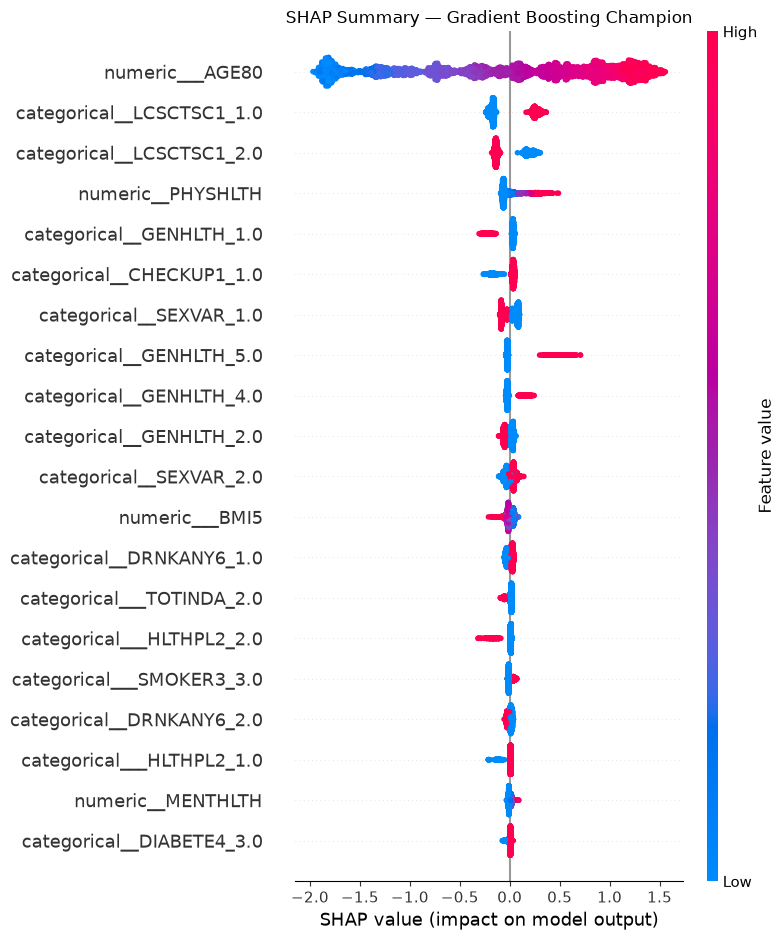

In [ ]:
import matplotlib.pyplot as plt

# SHAP beeswarm plot
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=shap_feature_names,
    show=False
)

plt.title("SHAP Summary — Gradient Boosting Champion")
plt.tight_layout()
plt.show()

## M7.8 — Aggregated CuraMind Feature SHAP Summary

Aggregate the 38 transformed SHAP features back into the original
16 CuraMind features.

For each original feature:
- Mean absolute SHAP measures overall importance.
- Mean SHAP indicates the average direction of contribution.
- Positive mean SHAP indicates an overall upward contribution.
- Negative mean SHAP indicates an overall downward contribution.

The aggregated results will provide an interpretable feature-level
explanation suitable for the CuraMind architecture.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame containing the SHAP values
shap_values_df = pd.DataFrame(
    shap_array,
    columns=shap_feature_names
)

# Define the original CuraMind features
original_features = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1",
    "GENHLTH",
    "PHYSHLTH",
    "_HLTHPL2",
    "MEDCOST1",
    "CHECKUP1"
]

# Build transformed-feature groups for each original feature
feature_groups = {}

for feature in original_features:

    # Numeric features
    if feature in ["_AGE80", "_BMI5", "MENTHLTH", "PHYSHLTH"]:

        # SHAP names remove the leading underscore for _AGE80/_BMI5
        clean_name = feature.lstrip("_")

        matching_columns = [
            col for col in shap_feature_names
            if col in [
                f"numeric___{clean_name}",
                f"numeric__{clean_name}"
            ]
        ]

    # Categorical features
    else:

        matching_columns = [
            col for col in shap_feature_names
            if (
                col.startswith(f"categorical__{feature}_")
                or col.startswith(f"categorical___{feature}_")
            )
        ]

    feature_groups[feature] = matching_columns

# Aggregate SHAP values row-by-row
aggregated_shap_values = pd.DataFrame(index=shap_values_df.index)

for feature, columns in feature_groups.items():

    if len(columns) == 0:
        print(f"WARNING: No SHAP columns found for {feature}")
    else:
        aggregated_shap_values[feature] = (
            shap_values_df[columns].sum(axis=1)
        )

# Calculate global importance and direction
aggregated_shap_results = pd.DataFrame({
    "feature": aggregated_shap_values.columns,
    "mean_abs_shap": aggregated_shap_values.abs().mean().values,
    "mean_shap": aggregated_shap_values.mean().values
})

# Calculate percentage of total SHAP importance
total_importance = aggregated_shap_results["mean_abs_shap"].sum()

aggregated_shap_results["importance_percent"] = (
    aggregated_shap_results["mean_abs_shap"]
    / total_importance
    * 100
)

# Sort by importance
aggregated_shap_results = (
    aggregated_shap_results
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("=" * 80)
print("M7.8 — AGGREGATED CURAMIND FEATURE SHAP SUMMARY")
print("=" * 80)

print(
    aggregated_shap_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

M7.8 — AGGREGATED CURAMIND FEATURE SHAP SUMMARY
 feature  mean_abs_shap  mean_shap  importance_percent
  _AGE80       0.913035  -0.011486           49.211123
LCSCTSC1       0.375940  -0.009290           20.262580
 GENHLTH       0.121335  -0.001902            6.539749
  SEXVAR       0.089013   0.004503            4.797647
PHYSHLTH       0.082051   0.003886            4.422419
CHECKUP1       0.066435  -0.000867            3.580720
DRNKANY6       0.040950  -0.001631            2.207127
_TOTINDA       0.033897  -0.002110            1.826977
_HLTHPL2       0.033733   0.002040            1.818160
   _BMI5       0.027458   0.001730            1.479967
_SMOKER3       0.022582   0.000776            1.217149
MENTHLTH       0.013286   0.000529            0.716093
CHCCOPD3       0.012776   0.002965            0.688604
  _MICHD       0.010379   0.006079            0.559387
DIABETE4       0.009223   0.004355            0.497114
MEDCOST1       0.003250   0.000525            0.175182


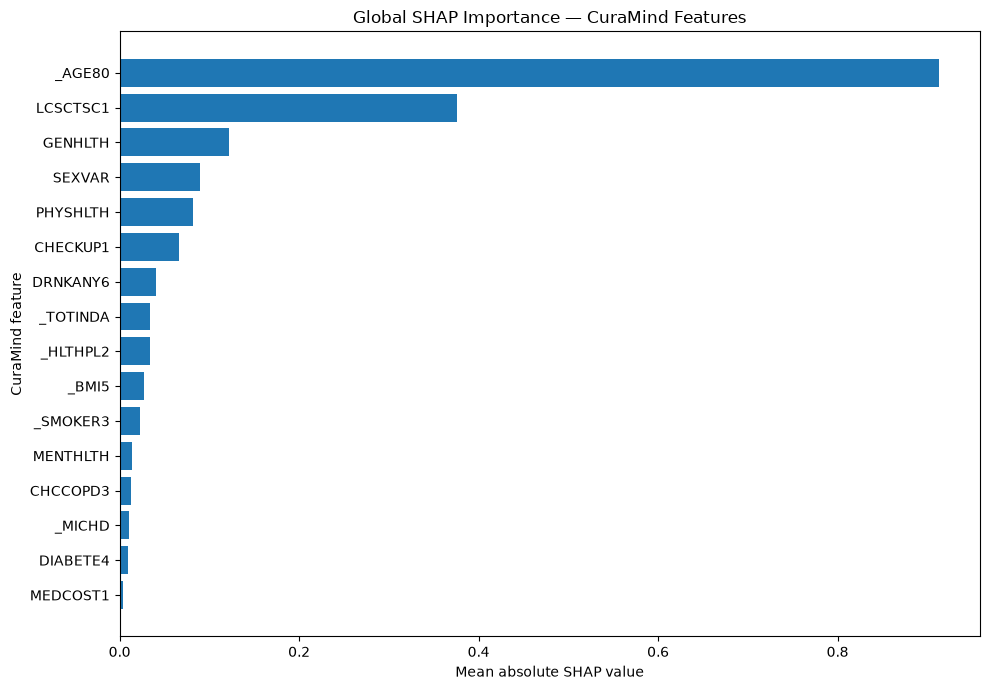

In [ ]:
# Plot global SHAP importance for the original 16 CuraMind features

plot_df = aggregated_shap_results.sort_values(
    "mean_abs_shap",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["feature"],
    plot_df["mean_abs_shap"]
)

plt.xlabel("Mean absolute SHAP value")
plt.ylabel("CuraMind feature")
plt.title("Global SHAP Importance — CuraMind Features")

plt.tight_layout()
plt.show()

## M7.9 — Individual Prediction Explanation

Select one representative test observation and examine its SHAP
contributions.

The explanation shows which original CuraMind features pushed the model's
prediction toward the positive or negative BRFSS cancer-history target.

Positive SHAP contribution:
    pushes the prediction higher

Negative SHAP contribution:
    pushes the prediction lower

This demonstrates how SHAP can eventually support individual-level
explanations in the CuraMind dashboard.

In [ ]:
# Select one representative observation from the SHAP sample
patient_index = 0

patient_shap = aggregated_shap_values.iloc[patient_index]

patient_explanation = pd.DataFrame({
    "feature": patient_shap.index,
    "shap_value": patient_shap.values,
    "absolute_shap": np.abs(patient_shap.values)
})

patient_explanation = (
    patient_explanation
    .sort_values("absolute_shap", ascending=False)
    .reset_index(drop=True)
)

print("=" * 70)
print("M7.9 — INDIVIDUAL PREDICTION SHAP EXPLANATION")
print("=" * 70)

print(
    patient_explanation.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

M7.9 — INDIVIDUAL PREDICTION SHAP EXPLANATION
 feature  shap_value  absolute_shap
  _AGE80    1.061016       1.061016
LCSCTSC1    0.401880       0.401880
  SEXVAR   -0.045295       0.045295
   _BMI5    0.044957       0.044957
CHECKUP1    0.043950       0.043950
_SMOKER3    0.035604       0.035604
DRNKANY6    0.034973       0.034973
_HLTHPL2    0.025954       0.025954
_TOTINDA    0.022553       0.022553
 GENHLTH    0.021402       0.021402
DIABETE4    0.010276       0.010276
MENTHLTH   -0.005017       0.005017
CHCCOPD3   -0.002185       0.002185
MEDCOST1    0.001996       0.001996
  _MICHD    0.001513       0.001513
PHYSHLTH   -0.000912       0.000912


## M7.10 — Connect SHAP Explanation to Model Probability

Connect the individual SHAP contributions to the model's actual
prediction.

The SHAP base value represents the model's expected output before the
individual feature contributions are considered.

The SHAP contributions plus the base value reconstruct the model's
underlying output.

The underlying output is then converted to the model's predicted
probability.

This provides a complete mathematical link between:
    baseline → feature contributions → model prediction

In [ ]:
from scipy.special import expit

# Actual test-set index corresponding to our SHAP sample observation
actual_test_index = shap_sample_indices[patient_index]

# Model probability for this observation
patient_probability = champion_probabilities[actual_test_index]

# SHAP base value
base_value = np.asarray(shap_explainer.expected_value).item()

# SHAP values for this observation
patient_shap_sum = shap_array[patient_index].sum()

# Reconstructed raw model output
reconstructed_raw_output = base_value + patient_shap_sum

# Convert raw output to probability
reconstructed_probability = expit(reconstructed_raw_output)

print("=" * 70)
print("M7.10 — SHAP → MODEL PROBABILITY")
print("=" * 70)

print(f"SHAP base value:              {base_value:.6f}")
print(f"Sum of SHAP contributions:    {patient_shap_sum:.6f}")
print(f"Reconstructed raw output:     {reconstructed_raw_output:.6f}")
print(f"Model probability:             {patient_probability:.6f}")
print(f"SHAP reconstructed probability:{reconstructed_probability:.6f}")
print(f"Difference:                    "
      f"{abs(patient_probability - reconstructed_probability):.10f}")

M7.10 — SHAP → MODEL PROBABILITY
SHAP base value:              -2.533900
Sum of SHAP contributions:    1.652665
Reconstructed raw output:     -0.881235
Model probability:             0.292922
SHAP reconstructed probability:0.292922
Difference:                    0.0000000000


## M7.11 — Individual CuraMind SHAP Explanation

Create a presentation-ready explanation for the selected test observation.

Features are displayed according to their SHAP contribution:
- Positive values push the model toward the positive target.
- Negative values push the model toward the negative target.

The visualization is intended to demonstrate how CuraMind can provide
an interpretable explanation alongside an individual model prediction.

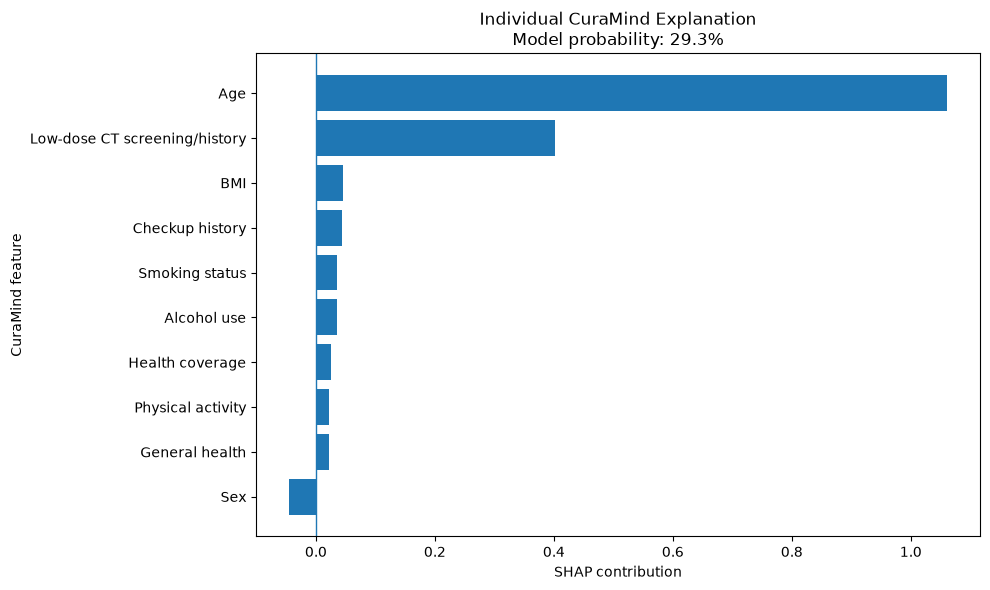

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use the individual explanation created in M7.9
plot_explanation = patient_explanation.copy()

# Keep the 10 strongest contributors
plot_explanation = (
    plot_explanation
    .sort_values("absolute_shap", ascending=False)
    .head(10)
    .sort_values("shap_value")
)

# Create labels for presentation
feature_labels = {
    "_AGE80": "Age",
    "LCSCTSC1": "Low-dose CT screening/history",
    "SEXVAR": "Sex",
    "_BMI5": "BMI",
    "CHECKUP1": "Checkup history",
    "_SMOKER3": "Smoking status",
    "DRNKANY6": "Alcohol use",
    "_HLTHPL2": "Health coverage",
    "_TOTINDA": "Physical activity",
    "GENHLTH": "General health",
    "DIABETE4": "Diabetes",
    "MENTHLTH": "Mental health",
    "CHCCOPD3": "COPD",
    "MEDCOST1": "Medical cost access",
    "_MICHD": "Heart disease",
    "PHYSHLTH": "Physical health"
}

plot_explanation["label"] = (
    plot_explanation["feature"]
    .map(feature_labels)
    .fillna(plot_explanation["feature"])
)

# Create horizontal contribution plot
plt.figure(figsize=(10, 6))

plt.barh(
    plot_explanation["label"],
    plot_explanation["shap_value"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("SHAP contribution")
plt.ylabel("CuraMind feature")

plt.title(
    f"Individual CuraMind Explanation\n"
    f"Model probability: {patient_probability:.1%}"
)

plt.tight_layout()
plt.show()

## M8.1 — Create V1 Model Configuration

Create a configuration object containing the feature definitions,
preprocessing structure, target definition, model identity, evaluation
metrics, and current operating threshold.

This configuration documents the exact assumptions used by the V1 model
and will accompany the exported model artifacts.

In [ ]:
import json

# V1 CuraMind model configuration
curamind_model_config = {
    "model_name": "CuraMind_V1_GradientBoosting",
    "model_type": "GradientBoostingClassifier",
    "model_status": "champion",

    "dataset": "BRFSS 2024",

    "target": {
        "name": "target",
        "definition": (
            "BRFSS cancer-history proxy derived from CHCOCNC1"
        ),
        "future_cancer_prediction": False
    },

    "features": selected_features,

    "numeric_features": numeric_features,

    "categorical_features": categorical_features,

    "preprocessed_feature_count": len(
        preprocessor.get_feature_names_out()
    ),

    "original_feature_count": len(selected_features),

    "model_parameters": {
        "n_estimators": 100,
        "learning_rate": 0.1,
        "max_depth": 3,
        "random_state": 42
    },

    "evaluation": {
        "test_roc_auc": round(float(gb_auc), 4),
        "threshold": 0.20,
        "threshold_precision": round(float(final_precision), 4),
        "threshold_recall": round(float(final_recall), 4),
        "threshold_f1": round(float(final_f1), 4),
        "brier_score": round(float(champion_brier), 6)
    },

    "explainability": {
        "method": "SHAP",
        "explainer": "TreeExplainer"
    }
}

print("=" * 70)
print("M8.1 — CURAMIND V1 MODEL CONFIGURATION")
print("=" * 70)

print(json.dumps(curamind_model_config, indent=2))

M8.1 — CURAMIND V1 MODEL CONFIGURATION
{
  "model_name": "CuraMind_V1_GradientBoosting",
  "model_type": "GradientBoostingClassifier",
  "model_status": "champion",
  "dataset": "BRFSS 2024",
  "target": {
    "name": "target",
    "definition": "BRFSS cancer-history proxy derived from CHCOCNC1",
    "future_cancer_prediction": false
  },
  "features": [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1",
    "GENHLTH",
    "PHYSHLTH",
    "_HLTHPL2",
    "MEDCOST1",
    "CHECKUP1"
  ],
  "numeric_features": [
    "_AGE80",
    "_BMI5",
    "MENTHLTH",
    "PHYSHLTH"
  ],
  "categorical_features": [
    "SEXVAR",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1",
    "GENHLTH",
    "_HLTHPL2",
    "MEDCOST1",
    "CHECKUP1"
  ],
  "preprocessed_feature_count": 38,
  "original_feature_count": 16,
  "model_parameters

## M8.2 — Export V1 Model Artifacts

Export the trained CuraMind V1 Gradient Boosting champion and the fitted
M4 preprocessing pipeline.

The preprocessor must be saved together with the model because the model
expects the same 38-feature representation used during training.

Also export the V1 model configuration as JSON.

In [ ]:
import joblib
import json
import os

# Create export directory
export_dir = "curamind_v1"
os.makedirs(export_dir, exist_ok=True)

# Export the official champion model
model_path = os.path.join(
    export_dir,
    "curamind_v1_model.joblib"
)

joblib.dump(
    gb_model,
    model_path
)

# Export the fitted preprocessing pipeline
preprocessor_path = os.path.join(
    export_dir,
    "curamind_v1_preprocessor.joblib"
)

joblib.dump(
    preprocessor,
    preprocessor_path
)

# Export model configuration
config_path = os.path.join(
    export_dir,
    "curamind_v1_config.json"
)

with open(config_path, "w") as f:
    json.dump(
        curamind_model_config,
        f,
        indent=2
    )

print("=" * 70)
print("M8.2 — MODEL ARTIFACTS EXPORTED")
print("=" * 70)

print(f"Model:        {model_path}")
print(f"Preprocessor: {preprocessor_path}")
print(f"Config:       {config_path}")

M8.2 — MODEL ARTIFACTS EXPORTED
Model:        curamind_v1/curamind_v1_model.joblib
Preprocessor: curamind_v1/curamind_v1_preprocessor.joblib
Config:       curamind_v1/curamind_v1_config.json


## M8.3 — Reload and Verify Exported Artifacts

Reload the exported model and preprocessing pipeline from disk.

Verify that the exported Gradient Boosting model produces the same
probability as the original in-memory champion model for a test
observation.

This confirms that the exported artifacts can reproduce the trained
model's predictions.

In [ ]:
import joblib
import numpy as np

# Reload exported artifacts
loaded_model = joblib.load(model_path)
loaded_preprocessor = joblib.load(preprocessor_path)

print("=" * 70)
print("M8.3 — RELOADED ARTIFACTS")
print("=" * 70)

print("Loaded model:", type(loaded_model).__name__)
print("Loaded preprocessor:", type(loaded_preprocessor).__name__)

# Select one test observation
test_row = X_test.iloc[[0]]

# Original model prediction
original_transformed = preprocessor.transform(test_row)
original_probability = gb_model.predict_proba(
    original_transformed
)[0, 1]

# Reloaded model prediction
loaded_transformed = loaded_preprocessor.transform(test_row)
loaded_probability = loaded_model.predict_proba(
    loaded_transformed
)[0, 1]

print("\nPrediction verification:")
print(f"Original model probability: {original_probability:.10f}")
print(f"Reloaded model probability: {loaded_probability:.10f}")
print(
    f"Difference: "
    f"{abs(original_probability - loaded_probability):.10f}"
)

if np.isclose(original_probability, loaded_probability):
    print("\n✅ Export verification PASSED")
else:
    print("\n❌ Export verification FAILED")

M8.3 — RELOADED ARTIFACTS
Loaded model: GradientBoostingClassifier
Loaded preprocessor: ColumnTransformer

Prediction verification:
Original model probability: 0.2642474066
Reloaded model probability: 0.2642474066
Difference: 0.0000000000

✅ Export verification PASSED


## M8.4 — Final Artifact Inventory

Verify that all exported CuraMind V1 artifacts exist and record their
file sizes.

Required artifacts:
- Trained Gradient Boosting model
- Fitted preprocessing pipeline
- Model configuration

In [ ]:
import os

artifact_files = [
    model_path,
    preprocessor_path,
    config_path
]

print("=" * 70)
print("M8.4 — CURAMIND V1 ARTIFACT INVENTORY")
print("=" * 70)

all_exist = True

for path in artifact_files:

    exists = os.path.exists(path)

    if exists:
        size_mb = os.path.getsize(path) / (1024 * 1024)

        print(f"✅ {path}")
        print(f"   Size: {size_mb:.2f} MB")
    else:
        print(f"❌ MISSING: {path}")
        all_exist = False

print("\n" + "=" * 70)

if all_exist:
    print("✅ All CuraMind V1 artifacts are present.")
else:
    print("❌ One or more artifacts are missing.")

M8.4 — CURAMIND V1 ARTIFACT INVENTORY
✅ curamind_v1/curamind_v1_model.joblib
   Size: 0.14 MB
✅ curamind_v1/curamind_v1_preprocessor.joblib
   Size: 0.00 MB
✅ curamind_v1/curamind_v1_config.json
   Size: 0.00 MB

✅ All CuraMind V1 artifacts are present.


## M9.1 — CuraMind Frontend → V1 ML Feature Mapping

The CuraMind assessment is the master long-term input architecture.

Each assessment field is classified according to whether it is:

🟢 V1 ML input
🟡 Frontend-only for V1
🔵 Future ML feature
🔴 Excluded

The V1 model uses only features supported by the BRFSS 2024 training
dataset and validated during M3.

In [ ]:
# M9.1 — CuraMind Frontend → V1 ML Feature Mapping

curamind_feature_mapping = {

    # -------------------------
    # PERSONAL INFORMATION
    # -------------------------

    "age": {
        "v1_feature": "_AGE80",
        "status": "V1 ML",
        "source": "personal_information.age"
    },

    "gender": {
        "v1_feature": "SEXVAR",
        "status": "V1 ML",
        "source": "personal_information.gender"
    },

    "height_cm": {
        "v1_feature": None,
        "status": "Frontend-only",
        "source": "personal_information.height_cm"
    },

    "weight_kg": {
        "v1_feature": "_BMI5",
        "status": "V1 ML",
        "source": "personal_information.weight_kg + height_cm"
    },

    "full_name": {
        "v1_feature": None,
        "status": "Frontend-only",
        "source": "personal_information.full_name"
    },

    "date_of_birth": {
        "v1_feature": None,
        "status": "Frontend-only",
        "source": "personal_information.date_of_birth"
    },

    "email": {
        "v1_feature": None,
        "status": "Frontend-only",
        "source": "personal_information.email"
    },

    "occupation": {
        "v1_feature": None,
        "status": "Future ML feature",
        "source": "personal_information.occupation"
    },

    # -------------------------
    # LIFESTYLE
    # -------------------------

    "smoking": {
        "v1_feature": "_SMOKER3",
        "status": "V1 ML",
        "source": "lifestyle.smoking.status"
    },

    "alcohol": {
        "v1_feature": "DRNKANY6",
        "status": "V1 ML",
        "source": "lifestyle.alcohol.status"
    },

    "physical_activity": {
        "v1_feature": "_TOTINDA",
        "status": "V1 ML",
        "source": "lifestyle.physical_activity"
    },

    "stress_level": {
        "v1_feature": None,
        "status": "Future ML feature",
        "source": "lifestyle.stress_level"
    },

    "diet": {
        "v1_feature": None,
        "status": "Future ML feature",
        "source": "lifestyle.diet"
    },

    "sleep_hours": {
        "v1_feature": None,
        "status": "Future ML feature",
        "source": "lifestyle.sleep_hours"
    },

    "tobacco": {
        "v1_feature": None,
        "status": "Future ML feature",
        "source": "lifestyle.tobacco"
    },

    # -------------------------
    # MEDICAL HISTORY
    # -------------------------

    "diabetes": {
        "v1_feature": "DIABETE4",
        "status": "V1 ML",
        "source": "medical_history.diabetes"
    },

    "heart_disease": {
        "v1_feature": "_MICHD",
        "status": "V1 ML",
        "source": "medical_history.heart_disease"
    },

    "copd": {
        "v1_feature": "CHCCOPD3",
        "status": "V1 ML",
        "source": "medical_history.copd"
    },

    "hypertension": {
        "v1_feature": None,
        "status": "Future ML feature",
        "source": "medical_history.hypertension"
    },

    "previous_cancer": {
        "v1_feature": None,
        "status": "Excluded",
        "source": "medical_history.previous_cancer"
    },

    "medications": {
        "v1_feature": None,
        "status": "Frontend-only",
        "source": "medical_history.medications"
    },

    "surgeries": {
        "v1_feature": None,
        "status": "Frontend-only",
        "source": "medical_history.surgeries"
    },

    "allergies": {
        "v1_feature": None,
        "status": "Frontend-only",
        "source": "medical_history.allergies"
    },

    "clinician_notes": {
        "v1_feature": None,
        "status": "Frontend-only",
        "source": "medical_history.clinician_notes"
    },

    # -------------------------
    # FAMILY HISTORY
    # -------------------------

    "family_cancer_history": {
        "v1_feature": None,
        "status": "Future ML feature",
        "source": "family_history"
    },

    # -------------------------
    # SYMPTOMS
    # -------------------------

    "symptoms": {
        "v1_feature": None,
        "status": "Future ML feature",
        "source": "symptoms"
    },

    # -------------------------
    # ENVIRONMENT
    # -------------------------

    "chemical_exposure": {
        "v1_feature": None,
        "status": "Future ML feature",
        "source": "additional_information.chemical_exposure"
    },

    "radiation_exposure": {
        "v1_feature": None,
        "status": "Future ML feature",
        "source": "additional_information.radiation_exposure"
    },

    "air_pollution_exposure": {
        "v1_feature": None,
        "status": "Future ML feature",
        "source": "additional_information.air_pollution_exposure"
    }
}

print("=" * 80)
print("M9.1 — CURAMIND FRONTEND → V1 ML FEATURE MAPPING")
print("=" * 80)

for field, mapping in curamind_feature_mapping.items():
    print(
        f"{field:30s} → "
        f"{str(mapping['v1_feature']):15s} | "
        f"{mapping['status']}"
    )

M9.1 — CURAMIND FRONTEND → V1 ML FEATURE MAPPING
age                            → _AGE80          | V1 ML
gender                         → SEXVAR          | V1 ML
height_cm                      → None            | Frontend-only
weight_kg                      → _BMI5           | V1 ML
full_name                      → None            | Frontend-only
date_of_birth                  → None            | Frontend-only
email                          → None            | Frontend-only
occupation                     → None            | Future ML feature
smoking                        → _SMOKER3        | V1 ML
alcohol                        → DRNKANY6        | V1 ML
physical_activity              → _TOTINDA        | V1 ML
stress_level                   → None            | Future ML feature
diet                           → None            | Future ML feature
sleep_hours                    → None            | Future ML feature
tobacco                        → None            | Future ML feature
diab

## M9.2 — V1 Feature Transformation Contract

Define the exact transformation required to convert CuraMind frontend
responses into the 16 inputs expected by the trained V1 model.

Frontend values must never be passed directly to the model when their
representation differs from the BRFSS training representation.

The transformation layer must preserve the preprocessing assumptions
established during M4.

In [ ]:
curamind_v1_transformations = {

    "_AGE80": {
        "frontend_source": "personal_information.age",
        "transformation": "Use age as numeric value",
        "type": "numeric"
    },

    "SEXVAR": {
        "frontend_source": "personal_information.gender",
        "transformation": "Map supported gender values to BRFSS-compatible categories",
        "type": "categorical"
    },

    "_BMI5": {
        "frontend_source": [
            "personal_information.height_cm",
            "personal_information.weight_kg"
        ],
        "transformation": "Calculate BMI from height and weight, then convert to model representation",
        "type": "numeric"
    },

    "_SMOKER3": {
        "frontend_source": "lifestyle.smoking.status",
        "transformation": "Map CuraMind smoking category to BRFSS _SMOKER3 category",
        "type": "categorical"
    },

    "DRNKANY6": {
        "frontend_source": "lifestyle.alcohol.status",
        "transformation": "none → no alcohol; moderate/heavy → alcohol use",
        "type": "categorical"
    },

    "_TOTINDA": {
        "frontend_source": "lifestyle.physical_activity",
        "transformation": "Map CuraMind activity frequency to BRFSS active/inactive category",
        "type": "categorical"
    },

    "MENTHLTH": {
        "frontend_source": None,
        "transformation": "Not populated from current stress_level question",
        "type": "numeric",
        "status": "Future frontend integration"
    },

    "DIABETE4": {
        "frontend_source": "medical_history.diabetes",
        "transformation": "Map diabetes response to BRFSS-compatible category",
        "type": "categorical"
    },

    "_MICHD": {
        "frontend_source": "medical_history.heart_disease",
        "transformation": "Map heart disease response to BRFSS-compatible category",
        "type": "categorical"
    },

    "CHCCOPD3": {
        "frontend_source": "medical_history.copd",
        "transformation": "Map COPD response to BRFSS-compatible category",
        "type": "categorical"
    },

    "LCSCTSC1": {
        "frontend_source": None,
        "transformation": "No direct current CuraMind assessment input",
        "type": "categorical",
        "status": "Requires future data-source integration"
    },

    "GENHLTH": {
        "frontend_source": None,
        "transformation": "No direct current CuraMind assessment input",
        "type": "categorical",
        "status": "Requires future frontend integration"
    },

    "PHYSHLTH": {
        "frontend_source": None,
        "transformation": "No direct current CuraMind assessment input",
        "type": "numeric",
        "status": "Requires future frontend integration"
    },

    "_HLTHPL2": {
        "frontend_source": None,
        "transformation": "No direct current CuraMind assessment input",
        "type": "categorical",
        "status": "Requires future frontend integration"
    },

    "MEDCOST1": {
        "frontend_source": None,
        "transformation": "No direct current CuraMind assessment input",
        "type": "categorical",
        "status": "Requires future frontend integration"
    },

    "CHECKUP1": {
        "frontend_source": None,
        "transformation": "No direct current CuraMind assessment input",
        "type": "categorical",
        "status": "Requires future frontend integration"
    }
}

print("=" * 80)
print("M9.2 — V1 FEATURE TRANSFORMATION CONTRACT")
print("=" * 80)

for feature, details in curamind_v1_transformations.items():

    print(f"\n{feature}")
    print(f"  Frontend source: {details['frontend_source']}")
    print(f"  Transformation:  {details['transformation']}")
    print(f"  Type:            {details['type']}")

    if "status" in details:
        print(f"  Status:           {details['status']}")

M9.2 — V1 FEATURE TRANSFORMATION CONTRACT

_AGE80
  Frontend source: personal_information.age
  Transformation:  Use age as numeric value
  Type:            numeric

SEXVAR
  Frontend source: personal_information.gender
  Transformation:  Map supported gender values to BRFSS-compatible categories
  Type:            categorical

_BMI5
  Frontend source: ['personal_information.height_cm', 'personal_information.weight_kg']
  Transformation:  Calculate BMI from height and weight, then convert to model representation
  Type:            numeric

_SMOKER3
  Frontend source: lifestyle.smoking.status
  Transformation:  Map CuraMind smoking category to BRFSS _SMOKER3 category
  Type:            categorical

DRNKANY6
  Frontend source: lifestyle.alcohol.status
  Transformation:  none → no alcohol; moderate/heavy → alcohol use
  Type:            categorical

_TOTINDA
  Frontend source: lifestyle.physical_activity
  Transformation:  Map CuraMind activity frequency to BRFSS active/inactive category


## M9.3 — Exact BRFSS ↔ CuraMind Input Mapping

This section defines how each CuraMind assessment input will map to the
16 features required by the CuraMind V1 Gradient Boosting model.

The trained model requirements take priority over the current frontend design.
Frontend changes identified here will be implemented later, after ML model
training and integration specifications are complete.

For every model feature we define:
- CuraMind input required
- BRFSS representation
- Backend transformation
- Missing-value handling
- Frontend change required

The frontend will be updated after completion of the ML training and M9
integration specification.

In [ ]:
curamind_v1_input_requirements = {
    "_AGE80": {
        "curamind_input": "age",
        "status": "direct",
        "frontend_change": False
    },

    "SEXVAR": {
        "curamind_input": "sex",
        "status": "mapped",
        "frontend_change": True
    },

    "_BMI5": {
        "curamind_input": "height_cm + weight_kg",
        "status": "calculated",
        "frontend_change": False
    },

    "_SMOKER3": {
        "curamind_input": "smoking.status",
        "status": "mapped",
        "frontend_change": True
    },

    "DRNKANY6": {
        "curamind_input": "alcohol.status",
        "status": "mapped",
        "frontend_change": True
    },

    "_TOTINDA": {
        "curamind_input": "physical_activity",
        "status": "mapped",
        "frontend_change": True
    },

    "MENTHLTH": {
        "curamind_input": "mental_health_days",
        "status": "new_input_required",
        "frontend_change": True
    },

    "DIABETE4": {
        "curamind_input": "diabetes_status",
        "status": "mapped",
        "frontend_change": True
    },

    "_MICHD": {
        "curamind_input": "heart_disease_history",
        "status": "mapped",
        "frontend_change": True
    },

    "CHCCOPD3": {
        "curamind_input": "copd_history",
        "status": "mapped",
        "frontend_change": True
    },

    "LCSCTSC1": {
        "curamind_input": "lung_ct_screening_history",
        "status": "new_input_required",
        "frontend_change": True
    },

    "GENHLTH": {
        "curamind_input": "general_health",
        "status": "new_input_required",
        "frontend_change": True
    },

    "PHYSHLTH": {
        "curamind_input": "physical_health_days",
        "status": "new_input_required",
        "frontend_change": True
    },

    "_HLTHPL2": {
        "curamind_input": "healthcare_coverage",
        "status": "new_input_required",
        "frontend_change": True
    },

    "MEDCOST1": {
        "curamind_input": "could_not_afford_doctor",
        "status": "new_input_required",
        "frontend_change": True
    },

    "CHECKUP1": {
        "curamind_input": "last_routine_checkup",
        "status": "new_input_required",
        "frontend_change": True
    }
}

print(f"Total V1 model features: {len(curamind_v1_input_requirements)}")
print(
    "Frontend changes required:",
    sum(
        item["frontend_change"]
        for item in curamind_v1_input_requirements.values()
    )
)

Total V1 model features: 16
Frontend changes required: 14


In [ ]:
for feature, details in curamind_v1_input_requirements.items():
    print(
        f"{feature:12} | "
        f"{details['status']:20} | "
        f"Frontend change: {details['frontend_change']}"
    )

_AGE80       | direct               | Frontend change: False
SEXVAR       | mapped               | Frontend change: True
_BMI5        | calculated           | Frontend change: False
_SMOKER3     | mapped               | Frontend change: True
DRNKANY6     | mapped               | Frontend change: True
_TOTINDA     | mapped               | Frontend change: True
MENTHLTH     | new_input_required   | Frontend change: True
DIABETE4     | mapped               | Frontend change: True
_MICHD       | mapped               | Frontend change: True
CHCCOPD3     | mapped               | Frontend change: True
LCSCTSC1     | new_input_required   | Frontend change: True
GENHLTH      | new_input_required   | Frontend change: True
PHYSHLTH     | new_input_required   | Frontend change: True
_HLTHPL2     | new_input_required   | Frontend change: True
MEDCOST1     | new_input_required   | Frontend change: True
CHECKUP1     | new_input_required   | Frontend change: True


In [ ]:
for feature in selected_features:
    print(f"\n{'=' * 60}")
    print(feature)
    print(preprocess_df[feature].value_counts(dropna=False).sort_index())


_AGE80
_AGE80
18.0     3710
19.0     3923
20.0     4080
21.0     4217
22.0     4107
        ...  
76.0     7912
77.0     8082
78.0     6229
79.0     5280
80.0    40102
Name: count, Length: 63, dtype: int64

SEXVAR
SEXVAR
1.0    212461
2.0    234825
Name: count, dtype: int64

_BMI5
_BMI5
1200.0        1
1205.0        1
1208.0        1
1211.0        5
1213.0        1
          ...  
9765.0        1
9844.0        1
9979.0        1
9984.0        1
NaN       41229
Name: count, Length: 4171, dtype: int64

_SMOKER3
_SMOKER3
1.0     32092
2.0     13588
3.0    116931
4.0    253875
NaN     30800
Name: count, dtype: int64

DRNKANY6
DRNKANY6
1.0    207356
2.0    197851
NaN     42079
Name: count, dtype: int64

_TOTINDA
_TOTINDA
1.0    343337
2.0    102888
NaN      1061
Name: count, dtype: int64

MENTHLTH
MENTHLTH
0.0     268655
1.0      15335
2.0      25078
3.0      15903
4.0       8350
5.0      21292
6.0       2361
7.0       8250
8.0       1866
9.0        331
10.0     16391
11.0       144
12.0   

### M9.3 Feature-to-Input Specification

The following table defines the user inputs required to reproduce the
16 features used by the CuraMind V1 Gradient Boosting model.

The specification is based on the actual cleaned BRFSS 2024 values used
during model training.

Frontend changes will be implemented only after the ML training and
integration specification are complete.

In [ ]:
m93_feature_spec = [
    ["_AGE80", "Age", "Direct age input", "Existing"],
    ["SEXVAR", "Sex", "Male/Female mapping", "Modify"],
    ["_BMI5", "Height + Weight", "Calculate BMI and encode as BRFSS _BMI5", "Existing"],
    ["_SMOKER3", "Smoking status", "Map smoking category", "Modify"],
    ["DRNKANY6", "Alcohol use", "Map to yes/no", "Modify"],
    ["_TOTINDA", "Physical activity", "Map to active/inactive", "Modify"],
    ["MENTHLTH", "Poor mental-health days", "0–30 days", "Add"],
    ["DIABETE4", "Diabetes status", "Map four BRFSS categories", "Modify"],
    ["_MICHD", "Heart disease/heart attack history", "Map to yes/no", "Modify"],
    ["CHCCOPD3", "COPD history", "Map to yes/no", "Modify"],
    ["LCSCTSC1", "Low-dose CT screening history", "Map to yes/no", "Add"],
    ["GENHLTH", "General health", "5-level health rating", "Add"],
    ["PHYSHLTH", "Poor physical-health days", "0–30 days", "Add"],
    ["_HLTHPL2", "Health-care coverage", "Map to yes/no", "Add"],
    ["MEDCOST1", "Unable to afford doctor", "Map to yes/no", "Add"],
    ["CHECKUP1", "Last routine checkup", "5-level time category", "Add"],
]

m93_feature_spec

[['_AGE80', 'Age', 'Direct age input', 'Existing'],
 ['SEXVAR', 'Sex', 'Male/Female mapping', 'Modify'],
 ['_BMI5',
  'Height + Weight',
  'Calculate BMI and encode as BRFSS _BMI5',
  'Existing'],
 ['_SMOKER3', 'Smoking status', 'Map smoking category', 'Modify'],
 ['DRNKANY6', 'Alcohol use', 'Map to yes/no', 'Modify'],
 ['_TOTINDA', 'Physical activity', 'Map to active/inactive', 'Modify'],
 ['MENTHLTH', 'Poor mental-health days', '0–30 days', 'Add'],
 ['DIABETE4', 'Diabetes status', 'Map four BRFSS categories', 'Modify'],
 ['_MICHD', 'Heart disease/heart attack history', 'Map to yes/no', 'Modify'],
 ['CHCCOPD3', 'COPD history', 'Map to yes/no', 'Modify'],
 ['LCSCTSC1', 'Low-dose CT screening history', 'Map to yes/no', 'Add'],
 ['GENHLTH', 'General health', '5-level health rating', 'Add'],
 ['PHYSHLTH', 'Poor physical-health days', '0–30 days', 'Add'],
 ['_HLTHPL2', 'Health-care coverage', 'Map to yes/no', 'Add'],
 ['MEDCOST1', 'Unable to afford doctor', 'Map to yes/no', 'Add'],
 ['CHEC

## M9.4 — CuraMind V1 Input Transformation Contract

This section defines how the values collected by the CuraMind frontend
will be transformed into the exact feature representations expected by
the trained CuraMind V1 preprocessing pipeline and Gradient Boosting model.

The transformation layer is responsible for:
- Converting frontend categories into BRFSS-compatible values
- Calculating derived features such as BMI
- Validating input ranges
- Representing unavailable or unanswered values as missing
- Preserving the feature names and structure expected by the trained model

No frontend changes are implemented in this section.

### M9.4.1 — Frontend Input → Model Feature Contract

The frontend will collect human-readable CuraMind values.
The backend transformation layer will convert these values into the
representations expected by the CuraMind V1 model.

The backend must produce exactly these 16 feature names:

_AGE80
SEXVAR
_BMI5
_SMOKER3
DRNKANY6
_TOTINDA
MENTHLTH
DIABETE4
_MICHD
CHCCOPD3
LCSCTSC1
GENHLTH
PHYSHLTH
_HLTHPL2
MEDCOST1
CHECKUP1

The transformation layer must not rename, reorder, or omit model features.

Missing or unanswered frontend inputs must be represented as missing
values rather than being replaced with arbitrary assumptions.

In [ ]:
model_feature_order = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1",
    "GENHLTH",
    "PHYSHLTH",
    "_HLTHPL2",
    "MEDCOST1",
    "CHECKUP1"
]

print("Number of model features:", len(model_feature_order))
print("\nModel feature order:")
for i, feature in enumerate(model_feature_order, start=1):
    print(f"{i:2}. {feature}")

Number of model features: 16

Model feature order:
 1. _AGE80
 2. SEXVAR
 3. _BMI5
 4. _SMOKER3
 5. DRNKANY6
 6. _TOTINDA
 7. MENTHLTH
 8. DIABETE4
 9. _MICHD
10. CHCCOPD3
11. LCSCTSC1
12. GENHLTH
13. PHYSHLTH
14. _HLTHPL2
15. MEDCOST1
16. CHECKUP1


### M9.4.2 — Exact Transformation Rules

The CuraMind frontend collects human-readable values.
The backend converts them into the representations expected by the
CuraMind V1 model.

Transformation rules:

1. _AGE80
   Source: personal_information.age
   Transformation: use age in years; values >= 80 map to 80.

2. SEXVAR
   Source: personal_information.gender/sex
   Transformation:
   - male -> 1
   - female -> 2
   - prefer-not -> missing

3. _BMI5
   Source: height_cm + weight_kg
   Transformation:
   - calculate BMI = weight_kg / height_m²
   - convert to the BRFSS _BMI5 representation
   - invalid/unavailable height or weight -> missing

4. _SMOKER3
   Source: lifestyle.smoking.status
   Transformation:
   - regular -> 1
   - occasional -> 2
   - former -> 3
   - never -> 4

5. DRNKANY6
   Source: lifestyle.alcohol.status
   Transformation:
   - none -> 2
   - moderate -> 1
   - heavy -> 1

6. _TOTINDA
   Source: lifestyle.physical_activity
   Transformation:
   - sedentary -> 2
   - light -> 1
   - regular -> 1
   - active -> 1

7. MENTHLTH
   Source: mental-health-days input
   Transformation: integer from 0–30.

8. DIABETE4
   Source: diabetes status
   Transformation: frontend options must represent the BRFSS categories
   required by the trained model.

9. _MICHD
   Source: heart disease / heart attack history
   Transformation:
   - yes -> 1
   - no -> 2

10. CHCCOPD3
    Source: COPD history
    Transformation:
    - yes -> 1
    - no -> 2

11. LCSCTSC1
    Source: low-dose CT screening history
    Transformation:
    - yes -> 1
    - no -> 2

12. GENHLTH
    Source: general health
    Transformation: map the five CuraMind health-rating options to
    BRFSS values 1–5.

13. PHYSHLTH
    Source: poor physical-health days
    Transformation: integer from 0–30.

14. _HLTHPL2
    Source: healthcare coverage
    Transformation:
    - covered -> 1
    - not covered -> 2

15. MEDCOST1
    Source: inability to afford doctor
    Transformation:
    - yes -> 1
    - no -> 2

16. CHECKUP1
    Source: last routine checkup
    Transformation: map frontend options to BRFSS values 1, 2, 3, 4,
    or 8.

### M9.4.3 — Verify BRFSS Encodings Before Transformation

Before implementing the frontend-to-model transformation functions, verify
the exact representations used by the trained CuraMind V1 model.

This step focuses on:
- _BMI5 representation
- DIABETE4 categories
- GENHLTH categories
- CHECKUP1 categories

The actual BRFSS dataset used for training is treated as the source of truth
for the values accepted by the model.

In [ ]:
features_to_verify = [
    "_BMI5",
    "DIABETE4",
    "GENHLTH",
    "CHECKUP1"
]

for feature in features_to_verify:
    print(f"\n{'=' * 60}")
    print(feature)
    print("Minimum:", preprocess_df[feature].min())
    print("Maximum:", preprocess_df[feature].max())
    print("Unique values:", preprocess_df[feature].nunique())

    if feature != "_BMI5":
        print("\nValue counts:")
        print(
            preprocess_df[feature]
            .value_counts(dropna=False)
            .sort_index()
        )


_BMI5
Minimum: 1200.0
Maximum: 9984.0
Unique values: 4170

DIABETE4
Minimum: 1.0
Maximum: 4.0
Unique values: 4

Value counts:
DIABETE4
1.0     63990
2.0      3327
3.0    368316
4.0     10914
NaN       739
Name: count, dtype: int64

GENHLTH
Minimum: 1.0
Maximum: 5.0
Unique values: 5

Value counts:
GENHLTH
1.0     63392
2.0    143659
3.0    152663
4.0     65420
5.0     21128
NaN      1024
Name: count, dtype: int64

CHECKUP1
Minimum: 1.0
Maximum: 8.0
Unique values: 5

Value counts:
CHECKUP1
1.0    361975
2.0     38855
3.0     21055
4.0     17934
8.0      2676
NaN      4791
Name: count, dtype: int64


### M9.4.4 — CuraMind V1 Patient Transformation Function

This function converts a CuraMind patient input dictionary into the
16 raw feature values expected by the CuraMind V1 preprocessing pipeline.

The function:
- accepts frontend-style human-readable values
- converts them to model-compatible values
- calculates BRFSS-style BMI
- validates bounded numeric inputs
- uses None for unavailable values
- preserves the exact V1 model feature names
- does not perform model prediction

This transformation layer will later sit between the CuraMind API
and the saved preprocessing/model artifacts.

In [ ]:
import math
import pandas as pd


# Exact 16 features expected by the CuraMind V1 model
model_feature_order = [
    "_AGE80",
    "SEXVAR",
    "_BMI5",
    "_SMOKER3",
    "DRNKANY6",
    "_TOTINDA",
    "MENTHLTH",
    "DIABETE4",
    "_MICHD",
    "CHCCOPD3",
    "LCSCTSC1",
    "GENHLTH",
    "PHYSHLTH",
    "_HLTHPL2",
    "MEDCOST1",
    "CHECKUP1"
]


def transform_curamind_patient(patient):
    """
    Convert CuraMind frontend input into the 16 raw features
    expected by the CuraMind V1 preprocessing pipeline.
    """

    personal = patient.get("personal_information", {})
    lifestyle = patient.get("lifestyle", {})
    smoking = lifestyle.get("smoking", {})
    alcohol = lifestyle.get("alcohol", {})
    medical = patient.get("medical_history", {})
    additional = patient.get("additional_information", {})

    # ---------------------------------------------------------
    # 1. AGE
    # ---------------------------------------------------------

    age = personal.get("age")

    if age is not None:
        age = float(age)
        age80 = min(age, 80)
    else:
        age80 = None

    # ---------------------------------------------------------
    # 2. SEX
    # ---------------------------------------------------------

    sex_mapping = {
        "male": 1,
        "female": 2,
        "prefer-not": None,
        "other": None
    }

    gender = personal.get("gender")
    sexvar = sex_mapping.get(gender)

    # ---------------------------------------------------------
    # 3. BMI
    # ---------------------------------------------------------

    height_cm = personal.get("height_cm")
    weight_kg = personal.get("weight_kg")

    bmi5 = None

    if height_cm is not None and weight_kg is not None:

        height_m = float(height_cm) / 100
        weight = float(weight_kg)

        if height_m > 0 and weight > 0:

            bmi = weight / (height_m ** 2)

            if 12 <= bmi < 100:
                bmi5 = round(bmi * 100, 0)

    # ---------------------------------------------------------
    # 4. SMOKING
    # ---------------------------------------------------------

    smoking_mapping = {
        "regular": 1,
        "occasional": 2,
        "former": 3,
        "never": 4
    }

    smoker3 = smoking_mapping.get(
        smoking.get("status")
    )

    # ---------------------------------------------------------
    # 5. ALCOHOL
    # ---------------------------------------------------------

    alcohol_mapping = {
        "never": 2,
        "occasional": 1,
        "regular": 1,
        "heavy": 1
    }

    drnkany6 = alcohol_mapping.get(
        alcohol.get("status")
    )

    # ---------------------------------------------------------
    # 6. PHYSICAL ACTIVITY
    # ---------------------------------------------------------

    activity_mapping = {
        "yes": 1,
        "no": 2
    }

    totinda = activity_mapping.get(
        lifestyle.get("physical_activity")
    )

    # ---------------------------------------------------------
    # 7. MENTAL HEALTH DAYS
    # ---------------------------------------------------------

    menthlth = lifestyle.get("mental_health_days")

    if menthlth is not None:

        menthlth = int(menthlth)

        if not 0 <= menthlth <= 30:
            raise ValueError(
                "mental_health_days must be between 0 and 30."
            )

    # ---------------------------------------------------------
    # 8. DIABETES
    # ---------------------------------------------------------

    diabetes = medical.get("diabetes")

    if diabetes is True:
        diabetes4 = 1

    elif diabetes is False:
        diabetes4 = 3

    else:
        diabetes4 = None

    # ---------------------------------------------------------
    # 9. HEART DISEASE
    # ---------------------------------------------------------

    heart_disease = medical.get("heart_disease")

    if heart_disease is True:
        michd = 1

    elif heart_disease is False:
        michd = 2

    else:
        michd = None

    # ---------------------------------------------------------
    # 10. COPD
    # ---------------------------------------------------------

    copd = medical.get("copd")

    if copd is True:
        chccopd3 = 1

    elif copd is False:
        chccopd3 = 2

    else:
        chccopd3 = None

    # ---------------------------------------------------------
    # 11. LOW-DOSE CT SCREENING
    # ---------------------------------------------------------

    ct_screening = additional.get(
        "low_dose_ct_screening"
    )

    if ct_screening is True:
        lcsctsc1 = 1

    elif ct_screening is False:
        lcsctsc1 = 2

    else:
        lcsctsc1 = None

    # ---------------------------------------------------------
    # 12. GENERAL HEALTH
    # ---------------------------------------------------------

    general_health = lifestyle.get("general_health")

    general_health_mapping = {
        "excellent": 1,
        "very good": 2,
        "good": 3,
        "fair": 4,
        "poor": 5
    }

    if isinstance(general_health, str):

        general_health = general_health.lower().strip()

        if general_health in general_health_mapping:
            genhlth = general_health_mapping[general_health]
        else:
            genhlth = None

    elif general_health is not None:

        genhlth = int(general_health)

        if not 1 <= genhlth <= 5:
            raise ValueError(
                "general_health must be between 1 and 5."
            )

    else:
        genhlth = None

    # ---------------------------------------------------------
    # 13. PHYSICAL HEALTH DAYS
    # ---------------------------------------------------------

    physhlth = lifestyle.get("physical_health_days")

    if physhlth is not None:

        physhlth = int(physhlth)

        if not 0 <= physhlth <= 30:
            raise ValueError(
                "physical_health_days must be between 0 and 30."
            )

    # ---------------------------------------------------------
    # 14. HEALTHCARE COVERAGE
    # ---------------------------------------------------------

    healthcare_coverage = lifestyle.get(
        "healthcare_coverage"
    )

    if healthcare_coverage is None:
        healthcare_coverage = medical.get(
            "healthcare_coverage"
        )

    if healthcare_coverage is True:
        hlthpl2 = 1

    elif healthcare_coverage is False:
        hlthpl2 = 2

    elif isinstance(healthcare_coverage, str):

        value = healthcare_coverage.lower().strip()

        if value == "yes":
            hlthpl2 = 1
        elif value == "no":
            hlthpl2 = 2
        else:
            hlthpl2 = None

    else:
        hlthpl2 = None

    # ---------------------------------------------------------
    # 15. MEDICAL COST BARRIER
    # ---------------------------------------------------------

    could_not_afford_doctor = lifestyle.get(
        "could_not_afford_doctor"
    )

    if could_not_afford_doctor is None:
        could_not_afford_doctor = medical.get(
            "could_not_afford_doctor"
        )

    if could_not_afford_doctor is True:
        medcost1 = 1

    elif could_not_afford_doctor is False:
        medcost1 = 2

    elif isinstance(could_not_afford_doctor, str):

        value = could_not_afford_doctor.lower().strip()

        if value == "yes":
            medcost1 = 1
        elif value == "no":
            medcost1 = 2
        else:
            medcost1 = None

    else:
        medcost1 = None

    # ---------------------------------------------------------
    # 16. ROUTINE CHECKUP
    # ---------------------------------------------------------

    checkup = lifestyle.get(
        "last_routine_checkup"
    )

    if checkup is None:
        checkup = medical.get(
            "last_routine_checkup"
        )

    checkup_mapping = {
        "within the past year": 1,
        "1-2 years ago": 2,
        "2-5 years ago": 3,
        "5 or more years ago": 4,
        "never": 8
    }

    if isinstance(checkup, str):

        checkup = checkup.lower().strip()

        if checkup in checkup_mapping:
            checkup1 = checkup_mapping[checkup]
        else:
            checkup1 = None

    elif checkup is not None:

        checkup1 = int(checkup)

        if checkup1 not in {1, 2, 3, 4, 8}:
            raise ValueError(
                "last_routine_checkup must be one of 1, 2, 3, 4, or 8."
            )

    else:
        checkup1 = None

    # ---------------------------------------------------------
    # FINAL MODEL INPUT
    # ---------------------------------------------------------

    transformed = {
        "_AGE80": age80,
        "SEXVAR": sexvar,
        "_BMI5": bmi5,
        "_SMOKER3": smoker3,
        "DRNKANY6": drnkany6,
        "_TOTINDA": totinda,
        "MENTHLTH": menthlth,
        "DIABETE4": diabetes4,
        "_MICHD": michd,
        "CHCCOPD3": chccopd3,
        "LCSCTSC1": lcsctsc1,
        "GENHLTH": genhlth,
        "PHYSHLTH": physhlth,
        "_HLTHPL2": hlthpl2,
        "MEDCOST1": medcost1,
        "CHECKUP1": checkup1
    }

    return pd.DataFrame(
        [transformed],
        columns=model_feature_order
    )

In [ ]:
test_patient = {
    "personal_information": {
        "age": 45,
        "gender": "male",
        "height_cm": 170,
        "weight_kg": 75
    },

    "lifestyle": {
        "smoking": {
            "status": "former"
        },
        "alcohol": {
            "status": "occasional"
        },
        "physical_activity": "yes",
        "mental_health_days": 6,
        "physical_health_days": 15,
        "general_health": "good",
        "healthcare_coverage": True,
        "could_not_afford_doctor": False,
        "last_routine_checkup": "within the past year"
    },

    "medical_history": {
        "diabetes": True,
        "heart_disease": False,
        "copd": False
    },

    "additional_information": {
        "low_dose_ct_screening": False
    }
}


test_output = transform_curamind_patient(test_patient)

print(test_output)
print("\nFeatures:", list(test_output.columns))
print("\nNumber of features:", len(test_output.columns))

   _AGE80  SEXVAR   _BMI5  _SMOKER3  DRNKANY6  _TOTINDA  MENTHLTH  DIABETE4  \
0    45.0       1  2595.0         3         1         1         6         1   

   _MICHD  CHCCOPD3  LCSCTSC1  GENHLTH  PHYSHLTH  _HLTHPL2  MEDCOST1  CHECKUP1  
0       2         2         2        3        15         1         2         1  

Features: ['_AGE80', 'SEXVAR', '_BMI5', '_SMOKER3', 'DRNKANY6', '_TOTINDA', 'MENTHLTH', 'DIABETE4', '_MICHD', 'CHCCOPD3', 'LCSCTSC1', 'GENHLTH', 'PHYSHLTH', '_HLTHPL2', 'MEDCOST1', 'CHECKUP1']

Number of features: 16


### M9.4.5 — Synthetic Patient Transformation Test

A synthetic CuraMind patient is used to verify that the transformation
function correctly converts frontend-style inputs into the 16 raw features
expected by the trained V1 preprocessing pipeline.

This test does not represent a real patient and is not used for training.

In [ ]:
synthetic_patient = {
    "personal_information": {
        "age": 55,
        "gender": "male",
        "height_cm": 175,
        "weight_kg": 82
    },

    "lifestyle": {
        "smoking": {
            "status": "former"
        },
        "alcohol": {
            "status": "regular"
        },
        "physical_activity": "yes",
        "mental_health_days": 5,
        "general_health": 3,
        "physical_health_days": 4
    },

    "medical_history": {
        "diabetes": False,
        "heart_disease": False,
        "copd": False,
        "healthcare_coverage": True,
        "could_not_afford_doctor": False,
        "last_routine_checkup": 1
    },

    "additional_information": {
        "low_dose_ct_screening": False
    }
}

synthetic_model_input = transform_curamind_patient(
    synthetic_patient
)

synthetic_model_input

,_AGE80,SEXVAR,_BMI5,_SMOKER3,DRNKANY6,_TOTINDA,MENTHLTH,DIABETE4,_MICHD,CHCCOPD3,LCSCTSC1,GENHLTH,PHYSHLTH,_HLTHPL2,MEDCOST1,CHECKUP1
0,55.0,1,2678.0,3,1,1,5,3,2,2,2,3,4,1,2,1


### M9.4.6 — Complete CuraMind V1 Pipeline Test

The transformed synthetic patient is passed through the same preprocessing
object and Gradient Boosting model used during V1 evaluation.

This verifies that:

1. CuraMind input transformation produces the expected 16 features.
2. The saved/trained preprocessing pipeline accepts the transformed input.
3. The resulting 38-feature representation matches the model input.
4. The trained CuraMind V1 model can generate a probability.

This is an integration validation test only. The synthetic patient is not
used for training or evaluation.

In [ ]:
import joblib
from pathlib import Path

# Find the saved ML artifacts
artifact_dir = Path("../backend/ml/artifacts")

# If notebook is running from project root, use this instead
if not artifact_dir.exists():
    artifact_dir = Path("backend/ml/artifacts")

print("Artifact directory:", artifact_dir.resolve())

# Load the trained preprocessing pipeline
preprocessor = joblib.load(
    artifact_dir / "curamind_v1_preprocessor.joblib"
)

# Load the trained Gradient Boosting model
gb_model = joblib.load(
    artifact_dir / "curamind_v1_model.joblib"
)

print("Preprocessor loaded:", type(preprocessor).__name__)
print("Model loaded:", type(gb_model).__name__)

Artifact directory: /Users/arham/Desktop/CODING/github/Curamind-Ml-Intregation/backend/ml/artifacts
Preprocessor loaded: ColumnTransformer
Model loaded: GradientBoostingClassifier


In [ ]:
# Transform CuraMind patient into raw model features
synthetic_model_input = transform_curamind_patient(
    synthetic_patient
)

# Apply the trained preprocessing pipeline
synthetic_processed_input = preprocessor.transform(
    synthetic_model_input
)

# Generate model probability
synthetic_probability = gb_model.predict_proba(
    synthetic_processed_input
)[:, 1][0]

print("Raw model input shape:", synthetic_model_input.shape)
print("Processed model input shape:", synthetic_processed_input.shape)
print("Probability:", synthetic_probability)
print("Probability (%):", round(synthetic_probability * 100, 2))

Raw model input shape: (1, 16)
Processed model input shape: (1, 38)
Probability: 0.06525215700905461
Probability (%): 6.53


## M9.5 — CuraMind V1 Model Output Contract

This section defines the standardized output returned by the CuraMind V1
ML inference layer.

The output must distinguish between:
- the model probability for the BRFSS cancer-history proxy target
- the user-facing risk category
- model/version information

The output must not describe the probability as the probability of developing
cancer in the future.

The output contract will later be used by the backend API and frontend.

### M9.5.1 — V1 Output Fields

The CuraMind V1 inference layer will return the following standardized
output fields:

- `probability`: raw model probability for the BRFSS cancer-history proxy
- `probability_percent`: same probability expressed as a percentage
- `risk_category`: user-facing model category
- `decision_threshold`: V1 classification threshold
- `model_name`: model identifier
- `target_definition`: description of what the model predicts

V1 risk categories are model-derived classifications, not medical diagnoses.

The probability must never be described as the probability of developing
cancer in the future.

In [ ]:
V1_DECISION_THRESHOLD = 0.20

def create_curamind_v1_output(probability):
    """
    Convert a V1 model probability into the standardized CuraMind output.
    """

    probability = float(probability)

    if not 0 <= probability <= 1:
        raise ValueError(
            "Model probability must be between 0 and 1."
        )

    risk_category = (
        "elevated"
        if probability >= V1_DECISION_THRESHOLD
        else "lower"
    )

    return {
        "probability": probability,
        "probability_percent": round(probability * 100, 2),
        "risk_category": risk_category,
        "decision_threshold": V1_DECISION_THRESHOLD,
        "model_name": "CuraMind_V1_GradientBoosting",
        "target_definition": (
            "BRFSS cancer-history proxy derived from CHCOCNC1; "
            "not future cancer prediction."
        )
    }

In [ ]:
curamind_v1_output = create_curamind_v1_output(
    synthetic_probability
)

curamind_v1_output

{'probability': 0.06525215700905461,
 'probability_percent': 6.53,
 'risk_category': 'lower',
 'decision_threshold': 0.2,
 'model_name': 'CuraMind_V1_GradientBoosting',
 'target_definition': 'BRFSS cancer-history proxy derived from CHCOCNC1; not future cancer prediction.'}

### M9.5.2 — Decision Threshold Validation

The V1 decision threshold is 0.20.

This test verifies that:
- probabilities below 0.20 are classified as `lower`
- probabilities at or above 0.20 are classified as `elevated`

The threshold is a model classification threshold selected during V1
evaluation and is not a clinically validated cancer-risk threshold.

In [ ]:
test_probabilities = [
    0.00,
    0.10,
    0.1999,
    0.20,
    0.25,
    0.50,
    1.00
]

for probability in test_probabilities:
    output = create_curamind_v1_output(probability)

    print(
        f"Probability: {probability:.4f} "
        f"→ Category: {output['risk_category']}"
    )

Probability: 0.0000 → Category: lower
Probability: 0.1000 → Category: lower
Probability: 0.1999 → Category: lower
Probability: 0.2000 → Category: elevated
Probability: 0.2500 → Category: elevated
Probability: 0.5000 → Category: elevated
Probability: 1.0000 → Category: elevated


## M9.6 — SHAP Explanation Output Contract

The CuraMind V1 explainability layer uses SHAP TreeExplainer for the
Gradient Boosting model.

SHAP values are calculated on the preprocessed 38-feature representation
but are aggregated back to the original 16 CuraMind model features before
being returned to the frontend.

The frontend should receive human-readable feature-level contributions,
not the internal one-hot encoded feature names.

SHAP contributions indicate how individual features contributed to the
model prediction. They must not be presented as causal effects or as
evidence that a feature caused cancer.

The SHAP explanation output should contain:
- original model feature name
- human-readable feature label
- SHAP contribution
- contribution direction
- input value used by the model

The explanation should also identify the model probability being explained.

SHAP values for the GradientBoostingClassifier represent contributions
to the model's underlying output space and should not be interpreted
directly as percentage points of probability.

In [ ]:
shap_feature_labels = {
    "_AGE80": "Age",
    "SEXVAR": "Sex",
    "_BMI5": "BMI",
    "_SMOKER3": "Smoking status",
    "DRNKANY6": "Alcohol use",
    "_TOTINDA": "Physical activity",
    "MENTHLTH": "Mental health",
    "DIABETE4": "Diabetes status",
    "_MICHD": "Heart disease / heart attack history",
    "CHCCOPD3": "COPD history",
    "LCSCTSC1": "Low-dose CT screening history",
    "GENHLTH": "General health",
    "PHYSHLTH": "Physical health",
    "_HLTHPL2": "Health-care coverage",
    "MEDCOST1": "Medical cost barrier",
    "CHECKUP1": "Routine checkup history"
}

print("SHAP feature labels:", len(shap_feature_labels))
print("Model features:", len(model_feature_order))

assert set(shap_feature_labels.keys()) == set(model_feature_order)

print("\nSHAP feature-label contract: PASSED")

SHAP feature labels: 16
Model features: 16

SHAP feature-label contract: PASSED


### M9.6.2 — Frontend-Ready SHAP Explanation Function

This function converts the internal 38-feature SHAP representation into
a human-readable explanation based on the original 16 CuraMind model
features.

For each original feature, the function returns:
- model feature name
- human-readable label
- SHAP contribution
- contribution direction
- input value used by the model

One-hot encoded SHAP contributions are aggregated back to their original
feature groups.

The returned explanations are sorted by absolute contribution so that the
most influential features can be shown first in the CuraMind dashboard.

In [ ]:
import numpy as np


def create_shap_explanation(
    shap_row,
    transformed_row,
    original_input,
    feature_order=model_feature_order,
    feature_labels=shap_feature_labels,
    top_n=10
):
    """
    Convert one 38-feature SHAP row into a frontend-ready explanation
    containing the original 16 model features.
    """

    shap_row = np.asarray(shap_row).reshape(-1)
    transformed_row = np.asarray(transformed_row).reshape(-1)

    transformed_feature_names = preprocessor.get_feature_names_out()

    explanations = []

    for feature in feature_order:

        # Find all encoded columns belonging to this original feature
        matching_indices = [
            i
            for i, name in enumerate(transformed_feature_names)
            if name.split("__", 1)[-1].startswith(feature)
        ]

        # Sum SHAP values across one-hot encoded components
        feature_shap = float(
            shap_row[matching_indices].sum()
        )

        # Original input value
        input_value = original_input[feature].iloc[0]

        direction = (
            "positive"
            if feature_shap > 0
            else "negative"
            if feature_shap < 0
            else "neutral"
        )

        explanations.append({
            "feature": feature,
            "label": feature_labels[feature],
            "input_value": input_value,
            "shap_value": feature_shap,
            "direction": direction,
            "absolute_shap": abs(feature_shap)
        })

    explanations.sort(
        key=lambda x: x["absolute_shap"],
        reverse=True
    )

    return explanations[:top_n]

### M9.6.3 — Synthetic Patient SHAP Integration Test

Generate SHAP values for the same synthetic patient used in the
end-to-end prediction test.

The purpose is to verify that:
- SHAP accepts the processed patient input
- the 38 internal SHAP values are produced
- the values can be aggregated into the original 16 CuraMind features
- the resulting explanation corresponds to the patient's model prediction

This is an integration test only and does not modify the trained model.

In [ ]:
# Create SHAP explainer for the trained champion model
synthetic_shap_explainer = shap.TreeExplainer(gb_model)

# Calculate SHAP values for the synthetic patient
synthetic_shap_values = synthetic_shap_explainer.shap_values(
    synthetic_processed_input
)

print("SHAP values shape:", np.asarray(synthetic_shap_values).shape)
print("Processed input shape:", synthetic_processed_input.shape)

SHAP values shape: (1, 38)
Processed input shape: (1, 38)


In [ ]:
synthetic_shap_explanation = create_shap_explanation(
    shap_row=synthetic_shap_values[0],
    transformed_row=synthetic_processed_input[0],
    original_input=synthetic_model_input,
    top_n=10
)

for item in synthetic_shap_explanation:
    print(
        f"{item['label']:35} | "
        f"SHAP: {item['shap_value']:+.6f} | "
        f"Direction: {item['direction']:8} | "
        f"Input: {item['input_value']}"
    )

Low-dose CT screening history       | SHAP: -0.312336 | Direction: negative | Input: 2
Sex                                 | SHAP: -0.106725 | Direction: negative | Input: 1
Age                                 | SHAP: +0.058338 | Direction: positive | Input: 55.0
Routine checkup history             | SHAP: +0.047408 | Direction: positive | Input: 1
Smoking status                      | SHAP: +0.046428 | Direction: positive | Input: 3
BMI                                 | SHAP: +0.034588 | Direction: positive | Input: 2678.0
Alcohol use                         | SHAP: +0.024655 | Direction: positive | Input: 1
Physical activity                   | SHAP: +0.017841 | Direction: positive | Input: 1
Health-care coverage                | SHAP: +0.017533 | Direction: positive | Input: 1
General health                      | SHAP: +0.017313 | Direction: positive | Input: 3


### M9.6.5 — Complete Prediction + Explanation Object

The final inference response will combine the V1 model output with the
patient-specific SHAP explanation.

This allows the frontend to display:
- model probability
- model risk category
- decision threshold
- top contributing features
- contribution direction
- input values used by the model

The SHAP explanation describes model behavior for this individual input.
It is not a medical diagnosis and does not imply that any feature caused
cancer.

In [ ]:
complete_curamind_result = {
    "prediction": curamind_v1_output,
    "explanations": synthetic_shap_explanation
}

complete_curamind_result

{'prediction': {'probability': 0.06525215700905461,
  'probability_percent': 6.53,
  'risk_category': 'lower',
  'decision_threshold': 0.2,
  'model_name': 'CuraMind_V1_GradientBoosting',
  'target_definition': 'BRFSS cancer-history proxy derived from CHCOCNC1; not future cancer prediction.'},
 'explanations': [{'feature': 'LCSCTSC1',
   'label': 'Low-dose CT screening history',
   'input_value': np.int64(2),
   'shap_value': -0.3123355622946586,
   'direction': 'negative',
   'absolute_shap': 0.3123355622946586},
  {'feature': 'SEXVAR',
   'label': 'Sex',
   'input_value': np.int64(1),
   'shap_value': -0.10672450675993486,
   'direction': 'negative',
   'absolute_shap': 0.10672450675993486},
  {'feature': '_AGE80',
   'label': 'Age',
   'input_value': np.float64(55.0),
   'shap_value': 0.0583384519335656,
   'direction': 'positive',
   'absolute_shap': 0.0583384519335656},
  {'feature': 'CHECKUP1',
   'label': 'Routine checkup history',
   'input_value': np.int64(1),
   'shap_value':

## M9.7 — Frontend-Only and Future Features

CuraMind contains a broader clinical and lifestyle assessment than the
features currently used by the BRFSS 2024 V1 model.

Features not used by the V1 model will remain part of the CuraMind
assessment where appropriate.

They will not be artificially inserted into the V1 model.

These inputs are classified as:

- Frontend-only: collected by CuraMind but not currently used by V1.
- Future model feature: intended for future cancer-specific models,
  additional datasets, or future model versions.
- Excluded: intentionally not used because of leakage, redundancy,
  unsupported data, or other methodological concerns.

The V1 model currently uses only the 16 features defined in M9.3.

In [ ]:
curamind_non_v1_features = {
    "occupation": "future model feature",
    "diet": "future model feature",
    "sleep_hours": "future model feature",
    "tobacco": "future model feature",
    "family_cancer_history": "future model feature",
    "symptoms": "future model feature",
    "chemical_exposure": "future model feature",
    "radiation_exposure": "future model feature",
    "air_pollution_exposure": "future model feature",
    "medications": "frontend-only / future",
    "surgeries": "frontend-only / future",
    "allergies": "frontend-only / future",
    "clinician_notes": "frontend-only / future",
    "previous_cancer": "excluded from V1 model"
}

print("Non-V1 CuraMind inputs documented:", len(curamind_non_v1_features))

for feature, status in curamind_non_v1_features.items():
    print(f"{feature:25} → {status}")

Non-V1 CuraMind inputs documented: 14
occupation                → future model feature
diet                      → future model feature
sleep_hours               → future model feature
tobacco                   → future model feature
family_cancer_history     → future model feature
symptoms                  → future model feature
chemical_exposure         → future model feature
radiation_exposure        → future model feature
air_pollution_exposure    → future model feature
medications               → frontend-only / future
surgeries                 → frontend-only / future
allergies                 → frontend-only / future
clinician_notes           → frontend-only / future
previous_cancer           → excluded from V1 model


In [ ]:
def create_shap_explanation(
    shap_row,
    transformed_row,
    original_input,
    feature_order=model_feature_order,
    feature_labels=shap_feature_labels,
    top_n=10
):
    """
    Convert one 38-feature SHAP row into a frontend-ready explanation.

    All returned values use native Python types so the result can be
    safely serialized to JSON by the future backend API.
    """

    shap_row = np.asarray(shap_row).reshape(-1)
    transformed_row = np.asarray(transformed_row).reshape(-1)

    transformed_feature_names = preprocessor.get_feature_names_out()

    explanations = []

    for feature in feature_order:

        matching_indices = [
            i
            for i, name in enumerate(transformed_feature_names)
            if name.split("__", 1)[-1].startswith(feature)
        ]

        feature_shap = float(
            shap_row[matching_indices].sum()
        )

        input_value = original_input[feature].iloc[0]

        # Convert NumPy scalar values to native Python values
        if pd.isna(input_value):
            input_value = None
        elif isinstance(input_value, np.integer):
            input_value = int(input_value)
        elif isinstance(input_value, np.floating):
            input_value = float(input_value)

        direction = (
            "positive"
            if feature_shap > 0
            else "negative"
            if feature_shap < 0
            else "neutral"
        )

        explanations.append({
            "feature": str(feature),
            "label": str(feature_labels[feature]),
            "input_value": input_value,
            "shap_value": float(feature_shap),
            "direction": str(direction),
            "absolute_shap": float(abs(feature_shap))
        })

    explanations.sort(
        key=lambda x: x["absolute_shap"],
        reverse=True
    )

    return explanations[:top_n]

In [ ]:
synthetic_shap_explanation = create_shap_explanation(
    shap_row=synthetic_shap_values[0],
    transformed_row=synthetic_processed_input[0],
    original_input=synthetic_model_input,
    top_n=10
)

synthetic_shap_explanation

[{'feature': 'LCSCTSC1',
  'label': 'Low-dose CT screening history',
  'input_value': 2,
  'shap_value': -0.3123355622946586,
  'direction': 'negative',
  'absolute_shap': 0.3123355622946586},
 {'feature': 'SEXVAR',
  'label': 'Sex',
  'input_value': 1,
  'shap_value': -0.10672450675993486,
  'direction': 'negative',
  'absolute_shap': 0.10672450675993486},
 {'feature': '_AGE80',
  'label': 'Age',
  'input_value': 55.0,
  'shap_value': 0.0583384519335656,
  'direction': 'positive',
  'absolute_shap': 0.0583384519335656},
 {'feature': 'CHECKUP1',
  'label': 'Routine checkup history',
  'input_value': 1,
  'shap_value': 0.047407988148109315,
  'direction': 'positive',
  'absolute_shap': 0.047407988148109315},
 {'feature': '_SMOKER3',
  'label': 'Smoking status',
  'input_value': 3,
  'shap_value': 0.046427786381194526,
  'direction': 'positive',
  'absolute_shap': 0.046427786381194526},
 {'feature': '_BMI5',
  'label': 'BMI',
  'input_value': 2678.0,
  'shap_value': 0.034587810674624644,

In [ ]:
import json

json_test = json.dumps(synthetic_shap_explanation)

print("JSON serialization: PASSED")
print(json_test[:500])

JSON serialization: PASSED
[{"feature": "LCSCTSC1", "label": "Low-dose CT screening history", "input_value": 2, "shap_value": -0.3123355622946586, "direction": "negative", "absolute_shap": 0.3123355622946586}, {"feature": "SEXVAR", "label": "Sex", "input_value": 1, "shap_value": -0.10672450675993486, "direction": "negative", "absolute_shap": 0.10672450675993486}, {"feature": "_AGE80", "label": "Age", "input_value": 55.0, "shap_value": 0.0583384519335656, "direction": "positive", "absolute_shap": 0.0583384519335656}, {"fea


## M9.8 — Backend/API Contract

The CuraMind backend will act as the integration layer between the
frontend assessment and the trained CuraMind V1 ML system.

The backend responsibilities are:

1. Receive CuraMind patient input.
2. Validate required input fields and value ranges.
3. Transform frontend values into the 16 V1 model features.
4. Apply the trained V1 preprocessing pipeline.
5. Generate the Gradient Boosting model probability.
6. Generate patient-specific SHAP explanations.
7. Convert all outputs into JSON-safe native Python types.
8. Return a standardized response to the frontend.

The backend must use the exported CuraMind V1 model and preprocessing
artifacts rather than retraining or refitting anything during inference.

The API must not expose internal training data or require the frontend
to understand BRFSS-specific feature codes.

### M9.8.2 — API Request Contract

The frontend will send a CuraMind patient object using human-readable
field names and values.

The frontend does not send BRFSS variable names or BRFSS numeric codes.

The backend transformation layer is responsible for converting these
CuraMind values into the 16 BRFSS-compatible model features.

The request may contain additional CuraMind assessment information that
is not currently used by V1. The backend should preserve the separation
between V1 model inputs and non-V1 assessment data.

Required V1 input groups:

Personal information:
- age
- sex
- height_cm
- weight_kg

Lifestyle:
- smoking status
- alcohol status
- physical activity
- mental health days
- general health
- physical health days

Medical history:
- diabetes status
- heart disease / heart attack history
- COPD history
- healthcare coverage
- inability to afford doctor
- last routine checkup

Additional information:
- low-dose CT screening history

The backend must validate these values before transformation.

In [ ]:
api_request_example = {
    "personal_information": {
        "age": 55,
        "gender": "male",
        "height_cm": 175,
        "weight_kg": 82
    },

    "lifestyle": {
        "smoking": {
            "status": "former"
        },
        "alcohol": {
            "status": "moderate"
        },
        "physical_activity": "regular",
        "mental_health_days": 5,
        "general_health": 3,
        "physical_health_days": 4
    },

    "medical_history": {
        "diabetes_status": "no",
        "heart_disease": False,
        "copd": False,
        "healthcare_coverage": True,
        "could_not_afford_doctor": False,
        "last_routine_checkup": 1
    },

    "additional_information": {
        "low_dose_ct_screening": False
    }
}

print("API request structure created.")
print("Top-level sections:", list(api_request_example.keys()))

API request structure created.
Top-level sections: ['personal_information', 'lifestyle', 'medical_history', 'additional_information']


### M9.8.3 — API Response Contract

The backend returns a standardized JSON response containing the V1 model
prediction and patient-specific SHAP explanations.

Response structure:

{
    "prediction": {
        "probability": <float 0–1>,
        "probability_percent": <float>,
        "risk_category": "lower" or "elevated",
        "decision_threshold": 0.20,
        "model_name": "CuraMind_V1_GradientBoosting",
        "target_definition": <target description>
    },

    "explanations": [
        {
            "feature": <BRFSS model feature>,
            "label": <human-readable feature name>,
            "input_value": <value used by model>,
            "shap_value": <float>,
            "direction": "positive" / "negative" / "neutral",
            "absolute_shap": <float>
        }
    ]
}

The API response must contain only JSON-serializable native Python types.

The frontend should use the human-readable `label` field for displaying
SHAP explanations and should not need to understand BRFSS variable names.

The probability represents the model's output for the BRFSS cancer-history
proxy target and must not be presented as a probability of developing
cancer in the future.

The risk category is a model-derived classification using the V1
decision threshold and is not a medical diagnosis.

In [ ]:
def create_api_response(
    prediction,
    explanations
):
    """
    Create the standardized JSON-safe CuraMind V1 API response.
    """

    response = {
        "prediction": {
            "probability": float(
                prediction["probability"]
            ),
            "probability_percent": float(
                prediction["probability_percent"]
            ),
            "risk_category": str(
                prediction["risk_category"]
            ),
            "decision_threshold": float(
                prediction["decision_threshold"]
            ),
            "model_name": str(
                prediction["model_name"]
            ),
            "target_definition": str(
                prediction["target_definition"]
            )
        },
        "explanations": explanations
    }

    # Confirm that the entire response can be serialized to JSON
    json.dumps(response)

    return response


api_response_test = create_api_response(
    curamind_v1_output,
    synthetic_shap_explanation
)

print("API response created successfully.")
print("JSON serialization: PASSED")
print("Top-level fields:", list(api_response_test.keys()))

API response created successfully.
JSON serialization: PASSED
Top-level fields: ['prediction', 'explanations']


### M9.8.4 — Full CuraMind V1 Integration Test

This test simulates the complete CuraMind V1 inference workflow using a
frontend-style patient request.

The test validates the complete chain:

Frontend request
→ feature transformation
→ 16-feature model input
→ trained preprocessing pipeline
→ Gradient Boosting prediction
→ V1 output contract
→ SHAP explanation
→ standardized JSON API response.

No model training or fitting occurs during this test.

In [ ]:
# ---------------------------------------------------------
# 1. FRONTEND REQUEST
# ---------------------------------------------------------
patient_request = api_request_example


# ---------------------------------------------------------
# 2. TRANSFORM FRONTEND INPUT → 16 MODEL FEATURES
# ---------------------------------------------------------
raw_model_input = transform_curamind_patient(
    patient_request
)


# ---------------------------------------------------------
# 3. PREPROCESS → 38 FEATURES
# ---------------------------------------------------------
processed_model_input = preprocessor.transform(
    raw_model_input
)


# ---------------------------------------------------------
# 4. MODEL PREDICTION
# ---------------------------------------------------------
model_probability = float(
    gb_model.predict_proba(
        processed_model_input
    )[0, 1]
)


# ---------------------------------------------------------
# 5. STANDARDIZED PREDICTION OUTPUT
# ---------------------------------------------------------
prediction_output = create_curamind_v1_output(
    model_probability
)


# ---------------------------------------------------------
# 6. SHAP EXPLANATION
# ---------------------------------------------------------
shap_explainer = shap.TreeExplainer(gb_model)

patient_shap_values = shap_explainer.shap_values(
    processed_model_input
)

patient_explanations = create_shap_explanation(
    shap_row=patient_shap_values[0],
    transformed_row=processed_model_input[0],
    original_input=raw_model_input,
    top_n=10
)


# ---------------------------------------------------------
# 7. FINAL API RESPONSE
# ---------------------------------------------------------
final_api_response = create_api_response(
    prediction_output,
    patient_explanations
)


# ---------------------------------------------------------
# 8. VALIDATION
# ---------------------------------------------------------
assert raw_model_input.shape == (1, 16)
assert processed_model_input.shape == (1, 38)
assert 0 <= model_probability <= 1
assert len(patient_explanations) == 10

# Verify JSON serialization
json.dumps(final_api_response)


print("==========================================")
print("CURAMIND V1 INTEGRATION TEST")
print("==========================================")
print("Frontend request       : PASSED")
print("16-feature transform   : PASSED")
print("38-feature preprocessing: PASSED")
print("Model prediction       : PASSED")
print("Output contract        : PASSED")
print("SHAP explanation       : PASSED")
print("JSON serialization     : PASSED")
print("------------------------------------------")
print(
    "Model probability      :",
    round(model_probability * 100, 2),
    "%"
)
print(
    "Risk category          :",
    prediction_output["risk_category"]
)
print(
    "Explanations returned  :",
    len(patient_explanations)
)
print("==========================================")

CURAMIND V1 INTEGRATION TEST
Frontend request       : PASSED
16-feature transform   : PASSED
38-feature preprocessing: PASSED
Model prediction       : PASSED
Output contract        : PASSED
SHAP explanation       : PASSED
JSON serialization     : PASSED
------------------------------------------
Model probability      : 6.53 %
Risk category          : lower
Explanations returned  : 10
